# CSoNet 2026 Model Training and Evaluation — GPT-4o mini Semantic Features

This notebook trains and evaluates the original reproduction baselines and semantic-aware prediction systems for the CSoNet 2026 Reddit inter-community conflict prediction paper using GPT-4o mini semantic annotations. It is intended to produce GPT-specific paper-ready metrics, tables, figures, prediction files, and reproducibility manifests.

**Recommended runtime:** Google Colab GPU runtime is recommended. A T4 GPU is usually sufficient for the LSTM components; A100 with High-RAM is preferred for faster sweeps, larger cached arrays, and repeated artifact generation.

**Repository role:** Run this notebook after the GPT-4o-mini semantic annotation notebook has produced the full semantic feature file. It should be kept separate from the Gemini training/evaluation notebook so the two semantic annotators can be compared cleanly.

**Reproducibility note:** Keep the original train/validation/test split fixed, tune only on training/validation data, and use the test set once for final reporting. Large generated outputs should remain outside normal Git unless intentionally versioned.


## Notebook map

1. **Environment and provenance**: paths, package versions, seeds, and input fingerprints.
2. **Released prediction data**: original splits, metafeatures, embeddings, and alignment checks.
3. **Baseline reconstruction**: RF500 and SocialLSTM.
4. **Semantic augmentation**: full GPT-4o mini coverage and paired original-split construction.
5. **Matched modern models**: identical model families on both feature sets.
6. **Proposed system**: residual semantics, targeted interactions, and validation tuning.
7. **Statistical evaluation**: repeated seeds, paired bootstrap, calibration, and thresholds.
8. **Paper artifacts**: main tables/figures, supplement, Excel workbook, manifest, and ZIP bundle.

> **Terminology.** “Original” means the released prediction representation without GPT-4o mini
> annotations. “Semantic” means the same rows and representation with GPT-4o mini features added.
> “Proposed system” denotes the complete semantic-aware modeling pipeline and is not a
> semantic-only ablation.


## 1. Environment, storage, and run identity


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from pathlib import Path
import os
import json
import time
import pickle
import platform
import sys

PROJECT_ROOT = Path(os.environ.get(
    "CSONET2026_PROJECT_ROOT",
    "/content/drive/MyDrive/csonet2026_conflict_prediction",
))
DATA_DIR = PROJECT_ROOT / "conflict_data"
DETAIL_DIR = DATA_DIR / "detailed_data"
EMBED_DIR = DATA_DIR / "embeddings"
# Source result directory contains released/intermediate inputs and the GPT-4o mini
# semantic-enrichment output produced by the enrichment notebook.
SOURCE_RESULTS_DIR = PROJECT_ROOT / "results"

# This notebook writes all training/evaluation outputs into a GPT-specific directory
# so it does not overwrite the Gemini/original paper-ready run.
RESULTS_DIR = PROJECT_ROOT / "results_gpt4omini"
LOGS_DIR = RESULTS_DIR / "logs"
FIGURES_DIR = RESULTS_DIR / "figures"
MODELS_DIR = RESULTS_DIR / "models"
CACHE_DIR = RESULTS_DIR / "cache"

SEMANTIC_PROVIDER_NAME = "GPT-4o mini"
SEMANTIC_PROVIDER_SLUG = "openai_gpt4o_mini"

for d in [PROJECT_ROOT, SOURCE_RESULTS_DIR, RESULTS_DIR, LOGS_DIR, FIGURES_DIR, MODELS_DIR, CACHE_DIR]:
    d.mkdir(parents=True, exist_ok=True)

run_info = {
    "project": "CSoNet 2026 Reddit intercommunity conflict prediction reproduction",
    "created_at": time.strftime("%Y-%m-%d %H:%M:%S"),
    "python": sys.version,
    "platform": platform.platform(),
    "project_root": str(PROJECT_ROOT),
    "data_dir": str(DATA_DIR),
    "source_results_dir": str(SOURCE_RESULTS_DIR),
    "run_results_dir": str(RESULTS_DIR),
    "semantic_provider": SEMANTIC_PROVIDER_NAME,
}

with open(LOGS_DIR / "clean_run_info.json", "w") as f:
    json.dump(run_info, f, indent=2)

print("Project root:", PROJECT_ROOT)
print("Data dir:", DATA_DIR)
print("Source results dir:", SOURCE_RESULTS_DIR)
print("Run results dir:", RESULTS_DIR)
print("Semantic provider:", SEMANTIC_PROVIDER_NAME)
print("Cache dir:", CACHE_DIR)


Project root: /content/drive/MyDrive/csonet2026_conflict_prediction
Data dir: /content/drive/MyDrive/csonet2026_conflict_prediction/conflict_data
Source results dir: /content/drive/MyDrive/csonet2026_conflict_prediction/results
Run results dir: /content/drive/MyDrive/csonet2026_conflict_prediction/results_gpt4omini
Semantic provider: GPT-4o mini
Cache dir: /content/drive/MyDrive/csonet2026_conflict_prediction/results_gpt4omini/cache


In [ ]:
# Preflight: verify that the GPT-4o mini semantic-enrichment output is present.
# This fails early with the exact searched paths instead of failing much later during training.

GPT4OMINI_SEMANTIC_DIR_CANDIDATES = []
for base_results in [SOURCE_RESULTS_DIR, RESULTS_DIR]:
    GPT4OMINI_SEMANTIC_DIR_CANDIDATES.extend([
        base_results / "llm_semantic_enrichment_full_dataset_gpt4omini_gemini25flashlite_boolean_v5" / "openai_gpt4o_mini",
        base_results / "llm_semantic_enrichment_full_dataset_gpt4omini_only_legacy_exact" / "openai_gpt4o_mini",
        base_results / "llm_semantic_enrichment_full_dataset_gpt4omini_only_LEGACY_EXACT" / "openai_gpt4o_mini",
        base_results / "llm_semantic_enrichment_full_dataset_gpt4omini_boolean_v5" / "openai_gpt4o_mini",
        base_results / "llm_semantic_enrichment_openai_gpt4o_mini_boolean_v5_10k",
    ])
GPT4OMINI_SEMANTIC_DIR_CANDIDATES = list(dict.fromkeys(GPT4OMINI_SEMANTIC_DIR_CANDIDATES))

GPT4OMINI_SEMANTIC_FEATURE_CANDIDATES = []
for semantic_root in GPT4OMINI_SEMANTIC_DIR_CANDIDATES:
    GPT4OMINI_SEMANTIC_FEATURE_CANDIDATES.extend([
        semantic_root / "semantic_features.parquet",
        semantic_root / "semantic_features.csv",
        semantic_root / "semantic_features.pkl",
    ])

FOUND_GPT4OMINI_SEMANTIC_FEATURE_PATH = next(
    (path for path in GPT4OMINI_SEMANTIC_FEATURE_CANDIDATES if path.exists()),
    None,
)
if FOUND_GPT4OMINI_SEMANTIC_FEATURE_PATH is None:
    searched = "\n".join(str(path) for path in GPT4OMINI_SEMANTIC_FEATURE_CANDIDATES)
    raise FileNotFoundError(
        "Could not find GPT-4o mini semantic_features.(parquet|csv|pkl).\n"
        "Run the GPT-4o mini semantic-enrichment notebook first, or move the output to one of these paths:\n"
        + searched
    )

print("Found GPT-4o mini semantic features:", FOUND_GPT4OMINI_SEMANTIC_FEATURE_PATH)


Found GPT-4o mini semantic features: /content/drive/MyDrive/csonet2026_conflict_prediction/results/llm_semantic_enrichment_full_dataset_gpt4omini_gemini25flashlite_boolean_v5/openai_gpt4o_mini/semantic_features.parquet


## 2. Dependencies and deterministic execution


In [ ]:
!pip -q install pandas numpy scipy scikit-learn pyarrow fastparquet tqdm matplotlib seaborn xgboost lightgbm catboost optuna shap openpyxl statsmodels tabulate


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 55.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 32.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 57.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 38.0 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import json
import time
import pickle
import os
import re
import random
import copy
from pathlib import Path
from tqdm.auto import tqdm

import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_STATE)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

torch.use_deterministic_algorithms(True, warn_only=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
print("Imports ready.")


Device: cuda
Imports ready.


## 3. Released constants and evaluation helpers


In [ ]:
# Constants from the original repo's constants.py
VOCAB_SIZE = 174558
NUM_USERS = 118381
NUM_SUBREDDITS = 51278
WORD_EMBED_DIM = 300
METAFEAT_LEN = 263
BATCH_SIZE = 512
MAX_LEN = 50

TRAIN_PKL = DATA_DIR / "preprocessed_train_data.pkl"
VAL_PKL = DATA_DIR / "preprocessed_val_data.pkl"
TEST_PKL = DATA_DIR / "preprocessed_test_data.pkl"

HANDCRAFTED_PATH = DETAIL_DIR / "handcrafted_features.tsv"
FULL_EMBEDS_PATH = DETAIL_DIR / "full_embeds.npy"
LSTM_EMBEDS_PATH = DETAIL_DIR / "lstm_embeds.npy"
LSTM_IDS_PATH = DETAIL_DIR / "lstm_embeds-ids.pkl"

GLOVE_PATH = EMBED_DIR / "glove_word_embeds.txt"
USER_VECS_PATH = EMBED_DIR / "user_vecs.npy"
USER_VOCAB_PATH = EMBED_DIR / "user_vecs.vocab"
SUB_VECS_PATH = EMBED_DIR / "sub_vecs.npy"
SUB_VOCAB_PATH = EMBED_DIR / "sub_vecs.vocab"

def load_pickle(path):
    with open(path, "rb") as f:
        try:
            return pickle.load(f)
        except Exception:
            f.seek(0)
            return pickle.load(f, encoding="latin1")

def normalize_id(x):
    if isinstance(x, bytes):
        return x.decode("utf-8", errors="ignore")
    if hasattr(x, "item"):
        try:
            item = x.item()
            if isinstance(item, bytes):
                return item.decode("utf-8", errors="ignore")
            return str(item)
        except Exception:
            return str(x)
    return str(x)

def tensor_to_numpy(x):
    try:
        return x.detach().cpu().numpy()
    except Exception:
        try:
            return x.cpu().numpy()
        except Exception:
            return np.array(x)

def precision_at_k(y_true, y_score, k_frac=0.05):
    y_true = np.array(y_true)
    y_score = np.array(y_score)
    k = max(1, int(len(y_true) * k_frac))
    top = np.argsort(-y_score)[:k]
    return float(np.mean(y_true[top]))

def eval_scores(y_true, y_score, threshold=0.5):
    y_true = np.array(y_true).astype(int)
    y_score = np.array(y_score)
    y_pred = (y_score >= threshold).astype(int)
    return {
        "roc_auc": float(roc_auc_score(y_true, y_score)),
        "pr_auc": float(average_precision_score(y_true, y_score)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "balanced_accuracy": float(balanced_accuracy_score(y_true, y_pred)),
        "precision_at_1pct": precision_at_k(y_true, y_score, 0.01),
        "precision_at_5pct": precision_at_k(y_true, y_score, 0.05),
        "positive_rate": float(np.mean(y_true)),
    }

print("Constants and helpers ready.")


Constants and helpers ready.


In [ ]:
# Environment and input provenance

import hashlib
import importlib.metadata
from datetime import datetime, timezone

PAPER_READY_DIR = RESULTS_DIR / "paper_ready_final"
PROVENANCE_DIR = PAPER_READY_DIR / "provenance"
PROVENANCE_DIR.mkdir(parents=True, exist_ok=True)


def sha256_file(path, block_size=1024 * 1024):
    path = Path(path)
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        while True:
            block = handle.read(block_size)
            if not block:
                break
            digest.update(block)
    return digest.hexdigest()


tracked_inputs = [
    TRAIN_PKL, VAL_PKL, TEST_PKL, HANDCRAFTED_PATH, FULL_EMBEDS_PATH,
    LSTM_EMBEDS_PATH, LSTM_IDS_PATH, GLOVE_PATH, USER_VECS_PATH,
    USER_VOCAB_PATH, SUB_VECS_PATH, SUB_VOCAB_PATH,
]
missing_inputs = [str(path) for path in tracked_inputs if not Path(path).exists()]
if missing_inputs:
    raise FileNotFoundError("Required released inputs are missing:\n" + "\n".join(missing_inputs))

package_names = [
    "numpy", "pandas", "scikit-learn", "torch", "xgboost", "lightgbm",
    "catboost", "optuna", "shap", "pyarrow", "scipy", "matplotlib", "seaborn",
]
package_versions = {}
for package in package_names:
    try:
        package_versions[package] = importlib.metadata.version(package)
    except importlib.metadata.PackageNotFoundError:
        package_versions[package] = None

environment_manifest = {
    "created_at_utc": datetime.now(timezone.utc).isoformat(),
    "python": sys.version,
    "platform": platform.platform(),
    "device": str(device),
    "cuda_available": bool(torch.cuda.is_available()),
    "cuda_version": torch.version.cuda,
    "packages": package_versions,
    "inputs": {
        str(path): {
            "bytes": int(Path(path).stat().st_size),
            "sha256": sha256_file(path),
        }
        for path in tracked_inputs
    },
}
with open(PROVENANCE_DIR / "environment_and_input_manifest.json", "w", encoding="utf-8") as handle:
    json.dump(environment_manifest, handle, indent=2)

display(pd.DataFrame(
    [{"package": name, "version": version} for name, version in package_versions.items()]
))
print("Input fingerprints saved to:", PROVENANCE_DIR / "environment_and_input_manifest.json")

,package,version
0,numpy,2.0.2
1,pandas,2.2.2
2,scikit-learn,1.6.1
3,torch,2.11.0+cu128
4,xgboost,3.3.0
5,lightgbm,4.6.0
6,catboost,1.2.10
7,optuna,4.9.0
8,shap,0.52.0
9,pyarrow,18.1.0


Input fingerprints saved to: /content/drive/MyDrive/csonet2026_conflict_prediction/results_gpt4omini/paper_ready_final/provenance/environment_and_input_manifest.json


## 4. Released train, validation, and test batches


In [ ]:
train_data = load_pickle(TRAIN_PKL)
val_data = load_pickle(VAL_PKL)
test_data = load_pickle(TEST_PKL)

split_report = {
    "train_batches": len(train_data),
    "val_batches": len(val_data),
    "test_batches": len(test_data),
    "train_examples": len(train_data) * BATCH_SIZE,
    "val_examples": len(val_data) * BATCH_SIZE,
    "test_examples": len(test_data) * BATCH_SIZE,
}

with open(LOGS_DIR / "clean_split_report.json", "w") as f:
    json.dump(split_report, f, indent=2)

print(json.dumps(split_report, indent=2))


/tmp/ipykernel_1108/115949387.py:28: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  return pickle.load(f)


{
  "train_batches": 183,
  "val_batches": 22,
  "test_batches": 22,
  "train_examples": 93696,
  "val_examples": 11264,
  "test_examples": 11264
}


## 5. Original 263-dimensional metafeatures


In [ ]:
META_FEATURES_PATH = RESULTS_DIR / "pickle_metafeatures_original_splits.parquet"
SPLIT_IDS_PATH = RESULTS_DIR / "original_split_ids_extracted.csv"


def batches_to_dataframe(split_name, batches):
    rows = []
    for batch_idx, batch in enumerate(tqdm(batches, desc=f"Building {split_name} dataframe")):
        ids, text, users, subs, lengths, metafeats, labels = batch
        ids = [normalize_id(x) for x in ids]
        metafeats_np = tensor_to_numpy(metafeats)
        labels_np = tensor_to_numpy(labels).astype(int)

        if metafeats_np.shape[0] == METAFEAT_LEN and metafeats_np.shape[1] == len(ids):
            metafeats_np = metafeats_np.T

        if metafeats_np.shape[0] != len(ids):
            raise ValueError(f"Unexpected metafeats shape {metafeats_np.shape} for {len(ids)} ids")

        base = pd.DataFrame({
            "post_id": ids,
            "split": split_name,
            "y": labels_np,
            "batch_idx": batch_idx,
            "row_in_batch": np.arange(len(ids)),
        })
        feats = pd.DataFrame(metafeats_np, columns=[f"meta_feat_{j}" for j in range(metafeats_np.shape[1])])
        rows.append(pd.concat([base, feats], axis=1))
    return pd.concat(rows, ignore_index=True)

if META_FEATURES_PATH.exists() and SPLIT_IDS_PATH.exists():
    print("Loading cached metafeature dataframe:", META_FEATURES_PATH)
    meta_df = pd.read_parquet(META_FEATURES_PATH)
    split_id_df = pd.read_csv(SPLIT_IDS_PATH)
else:
    train_meta_df = batches_to_dataframe("train", train_data)
    val_meta_df = batches_to_dataframe("val", val_data)
    test_meta_df = batches_to_dataframe("test", test_data)
    meta_df = pd.concat([train_meta_df, val_meta_df, test_meta_df], ignore_index=True)
    meta_df.to_parquet(META_FEATURES_PATH, index=False)

    split_id_df = meta_df[["post_id", "split"]].copy()
    split_id_df.to_csv(SPLIT_IDS_PATH, index=False)

feature_cols = [c for c in meta_df.columns if c.startswith("meta_feat_")]
report = {
    "rows": int(len(meta_df)),
    "num_features": int(len(feature_cols)),
    "split_counts": {str(k): int(v) for k, v in meta_df["split"].value_counts().to_dict().items()},
    "positive_rate_by_split": {
        split: float(meta_df[meta_df["split"] == split]["y"].mean())
        for split in ["train", "val", "test"]
    },
    "duplicate_post_ids": int(meta_df["post_id"].duplicated().sum()),
}
with open(LOGS_DIR / "clean_metafeature_dataframe_report.json", "w") as f:
    json.dump(report, f, indent=2)

print(json.dumps(report, indent=2))
display(meta_df.head())


Loading cached metafeature dataframe: /content/drive/MyDrive/csonet2026_conflict_prediction/results_gpt4omini/pickle_metafeatures_original_splits.parquet
{
  "rows": 116224,
  "num_features": 263,
  "split_counts": {
    "train": 93696,
    "val": 11264,
    "test": 11264
  },
  "positive_rate_by_split": {
    "train": 0.16415855532786885,
    "val": 0.1600674715909091,
    "test": 0.16086647727272727
  },
  "duplicate_post_ids": 0
}


,post_id,split,y,batch_idx,row_in_batch,meta_feat_0,meta_feat_1,meta_feat_2,meta_feat_3,meta_feat_4,...,meta_feat_253,meta_feat_254,meta_feat_255,meta_feat_256,meta_feat_257,meta_feat_258,meta_feat_259,meta_feat_260,meta_feat_261,meta_feat_262
0,24ga5l,train,1,0,0,0.003062,0.003044,0.003056,0.000159,0.001300,...,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000
1,45394y,train,0,0,1,0.000548,0.000559,0.002986,0.000886,0.002465,...,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000
2,4xtquo,train,0,0,2,0.002322,0.002249,0.002960,0.000575,0.002236,...,0.002029,0.004487,0.037379,0.002841,0.0,0.0,0.012752,0.0,0.0,0.000000
3,2khwmo,train,0,0,3,0.000501,0.000509,0.003028,0.000970,0.001847,...,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000
4,3o4ciu,train,0,0,4,0.000473,0.000484,0.003041,0.000513,0.001353,...,0.006088,0.006730,0.000000,0.001421,0.0,0.0,0.000000,0.0,0.0,0.011657


## 6. Released social embeddings and row alignment


In [ ]:
HANDCRAFTED_PARSED_PATH = RESULTS_DIR / "handcrafted_features_parsed.parquet"
SOCIAL_SPLIT_PATH = RESULTS_DIR / "social_embeddings_row_order_original_splits.parquet"

if SOCIAL_SPLIT_PATH.exists():
    print("Loading cached social split dataframe:", SOCIAL_SPLIT_PATH)
    social_split_df = pd.read_parquet(SOCIAL_SPLIT_PATH)
else:
    if HANDCRAFTED_PARSED_PATH.exists():
        hand_df = pd.read_parquet(HANDCRAFTED_PARSED_PATH)
    else:
        raw_hand = pd.read_csv(
            HANDCRAFTED_PATH,
            sep="	",
            header=None,
            names=["post_id", "label", "features"]
        )
        parsed = np.array(
            [[float(v) for v in str(x).split(",") if v != ""] for x in tqdm(raw_hand["features"], desc="Parsing handcrafted TSV")],
            dtype=np.float32
        )
        hand_features_df = pd.DataFrame(parsed, columns=[f"hand_feat_{i}" for i in range(parsed.shape[1])])
        hand_df = pd.concat([raw_hand[["post_id", "label"]].reset_index(drop=True), hand_features_df], axis=1)
        hand_df["y"] = (hand_df["label"] == "burst").astype(int)
        hand_df.to_parquet(HANDCRAFTED_PARSED_PATH, index=False)

    full_embeds = np.load(FULL_EMBEDS_PATH, allow_pickle=True)
    if len(hand_df) != full_embeds.shape[0]:
        raise ValueError("full_embeds rows do not match handcrafted_features rows. Do not join by row order.")

    social_cols = [f"social_embed_{i}" for i in range(full_embeds.shape[1])]
    social_df = pd.DataFrame(full_embeds.astype(np.float32), columns=social_cols)
    social_df.insert(0, "post_id", hand_df["post_id"].astype(str).values)

    split_id_df = pd.read_csv(SPLIT_IDS_PATH)
    split_id_df["post_id"] = split_id_df["post_id"].astype(str)
    social_split_df = split_id_df.merge(social_df, on="post_id", how="inner")
    social_split_df.to_parquet(SOCIAL_SPLIT_PATH, index=False)

social_cols = [c for c in social_split_df.columns if c.startswith("social_embed_")]
report = {
    "rows": int(len(social_split_df)),
    "num_social_features": int(len(social_cols)),
    "split_counts": {str(k): int(v) for k, v in social_split_df["split"].value_counts().to_dict().items()},
}
with open(LOGS_DIR / "clean_social_embedding_report.json", "w") as f:
    json.dump(report, f, indent=2)

print(json.dumps(report, indent=2))
display(social_split_df.head())


Loading cached social split dataframe: /content/drive/MyDrive/csonet2026_conflict_prediction/results_gpt4omini/social_embeddings_row_order_original_splits.parquet
{
  "rows": 116224,
  "num_social_features": 900,
  "split_counts": {
    "train": 93696,
    "val": 11264,
    "test": 11264
  }
}


,post_id,split,social_embed_0,social_embed_1,social_embed_2,social_embed_3,social_embed_4,social_embed_5,social_embed_6,social_embed_7,...,social_embed_890,social_embed_891,social_embed_892,social_embed_893,social_embed_894,social_embed_895,social_embed_896,social_embed_897,social_embed_898,social_embed_899
0,24ga5l,train,0.028042,-0.062629,-0.065792,-0.046025,-0.050752,0.133146,-0.030295,0.002604,...,-0.038331,-0.000492,0.009805,0.053533,0.034583,0.062409,0.067939,0.044709,0.035264,-0.082684
1,45394y,train,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,4xtquo,train,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,2khwmo,train,-0.021827,-0.033677,-0.135679,0.015159,0.025486,-0.016954,-0.068414,-0.004371,...,-0.010957,-0.082666,-0.021265,0.032525,0.006159,-0.033790,-0.073081,-0.025988,-0.003595,0.058786
4,3o4ciu,train,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


## 7. Released LSTM representations


In [ ]:
META_LSTM_PATH = RESULTS_DIR / "metafeatures_plus_lstm_embeddings.parquet"

if META_LSTM_PATH.exists():
    print("Loading cached metafeatures + LSTM hidden dataframe:", META_LSTM_PATH)
    meta_lstm_df = pd.read_parquet(META_LSTM_PATH)
else:
    lstm_embeds = np.load(LSTM_EMBEDS_PATH, allow_pickle=True)
    with open(LSTM_IDS_PATH, "rb") as f:
        try:
            lstm_ids_raw = pickle.load(f)
        except Exception:
            f.seek(0)
            lstm_ids_raw = pickle.load(f, encoding="latin1")

    lstm_ids = [normalize_id(x) for x in lstm_ids_raw]
    if len(lstm_ids) != lstm_embeds.shape[0]:
        raise ValueError("LSTM ID count does not match LSTM embedding rows.")

    lstm_cols = [f"lstm_embed_{i}" for i in range(lstm_embeds.shape[1])]
    lstm_embed_df = pd.DataFrame(lstm_embeds.astype(np.float32), columns=lstm_cols)
    lstm_embed_df.insert(0, "post_id", lstm_ids)
    meta_lstm_df = meta_df.merge(lstm_embed_df, on="post_id", how="inner")
    meta_lstm_df.to_parquet(META_LSTM_PATH, index=False)

meta_cols = [c for c in meta_lstm_df.columns if c.startswith("meta_feat_")]
lstm_cols = [c for c in meta_lstm_df.columns if c.startswith("lstm_embed_")]
report = {
    "rows": int(len(meta_lstm_df)),
    "num_meta_features": int(len(meta_cols)),
    "num_lstm_features": int(len(lstm_cols)),
    "split_counts": {str(k): int(v) for k, v in meta_lstm_df["split"].value_counts().to_dict().items()},
}
with open(LOGS_DIR / "clean_meta_lstm_report.json", "w") as f:
    json.dump(report, f, indent=2)

print(json.dumps(report, indent=2))
display(meta_lstm_df.head())


Loading cached metafeatures + LSTM hidden dataframe: /content/drive/MyDrive/csonet2026_conflict_prediction/results_gpt4omini/metafeatures_plus_lstm_embeddings.parquet
{
  "rows": 116224,
  "num_meta_features": 263,
  "num_lstm_features": 64,
  "split_counts": {
    "train": 93696,
    "val": 11264,
    "test": 11264
  }
}


,post_id,split,y,batch_idx,row_in_batch,meta_feat_0,meta_feat_1,meta_feat_2,meta_feat_3,meta_feat_4,...,lstm_embed_54,lstm_embed_55,lstm_embed_56,lstm_embed_57,lstm_embed_58,lstm_embed_59,lstm_embed_60,lstm_embed_61,lstm_embed_62,lstm_embed_63
0,24ga5l,train,1,0,0,0.003062,0.003044,0.003056,0.000159,0.001300,...,0.280265,0.008328,0.006794,0.337658,0.015402,-0.086955,-0.027657,0.399429,-0.000664,-0.047705
1,45394y,train,0,0,1,0.000548,0.000559,0.002986,0.000886,0.002465,...,0.153515,0.083697,0.001611,0.189293,-0.014754,-0.047674,-0.177820,0.217608,0.027864,-0.018496
2,4xtquo,train,0,0,2,0.002322,0.002249,0.002960,0.000575,0.002236,...,0.713180,-0.000257,0.002874,0.766773,0.041281,-0.370242,-0.000075,0.802723,-0.004936,-0.044068
3,2khwmo,train,0,0,3,0.000501,0.000509,0.003028,0.000970,0.001847,...,0.424418,0.008326,0.004269,0.499060,0.023644,-0.154352,-0.039009,0.557386,-0.000019,-0.035414
4,3o4ciu,train,0,0,4,0.000473,0.000484,0.003041,0.000513,0.001353,...,0.678179,0.000066,0.004483,0.740564,0.048092,-0.340949,-0.000511,0.785090,-0.006246,-0.055234


## 8. Unified original feature representation


In [ ]:
FULL_FEATURE_PATH = RESULTS_DIR / "metafeatures_lstm_social_embeddings.parquet"

if FULL_FEATURE_PATH.exists():
    print("Loading cached full feature dataframe:", FULL_FEATURE_PATH)
    full_feature_df = pd.read_parquet(FULL_FEATURE_PATH)
else:
    social_only = social_split_df.drop(columns=["split"], errors="ignore")
    full_feature_df = meta_lstm_df.merge(social_only, on="post_id", how="inner")
    full_feature_df.to_parquet(FULL_FEATURE_PATH, index=False)

meta_cols = [c for c in full_feature_df.columns if c.startswith("meta_feat_")]
lstm_cols = [c for c in full_feature_df.columns if c.startswith("lstm_embed_")]
social_cols = [c for c in full_feature_df.columns if c.startswith("social_embed_")]

report = {
    "rows": int(len(full_feature_df)),
    "num_meta_features": int(len(meta_cols)),
    "num_lstm_features": int(len(lstm_cols)),
    "num_social_features": int(len(social_cols)),
    "split_counts": {str(k): int(v) for k, v in full_feature_df["split"].value_counts().to_dict().items()},
    "positive_rate_by_split": {
        split: float(full_feature_df[full_feature_df["split"] == split]["y"].mean())
        for split in ["train", "val", "test"]
    },
}
with open(LOGS_DIR / "clean_full_feature_report.json", "w") as f:
    json.dump(report, f, indent=2)

print(json.dumps(report, indent=2))
display(full_feature_df.head())


Loading cached full feature dataframe: /content/drive/MyDrive/csonet2026_conflict_prediction/results_gpt4omini/metafeatures_lstm_social_embeddings.parquet
{
  "rows": 116224,
  "num_meta_features": 263,
  "num_lstm_features": 64,
  "num_social_features": 900,
  "split_counts": {
    "train": 93696,
    "val": 11264,
    "test": 11264
  },
  "positive_rate_by_split": {
    "train": 0.16415855532786885,
    "val": 0.1600674715909091,
    "test": 0.16086647727272727
  }
}


,post_id,split,y,batch_idx,row_in_batch,meta_feat_0,meta_feat_1,meta_feat_2,meta_feat_3,meta_feat_4,...,social_embed_890,social_embed_891,social_embed_892,social_embed_893,social_embed_894,social_embed_895,social_embed_896,social_embed_897,social_embed_898,social_embed_899
0,24ga5l,train,1,0,0,0.003062,0.003044,0.003056,0.000159,0.001300,...,-0.038331,-0.000492,0.009805,0.053533,0.034583,0.062409,0.067939,0.044709,0.035264,-0.082684
1,45394y,train,0,0,1,0.000548,0.000559,0.002986,0.000886,0.002465,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,4xtquo,train,0,0,2,0.002322,0.002249,0.002960,0.000575,0.002236,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,2khwmo,train,0,0,3,0.000501,0.000509,0.003028,0.000970,0.001847,...,-0.010957,-0.082666,-0.021265,0.032525,0.006159,-0.033790,-0.073081,-0.025988,-0.003595,0.058786
4,3o4ciu,train,0,0,4,0.000473,0.000484,0.003041,0.000513,0.001353,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


## 9. SocialLSTM embedding resources


In [ ]:
def read_one_line_vocab(path):
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        return f.readline().strip().split()

user_vecs = np.load(USER_VECS_PATH)
sub_vecs = np.load(SUB_VECS_PATH)
user_vocab = read_one_line_vocab(USER_VOCAB_PATH)
sub_vocab = read_one_line_vocab(SUB_VOCAB_PATH)

embedding_report = {
    "user_vecs_shape": list(user_vecs.shape),
    "sub_vecs_shape": list(sub_vecs.shape),
    "user_vocab_items": len(user_vocab),
    "sub_vocab_items": len(sub_vocab),
    "user_vocab_matches_vecs": len(user_vocab) == user_vecs.shape[0],
    "sub_vocab_matches_vecs": len(sub_vocab) == sub_vecs.shape[0],
}

if not embedding_report["user_vocab_matches_vecs"] or not embedding_report["sub_vocab_matches_vecs"]:
    raise ValueError("User or subreddit vocab does not align with embedding matrix.")

with open(LOGS_DIR / "clean_embedding_vocab_alignment.json", "w") as f:
    json.dump(embedding_report, f, indent=2)

print(json.dumps(embedding_report, indent=2))

GLOVE_CACHE_PATH = CACHE_DIR / "glove_matrix_float32.npy"

if GLOVE_CACHE_PATH.exists():
    print("Loading cached GloVe matrix:", GLOVE_CACHE_PATH)
    glove_matrix = np.load(GLOVE_CACHE_PATH, mmap_mode=None)
else:
    print("Loading word embeddings from:", GLOVE_PATH)
    glove_matrix = np.empty((VOCAB_SIZE, WORD_EMBED_DIM), dtype=np.float32)
    with open(GLOVE_PATH, "r", encoding="utf-8", errors="ignore") as fp:
        for i, line in enumerate(tqdm(fp, total=VOCAB_SIZE, desc="Reading GloVe embeddings")):
            if i >= VOCAB_SIZE:
                break
            parts = line.rstrip().split()
            vals = parts[1:]
            if len(vals) != WORD_EMBED_DIM:
                raise ValueError(f"Line {i} has {len(vals)} embedding values, expected {WORD_EMBED_DIM}")
            glove_matrix[i, :] = np.asarray(vals, dtype=np.float32)
    np.save(GLOVE_CACHE_PATH, glove_matrix)

print("GloVe matrix:", glove_matrix.shape, glove_matrix.dtype)


{
  "user_vecs_shape": [
    118381,
    300
  ],
  "sub_vecs_shape": [
    51278,
    300
  ],
  "user_vocab_items": 118381,
  "sub_vocab_items": 51278,
  "user_vocab_matches_vecs": true,
  "sub_vocab_matches_vecs": true
}
Loading cached GloVe matrix: /content/drive/MyDrive/csonet2026_conflict_prediction/results_gpt4omini/cache/glove_matrix_float32.npy
GloVe matrix: (174558, 300) float32


## 10. Socially primed LSTM reconstruction


In [ ]:
class ModernSocialLSTM(nn.Module):
    def __init__(
        self,
        glove_matrix,
        user_vecs,
        sub_vecs,
        hidden_dim=64,
        batch_size=512,
        prepend_social=True,
        include_meta=False,
        dropout=0.2,
        final_dense=False,
        include_embeds=False,
        faithful_lengths=True,
    ):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.batch_size = batch_size
        self.prepend_social = prepend_social
        self.include_meta = include_meta
        self.final_dense = final_dense
        self.include_embeds = include_embeds
        self.faithful_lengths = faithful_lengths

        vocab_size, word_dim = glove_matrix.shape
        pad_embed = torch.zeros(1, word_dim)
        unk_embed = torch.empty(1, word_dim)
        nn.init.normal_(unk_embed, std=1.0 / np.sqrt(word_dim))

        word_weight = torch.cat([
            torch.tensor(glove_matrix, dtype=torch.float32),
            pad_embed,
            unk_embed,
        ], dim=0)
        self.embed_module = nn.Embedding(vocab_size + 2, word_dim)
        self.embed_module.weight = nn.Parameter(word_weight, requires_grad=False)

        user_weight = torch.cat([
            torch.tensor(user_vecs, dtype=torch.float32),
            pad_embed,
        ], dim=0)
        self.user_embeds = nn.Embedding(user_vecs.shape[0] + 1, word_dim)
        self.user_embeds.weight = nn.Parameter(user_weight, requires_grad=False)

        sub_weight = torch.cat([
            torch.tensor(sub_vecs, dtype=torch.float32),
            pad_embed,
        ], dim=0)
        self.subreddit_embeds = nn.Embedding(sub_vecs.shape[0] + 1, word_dim)
        self.subreddit_embeds.weight = nn.Parameter(sub_weight, requires_grad=False)

        num_layers = 1 if dropout is None else 2
        effective_dropout = 0.0 if dropout is None else dropout
        self.rnn = nn.LSTM(
            input_size=word_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            dropout=effective_dropout,
        )

        final_input_dim = hidden_dim
        if include_meta:
            final_input_dim += METAFEAT_LEN
        if include_embeds:
            final_input_dim += 3 * word_dim

        if final_dense:
            self.out_layer1 = nn.Linear(final_input_dim, hidden_dim)
            self.activation = nn.Tanh()
            self.out_layer2 = nn.Linear(hidden_dim, 1)
        else:
            self.out_layer1 = nn.Linear(final_input_dim, 1)
            self.out_layer2 = None

        self.last_hidden_representation = None

    def forward(self, text_inputs, user_inputs, subreddit_inputs, metafeats, lengths):
        text_inputs = self.embed_module(text_inputs)
        user_inputs = self.user_embeds(user_inputs)
        subreddit_inputs = self.subreddit_embeds(subreddit_inputs)

        if self.prepend_social is True:
            inputs = torch.cat([user_inputs, subreddit_inputs, text_inputs], dim=0)
        elif self.prepend_social is False:
            inputs = torch.cat([text_inputs, user_inputs, subreddit_inputs], dim=0)
        else:
            inputs = text_inputs

        # Faithful to original code: lengths = [l - 3 for l in lengths]
        if self.faithful_lengths:
            packed_lengths = [int(l) - 3 for l in lengths]
        else:
            if self.prepend_social is None:
                packed_lengths = [int(l) - 3 for l in lengths]
            else:
                packed_lengths = [int(l) for l in lengths]
        packed_lengths = [max(1, min(int(l), inputs.size(0))) for l in packed_lengths]

        packed = nn.utils.rnn.pack_padded_sequence(
            inputs,
            packed_lengths,
            enforce_sorted=True,
        )
        outputs, _ = self.rnn(packed)
        padded_outputs, effective_lengths = nn.utils.rnn.pad_packed_sequence(outputs)

        h = padded_outputs.sum(dim=0)
        effective_lengths = effective_lengths.to(h.device).float().view(-1, 1)
        h = h / effective_lengths
        self.last_hidden_representation = h

        final_input = h
        if self.include_meta:
            meta_for_final = metafeats.t() if metafeats.shape[0] == METAFEAT_LEN else metafeats
            final_input = torch.cat([final_input, meta_for_final], dim=1)
        if self.include_embeds:
            final_input = torch.cat([
                final_input,
                user_inputs.squeeze(0),
                subreddit_inputs[0],
                subreddit_inputs[1],
            ], dim=1)

        if self.final_dense:
            logits = self.out_layer2(self.activation(self.out_layer1(final_input)))
        else:
            logits = self.out_layer1(final_input)
        return logits.squeeze(-1)

print("ModernSocialLSTM defined.")


ModernSocialLSTM defined.


## 11. SocialLSTM training and validation-only checkpointing


In [ ]:
# Cell 12: SocialLSTM batch helpers, evaluation, and training function

import copy
import json
import random
import time
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.metrics import roc_auc_score


def move_batch_to_device(batch, device):
    ids, text, users, subs, lengths, metafeats, labels = batch
    return (
        ids,
        text.to(device),
        users.to(device),
        subs.to(device),
        lengths,
        metafeats.to(device),
        labels.to(device),
    )


@torch.no_grad()
def evaluate_auc_modern(model, data, device):
    model.eval()

    predictions = []
    gold_labels = []

    for batch in data:
        ids, text, users, subs, lengths, metafeats, labels = move_batch_to_device(batch, device)
        logits = model(text, users, subs, metafeats, lengths)

        predictions.extend(logits.detach().cpu().numpy().tolist())
        gold_labels.extend(labels.detach().cpu().numpy().tolist())

    return roc_auc_score(gold_labels, predictions)


@torch.no_grad()
def collect_predictions_modern(model, data, split_name, device):
    model.eval()

    rows = []

    for batch in data:
        ids, text, users, subs, lengths, metafeats, labels = move_batch_to_device(batch, device)
        logits = model(text, users, subs, metafeats, lengths)
        probs = torch.sigmoid(logits)

        ids = [normalize_id(x) for x in ids]
        y_true = labels.detach().cpu().numpy().astype(int)
        scores = probs.detach().cpu().numpy()
        raw_logits = logits.detach().cpu().numpy()

        for post_id, y, score, logit in zip(ids, y_true, scores, raw_logits):
            rows.append({
                "post_id": post_id,
                "split": split_name,
                "y": int(y),
                "score": float(score),
                "logit": float(logit),
            })

    return pd.DataFrame(rows)


def train_social_lstm_run(
    run_name,
    hidden_dim=64,
    learning_rate=0.01,
    dropout=0.2,
    single_layer=False,
    prepend_social=True,
    include_meta=False,
    final_dense=False,
    include_embeds=False,
    epochs=10,
    log_every=50,
    faithful_lengths=True,
    skip_if_done=True,
):
    summary_path = RESULTS_DIR / f"{run_name}_summary.json"
    log_path = RESULTS_DIR / f"{run_name}_training_log.csv"
    model_path = MODELS_DIR / f"{run_name}_best.pt"

    if skip_if_done and summary_path.exists() and model_path.exists() and log_path.exists():
        print(f"Skipping existing run: {run_name}")

        with open(summary_path, "r") as f:
            summary = json.load(f)

        log_df = pd.read_csv(log_path)
        return None, summary, log_df

    print("=" * 100)
    print("Run:", run_name)

    use_dropout = None if single_layer else dropout

    model = ModernSocialLSTM(
        glove_matrix=glove_matrix,
        user_vecs=user_vecs,
        sub_vecs=sub_vecs,
        hidden_dim=hidden_dim,
        batch_size=BATCH_SIZE,
        prepend_social=prepend_social,
        include_meta=include_meta,
        dropout=use_dropout,
        final_dense=final_dense,
        include_embeds=include_embeds,
        faithful_lengths=faithful_lengths,
    ).to(device)

    optimizer = torch.optim.Adam(
        [p for p in model.parameters() if p.requires_grad],
        lr=learning_rate,
    )

    criterion = nn.BCEWithLogitsLoss()

    best = {
        "best_val_auc": -1.0,
        "best_test_auc": None,
        "best_epoch": None,
        "best_step": None,
        "state_dict": None,
    }

    logs = []
    start_time = time.time()

    for epoch in range(epochs):
        random.shuffle(train_data)

        # cuDNN RNNs must be in train mode for the forward pass that is later backpropagated.
        model.train()
        model.rnn.train()

        ema_loss = None

        for step, batch in enumerate(train_data):
            # This is intentionally repeated because evaluation inside the loop calls model.eval().
            model.train()
            model.rnn.train()

            ids, text, users, subs, lengths, metafeats, labels = move_batch_to_device(batch, device)

            optimizer.zero_grad(set_to_none=True)

            logits = model(text, users, subs, metafeats, lengths)
            loss = criterion(logits, labels.float())

            loss.backward()
            optimizer.step()

            loss_value = float(loss.detach().cpu().item())
            ema_loss = loss_value if ema_loss is None else 0.01 * loss_value + 0.99 * ema_loss

            if step % log_every == 0:
                val_auc = evaluate_auc_modern(model, val_data, device)

                log_row = {
                    "run_name": run_name,
                    "epoch": int(epoch),
                    "step": int(step),
                    "ema_loss": float(ema_loss),
                    "val_auc": float(val_auc),
                    "elapsed_seconds": float(time.time() - start_time),
                }
                logs.append(log_row)

                print(
                    f"epoch={epoch} step={step} "
                    f"loss={ema_loss:.5f} val_auc={val_auc:.5f}"
                )

                if val_auc > best["best_val_auc"]:
                    best["best_val_auc"] = float(val_auc)
                    best["best_epoch"] = int(epoch)
                    best["best_step"] = int(step)
                    best["state_dict"] = copy.deepcopy(model.state_dict())

                # Important: evaluation used model.eval(), so switch back before next train forward.
                model.train()
                model.rnn.train()

    log_df = pd.DataFrame(logs)
    log_df.to_csv(log_path, index=False)

    if best["state_dict"] is not None:
        model.load_state_dict(best["state_dict"])
    best["best_test_auc"] = float(evaluate_auc_modern(model, test_data, device))

    best_summary = {
        "run_name": run_name,
        "hidden_dim": int(hidden_dim),
        "learning_rate": float(learning_rate),
        "dropout": None if use_dropout is None else float(use_dropout),
        "single_layer": bool(single_layer),
        "prepend_social": str(prepend_social),
        "include_meta": bool(include_meta),
        "final_dense": bool(final_dense),
        "include_embeds": bool(include_embeds),
        "epochs": int(epochs),
        "faithful_lengths": bool(faithful_lengths),
        "best_val_auc": float(best["best_val_auc"]),
        "best_test_auc": None if best["best_test_auc"] is None else float(best["best_test_auc"]),
        "best_epoch": best["best_epoch"],
        "best_step": best["best_step"],
        "train_time_seconds": float(time.time() - start_time),
    }

    with open(summary_path, "w") as f:
        json.dump(best_summary, f, indent=2)

    if best["state_dict"] is not None:
        torch.save(best["state_dict"], model_path)
    else:
        torch.save(model.state_dict(), model_path)

    print("Saved log:", log_path)
    print("Saved summary:", summary_path)
    print("Saved model:", model_path)
    print(json.dumps(best_summary, indent=2))

    return model, best_summary, log_df

## 12. Paired original-split semantic comparison

These cells create one paired comparison table using the original train/validation/test split membership. Original and semantic models see the same rows in each split. If semantic labels are missing for a small number of posts, those posts are excluded from both sides.


In [ ]:
# Cell 18A: Load GPT-4o mini semantic features and create the official paired original-split subset

SEMANTIC_PROVIDER_NAME = globals().get("SEMANTIC_PROVIDER_NAME", "GPT-4o mini")
SEMANTIC_PROVIDER_SLUG = globals().get("SEMANTIC_PROVIDER_SLUG", "openai_gpt4o_mini")

# The GPT enrichment notebook writes here:
#   results/llm_semantic_enrichment_full_dataset_gpt4omini_gemini25flashlite_boolean_v5/openai_gpt4o_mini/semantic_features.*
# Additional candidates are included for renamed or provider-only exports.
semantic_search_bases = []
for base in [globals().get("SOURCE_RESULTS_DIR", RESULTS_DIR), RESULTS_DIR]:
    if base not in semantic_search_bases:
        semantic_search_bases.append(base)

SEMANTIC_RESULTS_ROOT_CANDIDATES = []
for base_results in semantic_search_bases:
    SEMANTIC_RESULTS_ROOT_CANDIDATES.extend([
        base_results / "llm_semantic_enrichment_full_dataset_gpt4omini_gemini25flashlite_boolean_v5" / "openai_gpt4o_mini",
        base_results / "llm_semantic_enrichment_full_dataset_gpt4omini_only_legacy_exact" / "openai_gpt4o_mini",
        base_results / "llm_semantic_enrichment_full_dataset_gpt4omini_only_LEGACY_EXACT" / "openai_gpt4o_mini",
        base_results / "llm_semantic_enrichment_full_dataset_gpt4omini_boolean_v5" / "openai_gpt4o_mini",
        base_results / "llm_semantic_enrichment_openai_gpt4o_mini_boolean_v5_10k",
    ])

# Deduplicate while preserving order.
SEMANTIC_RESULTS_ROOT_CANDIDATES = list(dict.fromkeys(SEMANTIC_RESULTS_ROOT_CANDIDATES))

SEMANTIC_FEATURE_CANDIDATES = []
for root in SEMANTIC_RESULTS_ROOT_CANDIDATES:
    SEMANTIC_FEATURE_CANDIDATES.extend([
        root / "semantic_features.parquet",
        root / "semantic_features.csv",
        root / "semantic_features.pkl",
    ])

SEMANTIC_FEATURE_PATH = next((p for p in SEMANTIC_FEATURE_CANDIDATES if p.exists()), None)
if SEMANTIC_FEATURE_PATH is None:
    searched = "\n".join(str(p) for p in SEMANTIC_FEATURE_CANDIDATES)
    raise FileNotFoundError(
        "Could not find GPT-4o mini semantic_features.(parquet|csv|pkl). Searched:\n" + searched
    )

print(f"Using {SEMANTIC_PROVIDER_NAME} semantic feature file:", SEMANTIC_FEATURE_PATH)

if SEMANTIC_FEATURE_PATH.suffix == ".parquet":
    semantic_features_df = pd.read_parquet(SEMANTIC_FEATURE_PATH)
elif SEMANTIC_FEATURE_PATH.suffix == ".csv":
    semantic_features_df = pd.read_csv(SEMANTIC_FEATURE_PATH)
elif SEMANTIC_FEATURE_PATH.suffix == ".pkl":
    semantic_features_df = pd.read_pickle(SEMANTIC_FEATURE_PATH)
else:
    raise ValueError(f"Unsupported semantic feature file: {SEMANTIC_FEATURE_PATH}")

semantic_features_df["post_id"] = semantic_features_df["post_id"].astype(str)
semantic_features_df = semantic_features_df.drop_duplicates("post_id", keep="last")

semantic_feature_cols = [
    c for c in semantic_features_df.columns
    if c.startswith("sem_") and c not in {"sem_provider", "sem_model"}
]
if not semantic_feature_cols:
    raise ValueError("No semantic feature columns starting with 'sem_' were found.")

for col in semantic_feature_cols:
    semantic_features_df[col] = pd.to_numeric(
        semantic_features_df[col], errors="coerce"
    ).fillna(0).astype(np.float32)

expected_ids = set(meta_df["post_id"].astype(str))
semantic_ids = set(semantic_features_df["post_id"])
covered_ids = sorted(expected_ids & semantic_ids)
missing_semantic_ids = sorted(expected_ids - semantic_ids)
extra_semantic_ids = sorted(semantic_ids - expected_ids)

# Official paired policy:
# - Keep original train/val/test split membership.
# - Drop missing semantic rows from both the original and semantic side.
paired_split_df = meta_df[meta_df["post_id"].astype(str).isin(covered_ids)][["post_id", "split", "y"]].copy()
paired_split_df["post_id"] = paired_split_df["post_id"].astype(str)
paired_split_df = paired_split_df.rename(columns={"split": "paired_split"})

PAIRED_SPLIT_PATH = RESULTS_DIR / "official_paired_original_split_ids.csv"
paired_split_df.to_csv(PAIRED_SPLIT_PATH, index=False)

paired_split_map = dict(zip(paired_split_df["post_id"], paired_split_df["paired_split"]))
PAIRED_COVERED_ID_SET = set(paired_split_df["post_id"])
FAIR_SPLIT_PATH = PAIRED_SPLIT_PATH
FAIR_COVERED_ID_SET = PAIRED_COVERED_ID_SET
fair_split_df = paired_split_df.rename(columns={"paired_split": "fair_split"}).copy()
fair_split_map = dict(zip(fair_split_df["post_id"], fair_split_df["fair_split"]))
FAIR_SOURCE_ORIGINAL = "original_official_paired_original_split"
FAIR_SOURCE_SEMANTIC = "semantic_gpt4omini_official_paired_original_split"

split_diag = (
    fair_split_df.groupby("fair_split")
    .agg(rows=("post_id", "size"), positives=("y", "sum"), positive_rate=("y", "mean"))
    .reset_index()
)

coverage_report = {
    "semantic_provider": SEMANTIC_PROVIDER_NAME,
    "semantic_provider_slug": SEMANTIC_PROVIDER_SLUG,
    "semantic_feature_path": str(SEMANTIC_FEATURE_PATH),
    "original_rows": int(len(meta_df)),
    "semantic_rows_unique": int(len(semantic_features_df)),
    "semantic_feature_count": int(len(semantic_feature_cols)),
    "covered_original_post_ids": int(len(covered_ids)),
    "skipped_missing_original_post_ids": int(len(missing_semantic_ids)),
    "extra_semantic_post_ids_not_in_original": int(len(extra_semantic_ids)),
    "paired_split_path": str(PAIRED_SPLIT_PATH),
    "paired_split_policy": "preserve original train/val/test membership; drop missing semantic rows from both sides",
    "missing_sample": missing_semantic_ids[:20],
    "semantic_feature_columns": semantic_feature_cols,
}

with open(LOGS_DIR / "official_paired_original_split_report.json", "w") as f:
    json.dump(coverage_report, f, indent=2)

if missing_semantic_ids:
    pd.DataFrame({"post_id": missing_semantic_ids}).to_csv(
        LOGS_DIR / "official_paired_missing_original_post_ids.csv",
        index=False,
    )

print(json.dumps({k: v for k, v in coverage_report.items() if k != "semantic_feature_columns"}, indent=2))
display(split_diag)
display(fair_split_df.head())


Using GPT-4o mini semantic feature file: /content/drive/MyDrive/csonet2026_conflict_prediction/results/llm_semantic_enrichment_full_dataset_gpt4omini_gemini25flashlite_boolean_v5/openai_gpt4o_mini/semantic_features.parquet
{
  "semantic_provider": "GPT-4o mini",
  "semantic_provider_slug": "openai_gpt4o_mini",
  "semantic_feature_path": "/content/drive/MyDrive/csonet2026_conflict_prediction/results/llm_semantic_enrichment_full_dataset_gpt4omini_gemini25flashlite_boolean_v5/openai_gpt4o_mini/semantic_features.parquet",
  "original_rows": 116224,
  "semantic_rows_unique": 116224,
  "semantic_feature_count": 14,
  "covered_original_post_ids": 116224,
  "skipped_missing_original_post_ids": 0,
  "extra_semantic_post_ids_not_in_original": 0,
  "paired_split_path": "/content/drive/MyDrive/csonet2026_conflict_prediction/results_gpt4omini/official_paired_original_split_ids.csv",
  "paired_split_policy": "preserve original train/val/test membership; drop missing semantic rows from both sides",
 

,fair_split,rows,positives,positive_rate
0,test,11264,1812,0.160866
1,train,93696,15381,0.164159
2,val,11264,1803,0.160067


,post_id,fair_split,y
0,24ga5l,train,1
1,45394y,train,0
2,4xtquo,train,0
3,2khwmo,train,0
4,3o4ciu,train,0


In [ ]:
# Cell 18B: Build original and semantic feature tables on the official paired original split

semantic_only_df = semantic_features_df[["post_id"] + semantic_feature_cols].copy()

META_ORIGINAL_FAIR_PATH = RESULTS_DIR / "metafeatures_original_fair_covered_split.parquet"
META_SEMANTIC_FAIR_PATH = RESULTS_DIR / "metafeatures_semantic_fair_covered_split.parquet"
FULL_ORIGINAL_FAIR_PATH = RESULTS_DIR / "full_features_original_fair_covered_split.parquet"
FULL_SEMANTIC_FAIR_PATH = RESULTS_DIR / "full_features_semantic_fair_covered_split.parquet"


def attach_fair_split(df):
    out = df[df["post_id"].isin(FAIR_COVERED_ID_SET)].copy()
    out["fair_split"] = out["post_id"].map(fair_split_map)
    if out["fair_split"].isna().any():
        raise AssertionError("Some covered rows did not receive a fair_split assignment.")
    return out


meta_original_fair_df = attach_fair_split(meta_df)
meta_semantic_fair_df = meta_original_fair_df.merge(
    semantic_only_df,
    on="post_id",
    how="inner",
    validate="one_to_one",
)

full_original_fair_df = attach_fair_split(full_feature_df)
full_semantic_fair_df = full_original_fair_df.merge(
    semantic_only_df,
    on="post_id",
    how="inner",
    validate="one_to_one",
)

for name, df in [
    ("meta_original_fair", meta_original_fair_df),
    ("meta_semantic_fair", meta_semantic_fair_df),
    ("full_original_fair", full_original_fair_df),
    ("full_semantic_fair", full_semantic_fair_df),
]:
    if len(df) != len(fair_split_df):
        raise AssertionError(f"{name} has {len(df)} rows, expected {len(fair_split_df)}.")
    diag = df.groupby("fair_split")["y"].agg(["size", "sum", "mean"])
    print("\n", name)
    display(diag)

meta_original_fair_df.to_parquet(META_ORIGINAL_FAIR_PATH, index=False)
meta_semantic_fair_df.to_parquet(META_SEMANTIC_FAIR_PATH, index=False)
full_original_fair_df.to_parquet(FULL_ORIGINAL_FAIR_PATH, index=False)
full_semantic_fair_df.to_parquet(FULL_SEMANTIC_FAIR_PATH, index=False)

feature_table_report = {
    "meta_original_fair_rows": int(len(meta_original_fair_df)),
    "meta_semantic_fair_rows": int(len(meta_semantic_fair_df)),
    "full_original_fair_rows": int(len(full_original_fair_df)),
    "full_semantic_fair_rows": int(len(full_semantic_fair_df)),
    "original_meta_features": int(len([c for c in meta_df.columns if c.startswith("meta_feat_")])),
    "semantic_features": int(len(semantic_feature_cols)),
    "full_original_features": int(len([c for c in full_feature_df.columns if c.startswith(("meta_feat_", "lstm_embed_", "social_embed_"))])),
    "saved_meta_original_fair": str(META_ORIGINAL_FAIR_PATH),
    "saved_meta_semantic_fair": str(META_SEMANTIC_FAIR_PATH),
    "saved_full_original_fair": str(FULL_ORIGINAL_FAIR_PATH),
    "saved_full_semantic_fair": str(FULL_SEMANTIC_FAIR_PATH),
}
with open(LOGS_DIR / "official_feature_tables_report.json", "w") as f:
    json.dump(feature_table_report, f, indent=2)

display(pd.DataFrame([feature_table_report]))



 meta_original_fair


,size,sum,mean
fair_split,,,
test,11264,1812,0.160866
train,93696,15381,0.164159
val,11264,1803,0.160067



 meta_semantic_fair


,size,sum,mean
fair_split,,,
test,11264,1812,0.160866
train,93696,15381,0.164159
val,11264,1803,0.160067



 full_original_fair


,size,sum,mean
fair_split,,,
test,11264,1812,0.160866
train,93696,15381,0.164159
val,11264,1803,0.160067



 full_semantic_fair


,size,sum,mean
fair_split,,,
test,11264,1812,0.160866
train,93696,15381,0.164159
val,11264,1803,0.160067


,meta_original_fair_rows,meta_semantic_fair_rows,full_original_fair_rows,full_semantic_fair_rows,original_meta_features,semantic_features,full_original_features,saved_meta_original_fair,saved_meta_semantic_fair,saved_full_original_fair,saved_full_semantic_fair
0,116224,116224,116224,116224,263,14,1227,/content/drive/MyDrive/csonet2026_conflict_pre...,/content/drive/MyDrive/csonet2026_conflict_pre...,/content/drive/MyDrive/csonet2026_conflict_pre...,/content/drive/MyDrive/csonet2026_conflict_pre...


In [ ]:
# Cell 18C: RF500 original vs semantic on the official paired original split

from sklearn.ensemble import RandomForestClassifier


def run_rf500_fair(feature_df, feature_columns, feature_set_name, source_data, result_path, prediction_path):
    train_df = feature_df[feature_df["fair_split"] == "train"].copy()
    val_df = feature_df[feature_df["fair_split"] == "val"].copy()
    test_df = feature_df[feature_df["fair_split"] == "test"].copy()

    X_train = train_df[feature_columns].replace([np.inf, -np.inf], np.nan).fillna(0)
    y_train = train_df["y"].astype(int)
    X_val = val_df[feature_columns].replace([np.inf, -np.inf], np.nan).fillna(0)
    y_val = val_df["y"].astype(int)
    X_test = test_df[feature_columns].replace([np.inf, -np.inf], np.nan).fillna(0)
    y_test = test_df["y"].astype(int)

    print("\n" + "=" * 80)
    print("Training fair RF500:", feature_set_name)
    print("Source data:", source_data)
    print("Train rows:", len(train_df), "Val rows:", len(val_df), "Test rows:", len(test_df))
    print("Num features:", len(feature_columns))

    rf = RandomForestClassifier(
        n_estimators=500,
        random_state=42,
        n_jobs=-1,
        class_weight=None,
    )

    start = time.time()
    rf.fit(X_train, y_train)
    train_time = time.time() - start

    rows = []
    pred_frames = []
    for split_name, X_split, y_split, source_df in [
        ("val", X_val, y_val, val_df),
        ("test", X_test, y_test, test_df),
    ]:
        scores = rf.predict_proba(X_split)[:, 1]
        preds = (scores >= 0.5).astype(int)
        metrics = eval_scores(y_split.values, scores)
        rows.append({
            "source_data": source_data,
            "feature_set": feature_set_name,
            "model": "random_forest_500",
            "split": split_name,
            "num_features": len(feature_columns),
            "semantic_feature_count": int(len(semantic_feature_cols)) if "semantic" in source_data else 0,
            "train_time_seconds": float(train_time),
            **metrics,
        })
        pred_frames.append(pd.DataFrame({
            "post_id": source_df["post_id"].values,
            "split": split_name,
            "y": y_split.values,
            "source_data": source_data,
            "feature_set": feature_set_name,
            "model": "random_forest_500",
            "score": scores,
            "pred": preds,
        }))

    result_df = pd.DataFrame(rows)
    pred_df = pd.concat(pred_frames, ignore_index=True)
    result_df.to_csv(result_path, index=False)
    pred_df.to_parquet(prediction_path, index=False)
    print("Saved:", result_path)
    print("Saved:", prediction_path)
    display(result_df)
    return result_df, pred_df


meta_cols = [c for c in meta_original_fair_df.columns if c.startswith("meta_feat_")]
semantic_cols = semantic_feature_cols
meta_plus_semantic_cols = meta_cols + semantic_cols
full_original_cols = [c for c in full_original_fair_df.columns if c.startswith(("meta_feat_", "lstm_embed_", "social_embed_"))]
full_plus_semantic_cols = full_original_cols + semantic_cols

RUN_FAIR_RF_FULL_FEATURES = True

rf_result_frames = []

result_df, _ = run_rf500_fair(
    meta_original_fair_df,
    meta_cols,
    "original_metafeatures_263_fair_split",
    FAIR_SOURCE_ORIGINAL,
    RESULTS_DIR / "fair_rf500_original_metafeatures_results.csv",
    RESULTS_DIR / "fair_rf500_original_metafeatures_predictions.parquet",
)
rf_result_frames.append(result_df)

result_df, _ = run_rf500_fair(
    meta_semantic_fair_df,
    meta_plus_semantic_cols,
    "original_metafeatures_263_plus_semantic_14_fair_split",
    FAIR_SOURCE_SEMANTIC,
    RESULTS_DIR / "fair_rf500_semantic_metafeatures_results.csv",
    RESULTS_DIR / "fair_rf500_semantic_metafeatures_predictions.parquet",
)
rf_result_frames.append(result_df)

result_df, _ = run_rf500_fair(
    meta_semantic_fair_df,
    semantic_cols,
    "semantic_only_14_fair_split",
    FAIR_SOURCE_SEMANTIC,
    RESULTS_DIR / "fair_rf500_semantic_only_results.csv",
    RESULTS_DIR / "fair_rf500_semantic_only_predictions.parquet",
)
rf_result_frames.append(result_df)

if RUN_FAIR_RF_FULL_FEATURES:
    result_df, _ = run_rf500_fair(
        full_original_fair_df,
        full_original_cols,
        "original_full_meta_lstm_social_fair_split",
        FAIR_SOURCE_ORIGINAL,
        RESULTS_DIR / "fair_rf500_original_full_features_results.csv",
        RESULTS_DIR / "fair_rf500_original_full_features_predictions.parquet",
    )
    rf_result_frames.append(result_df)

    result_df, _ = run_rf500_fair(
        full_semantic_fair_df,
        full_plus_semantic_cols,
        "original_full_meta_lstm_social_plus_semantic_14_fair_split",
        FAIR_SOURCE_SEMANTIC,
        RESULTS_DIR / "fair_rf500_semantic_full_features_results.csv",
        RESULTS_DIR / "fair_rf500_semantic_full_features_predictions.parquet",
    )
    rf_result_frames.append(result_df)

fair_rf_results = pd.concat(rf_result_frames, ignore_index=True)
fair_rf_results.to_csv(RESULTS_DIR / "official_rf500_original_vs_semantic_all_results.csv", index=False)
print("Saved:", RESULTS_DIR / "official_rf500_original_vs_semantic_all_results.csv")
display(fair_rf_results.sort_values(["split", "roc_auc"], ascending=[True, False]))



Training fair RF500: original_metafeatures_263_fair_split
Source data: original_official_paired_original_split
Train rows: 93696 Val rows: 11264 Test rows: 11264
Num features: 263
Saved: /content/drive/MyDrive/csonet2026_conflict_prediction/results_gpt4omini/fair_rf500_original_metafeatures_results.csv
Saved: /content/drive/MyDrive/csonet2026_conflict_prediction/results_gpt4omini/fair_rf500_original_metafeatures_predictions.parquet


,source_data,feature_set,model,split,num_features,semantic_feature_count,train_time_seconds,roc_auc,pr_auc,precision,recall,f1,balanced_accuracy,precision_at_1pct,precision_at_5pct,positive_rate
0,original_official_paired_original_split,original_metafeatures_263_fair_split,random_forest_500,val,263,0,10.188345,0.660838,0.280204,0.758621,0.024404,0.047286,0.511462,0.571429,0.349911,0.160067
1,original_official_paired_original_split,original_metafeatures_263_fair_split,random_forest_500,test,263,0,10.188345,0.656255,0.278991,0.630769,0.022627,0.043687,0.510044,0.571429,0.378330,0.160866



Training fair RF500: original_metafeatures_263_plus_semantic_14_fair_split
Source data: semantic_gpt4omini_official_paired_original_split
Train rows: 93696 Val rows: 11264 Test rows: 11264
Num features: 277
Saved: /content/drive/MyDrive/csonet2026_conflict_prediction/results_gpt4omini/fair_rf500_semantic_metafeatures_results.csv
Saved: /content/drive/MyDrive/csonet2026_conflict_prediction/results_gpt4omini/fair_rf500_semantic_metafeatures_predictions.parquet


,source_data,feature_set,model,split,num_features,semantic_feature_count,train_time_seconds,roc_auc,pr_auc,precision,recall,f1,balanced_accuracy,precision_at_1pct,precision_at_5pct,positive_rate
0,semantic_gpt4omini_official_paired_original_split,original_metafeatures_263_plus_semantic_14_fai...,random_forest_500,val,277,14,9.690902,0.666330,0.289052,0.767857,0.023849,0.046261,0.511238,0.616071,0.394316,0.160067
1,semantic_gpt4omini_official_paired_original_split,original_metafeatures_263_plus_semantic_14_fai...,random_forest_500,test,277,14,9.690902,0.665194,0.287430,0.640625,0.022627,0.043710,0.510097,0.553571,0.385435,0.160866



Training fair RF500: semantic_only_14_fair_split
Source data: semantic_gpt4omini_official_paired_original_split
Train rows: 93696 Val rows: 11264 Test rows: 11264
Num features: 14
Saved: /content/drive/MyDrive/csonet2026_conflict_prediction/results_gpt4omini/fair_rf500_semantic_only_results.csv
Saved: /content/drive/MyDrive/csonet2026_conflict_prediction/results_gpt4omini/fair_rf500_semantic_only_predictions.parquet


...

,source_data,feature_set,model,split,num_features,semantic_feature_count,train_time_seconds,roc_auc,pr_auc,precision,recall,f1,balanced_accuracy,precision_at_1pct,precision_at_5pct,positive_rate
0,original_official_paired_original_split,original_full_meta_lstm_social_fair_split,random_forest_500,val,1227,0,40.407475,0.753426,0.421473,0.565401,0.222962,0.319809,0.595151,0.785714,0.611012,0.160067
1,original_official_paired_original_split,original_full_meta_lstm_social_fair_split,random_forest_500,test,1227,0,40.407475,0.753104,0.412168,0.542017,0.213576,0.306413,0.589490,0.794643,0.579041,0.160866



Training fair RF500: original_full_meta_lstm_social_plus_semantic_14_fair_split
Source data: semantic_gpt4omini_official_paired_original_split
Train rows: 93696 Val rows: 11264 Test rows: 11264
Num features: 1241
Saved: /content/drive/MyDrive/csonet2026_conflict_prediction/results_gpt4omini/fair_rf500_semantic_full_features_results.csv
Saved: /content/drive/MyDrive/csonet2026_conflict_prediction/results_gpt4omini/fair_rf500_semantic_full_features_predictions.parquet


,source_data,feature_set,model,split,num_features,semantic_feature_count,train_time_seconds,roc_auc,pr_auc,precision,recall,f1,balanced_accuracy,precision_at_1pct,precision_at_5pct,positive_rate
0,semantic_gpt4omini_official_paired_original_split,original_full_meta_lstm_social_plus_semantic_1...,random_forest_500,val,1241,14,39.671019,0.753738,0.424007,0.582511,0.229063,0.328822,0.598888,0.803571,0.614565,0.160067
1,semantic_gpt4omini_official_paired_original_split,original_full_meta_lstm_social_plus_semantic_1...,random_forest_500,test,1241,14,39.671019,0.751664,0.409838,0.550704,0.215784,0.310071,0.591017,0.785714,0.575488,0.160866


Saved: /content/drive/MyDrive/csonet2026_conflict_prediction/results_gpt4omini/official_rf500_original_vs_semantic_all_results.csv


,source_data,feature_set,model,split,num_features,semantic_feature_count,train_time_seconds,roc_auc,pr_auc,precision,recall,f1,balanced_accuracy,precision_at_1pct,precision_at_5pct,positive_rate
7,original_official_paired_original_split,original_full_meta_lstm_social_fair_split,random_forest_500,test,1227,0,40.407475,0.753104,0.412168,0.542017,0.213576,0.306413,0.589490,0.794643,0.579041,0.160866
9,semantic_gpt4omini_official_paired_original_split,original_full_meta_lstm_social_plus_semantic_1...,random_forest_500,test,1241,14,39.671019,0.751664,0.409838,0.550704,0.215784,0.310071,0.591017,0.785714,0.575488,0.160866
3,semantic_gpt4omini_official_paired_original_split,original_metafeatures_263_plus_semantic_14_fai...,random_forest_500,test,277,14,9.690902,0.665194,0.287430,0.640625,0.022627,0.043710,0.510097,0.553571,0.385435,0.160866
1,original_official_paired_original_split,original_metafeatures_263_fair_split,random_forest_500,test,263,0,10.188345,0.656255,0.278991,0.630769,0.022627,0.043687,0.510044,0.571429,0.378330,0.160866
5,semantic_gpt4omini_official_paired_original_split,semantic_only_14_fair_split,random_forest_500,test,14,14,0.833432,0.543617,0.190336,0.272727,0.001656,0.003291,0.500405,0.250000,0.266430,0.160866
8,semantic_gpt4omini_official_paired_original_split,original_full_meta_lstm_social_plus_semantic_1...,random_forest_500,val,1241,14,39.671019,0.753738,0.424007,0.582511,0.229063,0.328822,0.598888,0.803571,0.614565,0.160067
6,original_official_paired_original_split,original_full_meta_lstm_social_fair_split,random_forest_500,val,1227,0,40.407475,0.753426,0.421473,0.565401,0.222962,0.319809,0.595151,0.785714,0.611012,0.160067
2,semantic_gpt4omini_official_paired_original_split,original_metafeatures_263_plus_semantic_14_fai...,random_forest_500,val,277,14,9.690902,0.666330,0.289052,0.767857,0.023849,0.046261,0.511238,0.616071,0.394316,0.160067
0,original_official_paired_original_split,original_metafeatures_263_fair_split,random_forest_500,val,263,0,10.188345,0.660838,0.280204,0.758621,0.024404,0.047286,0.511462,0.571429,0.349911,0.160067
4,semantic_gpt4omini_official_paired_original_split,semantic_only_14_fair_split,random_forest_500,val,14,14,0.833432,0.562324,0.202834,0.384615,0.002773,0.005507,0.500964,0.267857,0.280639,0.160067


In [ ]:
# Cell 18D: Build official paired original and semantic SocialLSTM batches

ORIGINAL_ALL_BATCHES = list(train_data) + list(val_data) + list(test_data)
ORIGINAL_METAFEAT_LEN = METAFEAT_LEN
SEMANTIC_METAFEAT_LEN = ORIGINAL_METAFEAT_LEN + len(semantic_feature_cols)

semantic_feature_lookup_df = semantic_features_df[["post_id"] + semantic_feature_cols].copy()
semantic_feature_lookup_df["post_id"] = semantic_feature_lookup_df["post_id"].astype(str)
semantic_feature_lookup_df = semantic_feature_lookup_df.set_index("post_id")


def select_axis0(x, keep_positions):
    if torch.is_tensor(x):
        idx = torch.as_tensor(keep_positions, dtype=torch.long, device=x.device)
        return x.index_select(0, idx)
    if isinstance(x, np.ndarray):
        return x[keep_positions]
    return [x[i] for i in keep_positions]


def select_batch_axis(x, keep_positions):
    if torch.is_tensor(x):
        idx = torch.as_tensor(keep_positions, dtype=torch.long, device=x.device)
        dim = 1 if x.ndim >= 2 else 0
        return x.index_select(dim, idx)
    arr = np.asarray(x)
    if arr.ndim >= 2:
        return arr[:, keep_positions]
    return arr[keep_positions]


def metafeat_tensor_from_rows(rows, like_tensor, transposed):
    values = rows.T if transposed else rows
    if torch.is_tensor(like_tensor):
        return torch.as_tensor(values, dtype=like_tensor.dtype, device=like_tensor.device)
    dtype = getattr(like_tensor, "dtype", np.float32)
    return np.asarray(values, dtype=dtype)


def length_value(lengths, i):
    item = lengths[i]
    if torch.is_tensor(item):
        return int(item.detach().cpu().item())
    if hasattr(item, "item"):
        return int(item.item())
    return int(item)


def make_filtered_batch(batch, positions, add_semantic):
    ids, text, users, subs, lengths, metafeats, labels = batch
    ids_norm = [normalize_id(x) for x in ids]

    # pack_padded_sequence uses enforce_sorted=True in the model, so keep every new batch sorted.
    positions = sorted(positions, key=lambda i: length_value(lengths, i), reverse=True)
    kept_ids = [ids[i] for i in positions]
    kept_ids_norm = [ids_norm[i] for i in positions]

    text_kept = select_batch_axis(text, positions)
    users_kept = select_batch_axis(users, positions)
    subs_kept = select_batch_axis(subs, positions)
    lengths_kept = select_axis0(lengths, positions)
    labels_kept = select_axis0(labels, positions)

    meta_np = tensor_to_numpy(metafeats).astype(np.float32)
    if meta_np.shape[0] == ORIGINAL_METAFEAT_LEN and meta_np.shape[1] == len(ids_norm):
        meta_rows = meta_np.T
        transposed = True
    elif meta_np.shape[0] == len(ids_norm):
        meta_rows = meta_np
        transposed = False
    else:
        raise ValueError(f"Unexpected metafeature shape {meta_np.shape} for batch with {len(ids_norm)} ids.")

    meta_rows = meta_rows[positions]
    if meta_rows.shape[1] != ORIGINAL_METAFEAT_LEN:
        raise ValueError(f"Expected {ORIGINAL_METAFEAT_LEN} metafeatures, got {meta_rows.shape[1]}.")

    if add_semantic:
        semantic_matrix = semantic_feature_lookup_df.loc[
            kept_ids_norm,
            semantic_feature_cols,
        ].to_numpy(dtype=np.float32)
        meta_rows = np.concatenate([meta_rows, semantic_matrix], axis=1)

    metafeats_kept = metafeat_tensor_from_rows(meta_rows, metafeats, transposed)
    return (kept_ids, text_kept, users_kept, subs_kept, lengths_kept, metafeats_kept, labels_kept)


def build_fair_lstm_batches(add_semantic=False):
    split_batches = {"train": [], "val": [], "test": []}
    split_rows = {"train": 0, "val": 0, "test": 0}
    skipped_uncovered = 0

    for batch in tqdm(ORIGINAL_ALL_BATCHES, desc="Building semantic" if add_semantic else "Building original"):
        ids, text, users, subs, lengths, metafeats, labels = batch
        ids_norm = [normalize_id(x) for x in ids]

        positions_by_split = {"train": [], "val": [], "test": []}
        for i, post_id in enumerate(ids_norm):
            fair_split = fair_split_map.get(post_id)
            if fair_split is None:
                skipped_uncovered += 1
                continue
            positions_by_split[fair_split].append(i)

        for split_name, positions in positions_by_split.items():
            if not positions:
                continue
            split_batches[split_name].append(make_filtered_batch(batch, positions, add_semantic=add_semantic))
            split_rows[split_name] += len(positions)

    return split_batches, split_rows, skipped_uncovered


fair_original_batches, fair_original_rows, fair_original_skipped = build_fair_lstm_batches(add_semantic=False)
fair_semantic_batches, fair_semantic_rows, fair_semantic_skipped = build_fair_lstm_batches(add_semantic=True)

fair_original_train_data = fair_original_batches["train"]
fair_original_val_data = fair_original_batches["val"]
fair_original_test_data = fair_original_batches["test"]
fair_semantic_train_data = fair_semantic_batches["train"]
fair_semantic_val_data = fair_semantic_batches["val"]
fair_semantic_test_data = fair_semantic_batches["test"]

fair_batch_report = {
    "original_metafeat_len": int(ORIGINAL_METAFEAT_LEN),
    "semantic_metafeat_len": int(SEMANTIC_METAFEAT_LEN),
    "semantic_feature_count": int(len(semantic_feature_cols)),
    "fair_original_rows": {k: int(v) for k, v in fair_original_rows.items()},
    "fair_semantic_rows": {k: int(v) for k, v in fair_semantic_rows.items()},
    "fair_original_batches": {k: int(len(v)) for k, v in fair_original_batches.items()},
    "fair_semantic_batches": {k: int(len(v)) for k, v in fair_semantic_batches.items()},
    "original_skipped_uncovered": int(fair_original_skipped),
    "semantic_skipped_uncovered": int(fair_semantic_skipped),
}

with open(LOGS_DIR / "official_lstm_batch_report.json", "w") as f:
    json.dump(fair_batch_report, f, indent=2)

print(json.dumps(fair_batch_report, indent=2))


Building original:   0%|          | 0/227 [00:00<?, ?it/s]

Building semantic:   0%|          | 0/227 [00:00<?, ?it/s]

{
  "original_metafeat_len": 263,
  "semantic_metafeat_len": 277,
  "semantic_feature_count": 14,
  "fair_original_rows": {
    "train": 93696,
    "val": 11264,
    "test": 11264
  },
  "fair_semantic_rows": {
    "train": 93696,
    "val": 11264,
    "test": 11264
  },
  "fair_original_batches": {
    "train": 183,
    "val": 22,
    "test": 22
  },
  "fair_semantic_batches": {
    "train": 183,
    "val": 22,
    "test": 22
  },
  "original_skipped_uncovered": 0,
  "semantic_skipped_uncovered": 0
}


In [ ]:
# Cell 18E: Train official paired original and semantic SocialLSTM runs

def reset_all_seeds(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def run_lstm_on_batch_tuple(run_name, cfg, data_tuple, metafeat_len, source_data, seed=42):
    global train_data, val_data, test_data, METAFEAT_LEN

    old_train_data, old_val_data, old_test_data = train_data, val_data, test_data
    old_metafeat_len = METAFEAT_LEN

    train_data, val_data, test_data = data_tuple
    METAFEAT_LEN = metafeat_len

    try:
        reset_all_seeds(seed)
        model, summary, log_df = train_social_lstm_run(
            run_name=run_name,
            hidden_dim=cfg["hidden_dim"],
            learning_rate=cfg["learning_rate"],
            dropout=cfg["dropout"],
            single_layer=cfg["single_layer"],
            prepend_social=cfg["prepend_social"],
            include_meta=cfg["include_meta"],
            final_dense=cfg["final_dense"],
            include_embeds=cfg["include_embeds"],
            epochs=cfg["epochs"],
            log_every=25,
            faithful_lengths=cfg["faithful_lengths"],
            skip_if_done=False,
        )
        summary = dict(summary)
        summary.update({
            "source_data": source_data,
            "fair_split_path": str(FAIR_SPLIT_PATH),
            "semantic_feature_path": str(SEMANTIC_FEATURE_PATH) if "semantic" in source_data else None,
            "semantic_feature_count": int(len(semantic_feature_cols)) if "semantic" in source_data else 0,
            "effective_metafeat_len": int(metafeat_len),
            "seed": int(seed),
        })
        with open(RESULTS_DIR / f"{run_name}_summary.json", "w") as f:
            json.dump(summary, f, indent=2)
        return model, summary, log_df
    finally:
        train_data, val_data, test_data = old_train_data, old_val_data, old_test_data
        METAFEAT_LEN = old_metafeat_len


FAIR_LSTM_CONFIGS = [
    {
        "label": "social_lstm_h64_lr001_d02",
        "hidden_dim": 64,
        "learning_rate": 0.01,
        "dropout": 0.2,
        "single_layer": False,
        "prepend_social": True,
        "include_meta": False,
        "final_dense": False,
        "include_embeds": False,
        "epochs": 6,
        "faithful_lengths": True,
    },
    {
        "label": "social_lstm_plus_meta_h64_lr001_d02",
        "hidden_dim": 64,
        "learning_rate": 0.01,
        "dropout": 0.2,
        "single_layer": False,
        "prepend_social": True,
        "include_meta": True,
        "final_dense": False,
        "include_embeds": False,
        "epochs": 6,
        "faithful_lengths": True,
    },
    {
        "label": "social_lstm_plus_meta_h128_lr001_d02",
        "hidden_dim": 128,
        "learning_rate": 0.01,
        "dropout": 0.2,
        "single_layer": False,
        "prepend_social": True,
        "include_meta": True,
        "final_dense": False,
        "include_embeds": False,
        "epochs": 6,
        "faithful_lengths": True,
    },
]

RUN_FAIR_SEMANTIC_FOR_NON_META_CONTROL = False

fair_lstm_summaries = []

for cfg in FAIR_LSTM_CONFIGS:
    original_run_name = "official_original__" + cfg["label"]
    _, summary, _ = run_lstm_on_batch_tuple(
        run_name=original_run_name,
        cfg=cfg,
        data_tuple=(fair_original_train_data, fair_original_val_data, fair_original_test_data),
        metafeat_len=ORIGINAL_METAFEAT_LEN,
        source_data=FAIR_SOURCE_ORIGINAL,
    )
    fair_lstm_summaries.append(summary)

    if cfg["include_meta"] or RUN_FAIR_SEMANTIC_FOR_NON_META_CONTROL:
        semantic_run_name = "official_semantic__" + cfg["label"]
        _, summary, _ = run_lstm_on_batch_tuple(
            run_name=semantic_run_name,
            cfg=cfg,
            data_tuple=(fair_semantic_train_data, fair_semantic_val_data, fair_semantic_test_data),
            metafeat_len=SEMANTIC_METAFEAT_LEN,
            source_data=FAIR_SOURCE_SEMANTIC,
        )
        fair_lstm_summaries.append(summary)
    else:
        print("Skipping semantic version for non-meta control because semantic features would be ignored:", cfg["label"])

fair_lstm_summary_df = pd.DataFrame(fair_lstm_summaries)
fair_lstm_summary_df.to_csv(RESULTS_DIR / "official_lstm_original_vs_semantic_summary.csv", index=False)
print("Saved:", RESULTS_DIR / "official_lstm_original_vs_semantic_summary.csv")
display(fair_lstm_summary_df.sort_values("best_val_auc", ascending=False))


Run: official_original__social_lstm_h64_lr001_d02
epoch=0 step=0 loss=0.73010 val_auc=0.52386
epoch=0 step=25 loss=0.67156 val_auc=0.58119
epoch=0 step=50 loss=0.61953 val_auc=0.60842
epoch=0 step=75 loss=0.57943 val_auc=0.62994
epoch=0 step=100 loss=0.54917 val_auc=0.61377
epoch=0 step=125 loss=0.52473 val_auc=0.64798
epoch=0 step=150 loss=0.50287 val_auc=0.66930
epoch=0 step=175 loss=0.48236 val_auc=0.68600
epoch=1 step=0 loss=0.44063 val_auc=0.69308
epoch=1 step=25 loss=0.43356 val_auc=0.69849
epoch=1 step=50 loss=0.42800 val_auc=0.70431
epoch=1 step=75 loss=0.42381 val_auc=0.70769
epoch=1 step=100 loss=0.41923 val_auc=0.71620
epoch=1 step=125 loss=0.41469 val_auc=0.72280
epoch=1 step=150 loss=0.41279 val_auc=0.72655
epoch=1 step=175 loss=0.40774 val_auc=0.72419
epoch=2 step=0 loss=0.39613 val_auc=0.72350
epoch=2 step=25 loss=0.39402 val_auc=0.72464
epoch=2 step=50 loss=0.39108 val_auc=0.72605
epoch=2 step=75 loss=0.38834 val_auc=0.72712
epoch=2 step=100 loss=0.38875 val_auc=0.72758

,run_name,hidden_dim,learning_rate,dropout,single_layer,prepend_social,include_meta,final_dense,include_embeds,epochs,...,best_test_auc,best_epoch,best_step,train_time_seconds,source_data,fair_split_path,semantic_feature_path,semantic_feature_count,effective_metafeat_len,seed
4,official_semantic__social_lstm_plus_meta_h128_...,128,0.01,0.2,False,True,True,False,False,6,...,0.738158,4,0,8.922382,semantic_gpt4omini_official_paired_original_split,/content/drive/MyDrive/csonet2026_conflict_pre...,/content/drive/MyDrive/csonet2026_conflict_pre...,14,277,42
3,official_original__social_lstm_plus_meta_h128_...,128,0.01,0.2,False,True,True,False,False,6,...,0.736723,3,150,9.275890,original_official_paired_original_split,/content/drive/MyDrive/csonet2026_conflict_pre...,None,0,263,42
2,official_semantic__social_lstm_plus_meta_h64_l...,64,0.01,0.2,False,True,True,False,False,6,...,0.741789,3,0,8.870232,semantic_gpt4omini_official_paired_original_split,/content/drive/MyDrive/csonet2026_conflict_pre...,/content/drive/MyDrive/csonet2026_conflict_pre...,14,277,42
1,official_original__social_lstm_plus_meta_h64_l...,64,0.01,0.2,False,True,True,False,False,6,...,0.739999,4,0,10.437501,original_official_paired_original_split,/content/drive/MyDrive/csonet2026_conflict_pre...,None,0,263,42
0,official_original__social_lstm_h64_lr001_d02,64,0.01,0.2,False,True,False,False,False,6,...,0.737545,3,0,9.662512,original_official_paired_original_split,/content/drive/MyDrive/csonet2026_conflict_pre...,None,0,263,42


In [ ]:
# Cell 18F: Collect official paired SocialLSTM predictions and full metrics


def collect_predictions_for_fair_lstm(run_name, cfg, data_tuple, metafeat_len, source_data):
    global METAFEAT_LEN
    old_metafeat_len = METAFEAT_LEN
    METAFEAT_LEN = metafeat_len
    train_batches, val_batches, test_batches = data_tuple

    try:
        use_dropout = None if cfg["single_layer"] else cfg["dropout"]
        model = ModernSocialLSTM(
            glove_matrix=glove_matrix,
            user_vecs=user_vecs,
            sub_vecs=sub_vecs,
            hidden_dim=cfg["hidden_dim"],
            batch_size=BATCH_SIZE,
            prepend_social=cfg["prepend_social"],
            include_meta=cfg["include_meta"],
            dropout=use_dropout,
            final_dense=cfg["final_dense"],
            include_embeds=cfg["include_embeds"],
            faithful_lengths=cfg["faithful_lengths"],
        ).to(device)
        model.load_state_dict(torch.load(MODELS_DIR / f"{run_name}_best.pt", map_location=device))
        model.eval()

        val_preds = collect_predictions_modern(model, val_batches, "val", device)
        test_preds = collect_predictions_modern(model, test_batches, "test", device)
        pred_df = pd.concat([val_preds, test_preds], ignore_index=True)
        pred_df["run_name"] = run_name
        pred_df["source_data"] = source_data

        metric_rows = []
        for split_name, split_preds in pred_df.groupby("split"):
            metrics = eval_scores(split_preds["y"].astype(int), split_preds["score"].astype(float))
            metric_rows.append({
                "run_name": run_name,
                "split": split_name,
                "source_data": source_data,
                **metrics,
            })
        metric_df = pd.DataFrame(metric_rows)

        pred_path = RESULTS_DIR / f"{run_name}_predictions.parquet"
        result_path = RESULTS_DIR / f"{run_name}_full_metric_results.csv"
        pred_df.to_parquet(pred_path, index=False)
        metric_df.to_csv(result_path, index=False)
        print("Saved:", pred_path)
        print("Saved:", result_path)
        display(metric_df)
        return metric_df, pred_df
    finally:
        METAFEAT_LEN = old_metafeat_len


fair_prediction_metrics = []
for cfg in FAIR_LSTM_CONFIGS:
    original_run_name = "official_original__" + cfg["label"]
    if (MODELS_DIR / f"{original_run_name}_best.pt").exists():
        metric_df, _ = collect_predictions_for_fair_lstm(
            original_run_name,
            cfg,
            (fair_original_train_data, fair_original_val_data, fair_original_test_data),
            ORIGINAL_METAFEAT_LEN,
            FAIR_SOURCE_ORIGINAL,
        )
        fair_prediction_metrics.append(metric_df)

    semantic_run_name = "official_semantic__" + cfg["label"]
    if (MODELS_DIR / f"{semantic_run_name}_best.pt").exists():
        metric_df, _ = collect_predictions_for_fair_lstm(
            semantic_run_name,
            cfg,
            (fair_semantic_train_data, fair_semantic_val_data, fair_semantic_test_data),
            SEMANTIC_METAFEAT_LEN,
            FAIR_SOURCE_SEMANTIC,
        )
        fair_prediction_metrics.append(metric_df)

if fair_prediction_metrics:
    fair_prediction_metric_df = pd.concat(fair_prediction_metrics, ignore_index=True)
    fair_prediction_metric_df.to_csv(RESULTS_DIR / "official_lstm_original_vs_semantic_full_metrics.csv", index=False)
    print("Saved:", RESULTS_DIR / "official_lstm_original_vs_semantic_full_metrics.csv")
    display(fair_prediction_metric_df.sort_values(["split", "roc_auc"], ascending=[True, False]))


Saved: /content/drive/MyDrive/csonet2026_conflict_prediction/results_gpt4omini/official_original__social_lstm_h64_lr001_d02_predictions.parquet
Saved: /content/drive/MyDrive/csonet2026_conflict_prediction/results_gpt4omini/official_original__social_lstm_h64_lr001_d02_full_metric_results.csv


,run_name,split,source_data,roc_auc,pr_auc,precision,recall,f1,balanced_accuracy,precision_at_1pct,precision_at_5pct,positive_rate
0,official_original__social_lstm_h64_lr001_d02,test,original_official_paired_original_split,0.737545,0.350059,0.504918,0.084989,0.145489,0.534507,0.642857,0.472469,0.160866
1,official_original__social_lstm_h64_lr001_d02,val,original_official_paired_original_split,0.731691,0.352520,0.557377,0.094287,0.161290,0.540009,0.669643,0.488455,0.160067


Saved: /content/drive/MyDrive/csonet2026_conflict_prediction/results_gpt4omini/official_original__social_lstm_plus_meta_h64_lr001_d02_predictions.parquet
Saved: /content/drive/MyDrive/csonet2026_conflict_prediction/results_gpt4omini/official_original__social_lstm_plus_meta_h64_lr001_d02_full_metric_results.csv


,run_name,split,source_data,roc_auc,pr_auc,precision,recall,f1,balanced_accuracy,precision_at_1pct,precision_at_5pct,positive_rate
0,official_original__social_lstm_plus_meta_h64_l...,test,original_official_paired_original_split,0.739999,0.354498,0.512658,0.089404,0.152256,0.536556,0.651786,0.468917,0.160866
1,official_original__social_lstm_plus_meta_h64_l...,val,original_official_paired_original_split,0.735802,0.360570,0.548896,0.096506,0.164151,0.540696,0.696429,0.492007,0.160067


Saved: /content/drive/MyDrive/csonet2026_conflict_prediction/results_gpt4omini/official_semantic__social_lstm_plus_meta_h64_lr001_d02_predictions.parquet
Saved: /content/drive/MyDrive/csonet2026_conflict_prediction/results_gpt4omini/official_semantic__social_lstm_plus_meta_h64_lr001_d02_full_metric_results.csv


...

,run_name,split,source_data,roc_auc,pr_auc,precision,recall,f1,balanced_accuracy,precision_at_1pct,precision_at_5pct,positive_rate
0,official_original__social_lstm_plus_meta_h128_...,test,original_official_paired_original_split,0.736723,0.348937,0.580838,0.053532,0.098029,0.523063,0.642857,0.470693,0.160866
1,official_original__social_lstm_plus_meta_h128_...,val,original_official_paired_original_split,0.736814,0.354020,0.633987,0.053799,0.099182,0.523940,0.642857,0.484902,0.160067


Saved: /content/drive/MyDrive/csonet2026_conflict_prediction/results_gpt4omini/official_semantic__social_lstm_plus_meta_h128_lr001_d02_predictions.parquet
Saved: /content/drive/MyDrive/csonet2026_conflict_prediction/results_gpt4omini/official_semantic__social_lstm_plus_meta_h128_lr001_d02_full_metric_results.csv


,run_name,split,source_data,roc_auc,pr_auc,precision,recall,f1,balanced_accuracy,precision_at_1pct,precision_at_5pct,positive_rate
0,official_semantic__social_lstm_plus_meta_h128_...,test,semantic_gpt4omini_official_paired_original_split,0.738158,0.356862,0.518006,0.103201,0.172112,0.542396,0.651786,0.500888,0.160866
1,official_semantic__social_lstm_plus_meta_h128_...,val,semantic_gpt4omini_official_paired_original_split,0.738759,0.357306,0.560472,0.105380,0.177404,0.544816,0.669643,0.497336,0.160067


Saved: /content/drive/MyDrive/csonet2026_conflict_prediction/results_gpt4omini/official_lstm_original_vs_semantic_full_metrics.csv


,run_name,split,source_data,roc_auc,pr_auc,precision,recall,f1,balanced_accuracy,precision_at_1pct,precision_at_5pct,positive_rate
4,official_semantic__social_lstm_plus_meta_h64_l...,test,semantic_gpt4omini_official_paired_original_split,0.741789,0.350525,0.531646,0.069536,0.122987,0.528896,0.633929,0.454707,0.160866
2,official_original__social_lstm_plus_meta_h64_l...,test,original_official_paired_original_split,0.739999,0.354498,0.512658,0.089404,0.152256,0.536556,0.651786,0.468917,0.160866
8,official_semantic__social_lstm_plus_meta_h128_...,test,semantic_gpt4omini_official_paired_original_split,0.738158,0.356862,0.518006,0.103201,0.172112,0.542396,0.651786,0.500888,0.160866
0,official_original__social_lstm_h64_lr001_d02,test,original_official_paired_original_split,0.737545,0.350059,0.504918,0.084989,0.145489,0.534507,0.642857,0.472469,0.160866
6,official_original__social_lstm_plus_meta_h128_...,test,original_official_paired_original_split,0.736723,0.348937,0.580838,0.053532,0.098029,0.523063,0.642857,0.470693,0.160866
9,official_semantic__social_lstm_plus_meta_h128_...,val,semantic_gpt4omini_official_paired_original_split,0.738759,0.357306,0.560472,0.105380,0.177404,0.544816,0.669643,0.497336,0.160067
7,official_original__social_lstm_plus_meta_h128_...,val,original_official_paired_original_split,0.736814,0.354020,0.633987,0.053799,0.099182,0.523940,0.642857,0.484902,0.160067
5,official_semantic__social_lstm_plus_meta_h64_l...,val,semantic_gpt4omini_official_paired_original_split,0.735997,0.357671,0.567797,0.074321,0.131437,0.531770,0.678571,0.481350,0.160067
3,official_original__social_lstm_plus_meta_h64_l...,val,original_official_paired_original_split,0.735802,0.360570,0.548896,0.096506,0.164151,0.540696,0.696429,0.492007,0.160067
1,official_original__social_lstm_h64_lr001_d02,val,original_official_paired_original_split,0.731691,0.352520,0.557377,0.094287,0.161290,0.540009,0.669643,0.488455,0.160067


## 13. Repeated-seed SocialLSTM evaluation

The paired meta-enabled SocialLSTM configurations are evaluated with seeds 42, 43, and 44.
Model selection remains validation-only, and original/semantic variants use the same seed.


In [ ]:
# Cell 18F-2: Repeated-seed paired SocialLSTM evaluation

PAPER_LSTM_SEEDS = [42, 43, 44]
paper_lstm_seed_rows = []
paper_lstm_seed_prediction_paths = {}

for cfg in [c for c in FAIR_LSTM_CONFIGS if c["include_meta"]]:
    for seed in PAPER_LSTM_SEEDS:
        for variant, data_tuple, metafeat_len, source_data in [
            (
                "original",
                (fair_original_train_data, fair_original_val_data, fair_original_test_data),
                ORIGINAL_METAFEAT_LEN,
                FAIR_SOURCE_ORIGINAL,
            ),
            (
                "semantic",
                (fair_semantic_train_data, fair_semantic_val_data, fair_semantic_test_data),
                SEMANTIC_METAFEAT_LEN,
                FAIR_SOURCE_SEMANTIC,
            ),
        ]:
            if seed == 42:
                run_name = f"official_{variant}__{cfg['label']}"
            else:
                run_name = f"paper_seed{seed}__{variant}__{cfg['label']}"
                run_lstm_on_batch_tuple(
                    run_name=run_name,
                    cfg=cfg,
                    data_tuple=data_tuple,
                    metafeat_len=metafeat_len,
                    source_data=source_data,
                    seed=seed,
                )

            metric_df, _ = collect_predictions_for_fair_lstm(
                run_name,
                cfg,
                data_tuple,
                metafeat_len,
                source_data,
            )
            test_row = metric_df[metric_df["split"] == "test"].iloc[0].to_dict()
            test_row.update({
                "seed": seed,
                "variant": variant,
                "paired_label": cfg["label"],
            })
            paper_lstm_seed_rows.append(test_row)
            paper_lstm_seed_prediction_paths[(cfg["label"], seed, variant)] = str(
                RESULTS_DIR / f"{run_name}_predictions.parquet"
            )

paper_lstm_seed_df = pd.DataFrame(paper_lstm_seed_rows)
paper_lstm_seed_df.to_csv(
    RESULTS_DIR / "paper_social_lstm_repeated_seed_test_metrics.csv",
    index=False,
)

paper_lstm_seed_summary = (
    paper_lstm_seed_df
    .groupby(["paired_label", "variant"])[["roc_auc", "pr_auc", "f1"]]
    .agg(["mean", "std"])
    .reset_index()
)
paper_lstm_seed_summary.to_csv(
    RESULTS_DIR / "paper_social_lstm_repeated_seed_summary.csv",
    index=False,
)

paper_lstm_seed_deltas = (
    paper_lstm_seed_df[paper_lstm_seed_df["variant"] == "original"]
    .merge(
        paper_lstm_seed_df[paper_lstm_seed_df["variant"] == "semantic"],
        on=["paired_label", "seed"],
        suffixes=("_original", "_semantic"),
        validate="one_to_one",
    )
)
for metric in ["roc_auc", "pr_auc", "f1"]:
    paper_lstm_seed_deltas[f"delta_{metric}"] = (
        paper_lstm_seed_deltas[f"{metric}_semantic"]
        - paper_lstm_seed_deltas[f"{metric}_original"]
    )
paper_lstm_seed_deltas.to_csv(
    RESULTS_DIR / "paper_social_lstm_repeated_seed_deltas.csv",
    index=False,
)

display(paper_lstm_seed_summary)
display(
    paper_lstm_seed_deltas[
        ["paired_label", "seed", "delta_roc_auc", "delta_pr_auc", "delta_f1"]
    ]
)


Saved: /content/drive/MyDrive/csonet2026_conflict_prediction/results_gpt4omini/official_original__social_lstm_plus_meta_h64_lr001_d02_predictions.parquet
Saved: /content/drive/MyDrive/csonet2026_conflict_prediction/results_gpt4omini/official_original__social_lstm_plus_meta_h64_lr001_d02_full_metric_results.csv


,run_name,split,source_data,roc_auc,pr_auc,precision,recall,f1,balanced_accuracy,precision_at_1pct,precision_at_5pct,positive_rate
0,official_original__social_lstm_plus_meta_h64_l...,test,original_official_paired_original_split,0.739999,0.354498,0.512658,0.089404,0.152256,0.536556,0.651786,0.468917,0.160866
1,official_original__social_lstm_plus_meta_h64_l...,val,original_official_paired_original_split,0.735802,0.360570,0.548896,0.096506,0.164151,0.540696,0.696429,0.492007,0.160067


Saved: /content/drive/MyDrive/csonet2026_conflict_prediction/results_gpt4omini/official_semantic__social_lstm_plus_meta_h64_lr001_d02_predictions.parquet
Saved: /content/drive/MyDrive/csonet2026_conflict_prediction/results_gpt4omini/official_semantic__social_lstm_plus_meta_h64_lr001_d02_full_metric_results.csv


,run_name,split,source_data,roc_auc,pr_auc,precision,recall,f1,balanced_accuracy,precision_at_1pct,precision_at_5pct,positive_rate
0,official_semantic__social_lstm_plus_meta_h64_l...,test,semantic_gpt4omini_official_paired_original_split,0.741789,0.350525,0.531646,0.069536,0.122987,0.528896,0.633929,0.454707,0.160866
1,official_semantic__social_lstm_plus_meta_h64_l...,val,semantic_gpt4omini_official_paired_original_split,0.735997,0.357671,0.567797,0.074321,0.131437,0.531770,0.678571,0.481350,0.160067


Run: paper_seed43__original__social_lstm_plus_meta_h64_lr001_d02
epoch=0 step=0 loss=0.67673 val_auc=0.52567
epoch=0 step=25 loss=0.62929 val_auc=0.57175
epoch=0 step=50 loss=0.58918 val_auc=0.61378
epoch=0 step=75 loss=0.55537 val_auc=0.63790
epoch=0 step=100 loss=0.53032 val_auc=0.64748
epoch=0 step=125 loss=0.50799 val_auc=0.67651
epoch=0 step=150 loss=0.48909 val_auc=0.68727
epoch=0 step=175 loss=0.47272 val_auc=0.69304
epoch=1 step=0 loss=0.42205 val_auc=0.69597
epoch=1 step=25 loss=0.42126 val_auc=0.69704
epoch=1 step=50 loss=0.41931 val_auc=0.70535
epoch=1 step=75 loss=0.41492 val_auc=0.70675
epoch=1 step=100 loss=0.41285 val_auc=0.71135
epoch=1 step=125 loss=0.41190 val_auc=0.71754
epoch=1 step=150 loss=0.40970 val_auc=0.71827
epoch=1 step=175 loss=0.40909 val_auc=0.71876
epoch=2 step=0 loss=0.39483 val_auc=0.72106
epoch=2 step=25 loss=0.39608 val_auc=0.72500
epoch=2 step=50 loss=0.39567 val_auc=0.72580
epoch=2 step=75 loss=0.39516 val_auc=0.72492
epoch=2 step=100 loss=0.39481 

...

,run_name,split,source_data,roc_auc,pr_auc,precision,recall,f1,balanced_accuracy,precision_at_1pct,precision_at_5pct,positive_rate
0,paper_seed44__original__social_lstm_plus_meta_...,test,original_official_paired_original_split,0.744616,0.360029,0.544910,0.100442,0.169618,0.542180,0.616071,0.484902,0.160866
1,paper_seed44__original__social_lstm_plus_meta_...,val,original_official_paired_original_split,0.738490,0.361863,0.540936,0.102607,0.172494,0.543006,0.714286,0.479574,0.160067


Run: paper_seed44__semantic__social_lstm_plus_meta_h128_lr001_d02
epoch=0 step=0 loss=0.69750 val_auc=0.51028
epoch=0 step=25 loss=0.64341 val_auc=0.58238
epoch=0 step=50 loss=0.59750 val_auc=0.63625
epoch=0 step=75 loss=0.56301 val_auc=0.60992
epoch=0 step=100 loss=0.53486 val_auc=0.62759
epoch=0 step=125 loss=0.51501 val_auc=0.64383
epoch=0 step=150 loss=0.49708 val_auc=0.64989
epoch=0 step=175 loss=0.48125 val_auc=0.68316
epoch=1 step=0 loss=0.40224 val_auc=0.68781
epoch=1 step=25 loss=0.40492 val_auc=0.69981
epoch=1 step=50 loss=0.40466 val_auc=0.70781
epoch=1 step=75 loss=0.40636 val_auc=0.71318
epoch=1 step=100 loss=0.40681 val_auc=0.71947
epoch=1 step=125 loss=0.40756 val_auc=0.72548
epoch=1 step=150 loss=0.40879 val_auc=0.72276
epoch=1 step=175 loss=0.40734 val_auc=0.72686
epoch=2 step=0 loss=0.48809 val_auc=0.72817
epoch=2 step=25 loss=0.46590 val_auc=0.72718
epoch=2 step=50 loss=0.44937 val_auc=0.72444
epoch=2 step=75 loss=0.43756 val_auc=0.72053
epoch=2 step=100 loss=0.43038

,run_name,split,source_data,roc_auc,pr_auc,precision,recall,f1,balanced_accuracy,precision_at_1pct,precision_at_5pct,positive_rate
0,paper_seed44__semantic__social_lstm_plus_meta_...,test,semantic_gpt4omini_official_paired_original_split,0.738818,0.337266,0.65,0.014349,0.028078,0.506434,0.580357,0.422735,0.160866
1,paper_seed44__semantic__social_lstm_plus_meta_...,val,semantic_gpt4omini_official_paired_original_split,0.734914,0.339832,0.60,0.018303,0.035522,0.507989,0.562500,0.452931,0.160067


paired_label   variant   roc_auc            \
                                                       mean       std   
0  social_lstm_plus_meta_h128_lr001_d02  original  0.740767  0.003950   
1  social_lstm_plus_meta_h128_lr001_d02  semantic  0.739489  0.001765   
2   social_lstm_plus_meta_h64_lr001_d02  original  0.737680  0.002864   
3   social_lstm_plus_meta_h64_lr001_d02  semantic  0.738546  0.002886   

     pr_auc                  f1            
       mean       std      mean       std  
0  0.352567  0.006463  0.111856  0.052240  
1  0.348958  0.010332  0.125041  0.083984  
2  0.351395  0.006001  0.152831  0.032509  
3  0.347375  0.002808  0.109022  0.015592

,paired_label,seed,delta_roc_auc,delta_pr_auc,delta_f1
0,social_lstm_plus_meta_h64_lr001_d02,42,0.001790,-0.003973,-0.029269
1,social_lstm_plus_meta_h64_lr001_d02,43,-0.000974,-0.008740,-0.028414
2,social_lstm_plus_meta_h64_lr001_d02,44,0.001782,0.000653,-0.073742
3,social_lstm_plus_meta_h128_lr001_d02,42,0.001435,0.007925,0.074083
4,social_lstm_plus_meta_h128_lr001_d02,43,0.000530,0.004010,0.107012
5,social_lstm_plus_meta_h128_lr001_d02,44,-0.005798,-0.022763,-0.141540


In [ ]:
# Cell 18G: Final official original-vs-semantic comparison

comparison_outputs = {}

# RF comparison and deltas.
fair_rf_path = RESULTS_DIR / "official_rf500_original_vs_semantic_all_results.csv"
if fair_rf_path.exists():
    fair_rf_results = pd.read_csv(fair_rf_path)
    fair_rf_results.to_csv(RESULTS_DIR / "official_rf500_original_vs_semantic_long.csv", index=False)
    comparison_outputs["fair_rf_long"] = str(RESULTS_DIR / "official_rf500_original_vs_semantic_long.csv")
    display(fair_rf_results.sort_values(["split", "roc_auc"], ascending=[True, False]))

    rf_pairs = []
    pair_specs = [
        (
            "metafeatures",
            "original_metafeatures_263_fair_split",
            "original_metafeatures_263_plus_semantic_14_fair_split",
        ),
        (
            "full_features",
            "original_full_meta_lstm_social_fair_split",
            "original_full_meta_lstm_social_plus_semantic_14_fair_split",
        ),
    ]
    for pair_name, original_feature_set, semantic_feature_set in pair_specs:
        original = fair_rf_results[fair_rf_results["feature_set"] == original_feature_set]
        semantic = fair_rf_results[fair_rf_results["feature_set"] == semantic_feature_set]
        if original.empty or semantic.empty:
            continue
        merged = original.merge(
            semantic,
            on="split",
            suffixes=("_original", "_semantic"),
        )
        merged["pair_name"] = pair_name
        merged["delta_roc_auc"] = merged["roc_auc_semantic"] - merged["roc_auc_original"]
        merged["delta_pr_auc"] = merged["pr_auc_semantic"] - merged["pr_auc_original"]
        rf_pairs.append(merged)
    if rf_pairs:
        fair_rf_delta_df = pd.concat(rf_pairs, ignore_index=True)
        fair_rf_delta_df.to_csv(RESULTS_DIR / "official_rf500_original_vs_semantic_deltas.csv", index=False)
        comparison_outputs["fair_rf_deltas"] = str(RESULTS_DIR / "official_rf500_original_vs_semantic_deltas.csv")
        display(fair_rf_delta_df[[
            "pair_name",
            "split",
            "roc_auc_original",
            "roc_auc_semantic",
            "delta_roc_auc",
            "pr_auc_original",
            "pr_auc_semantic",
            "delta_pr_auc",
        ]])

# LSTM comparison and deltas.
fair_lstm_summary_path = RESULTS_DIR / "official_lstm_original_vs_semantic_summary.csv"
if fair_lstm_summary_path.exists():
    fair_lstm_summary_df = pd.read_csv(fair_lstm_summary_path)
    comparison_outputs["fair_lstm_summary"] = str(fair_lstm_summary_path)

    fair_lstm_summary_df["paired_label"] = fair_lstm_summary_df["run_name"].str.replace(
        r"^official_original__|^official_semantic__",
        "",
        regex=True,
    )
    original = fair_lstm_summary_df[fair_lstm_summary_df["source_data"] == FAIR_SOURCE_ORIGINAL].copy()
    semantic = fair_lstm_summary_df[fair_lstm_summary_df["source_data"] == FAIR_SOURCE_SEMANTIC].copy()
    paired = original.merge(
        semantic,
        on="paired_label",
        how="inner",
        suffixes=("_original", "_semantic"),
    )
    if len(paired):
        paired["delta_val_auc"] = paired["best_val_auc_semantic"] - paired["best_val_auc_original"]
        paired["delta_test_auc"] = paired["best_test_auc_semantic"] - paired["best_test_auc_original"]
        paired = paired.sort_values("delta_val_auc", ascending=False)
        paired.to_csv(RESULTS_DIR / "official_lstm_original_vs_semantic_deltas.csv", index=False)
        comparison_outputs["fair_lstm_deltas"] = str(RESULTS_DIR / "official_lstm_original_vs_semantic_deltas.csv")
        display(paired[[
            "paired_label",
            "best_val_auc_original",
            "best_val_auc_semantic",
            "delta_val_auc",
            "best_test_auc_original",
            "best_test_auc_semantic",
            "delta_test_auc",
            "include_meta_original",
            "effective_metafeat_len_original",
            "effective_metafeat_len_semantic",
        ]])

manifest = {
    "created_at": time.strftime("%Y-%m-%d %H:%M:%S"),
    "notebook": "csonet2026_official_paper_original_vs_semantic_reproduction.ipynb",
    "semantic_feature_path": str(SEMANTIC_FEATURE_PATH),
    "semantic_feature_count": int(len(semantic_feature_cols)),
    "fair_split_path": str(FAIR_SPLIT_PATH),
    "split_policy": "preserve original train/val/test membership; drop missing semantic rows from both original and semantic paired comparisons",
    "outputs": comparison_outputs,
    "interpretation_rule": "Compare original and semantic rows only within this paired original split subset. If missing semantic rows are zero, this is the exact original split; otherwise it is the original split minus the same missing rows on both sides.",
}
manifest_path = RESULTS_DIR / "official_original_vs_semantic_manifest.json"
with open(manifest_path, "w") as f:
    json.dump(manifest, f, indent=2)
print("Saved official comparison manifest:")
print(manifest_path)
print(json.dumps(manifest, indent=2))


,source_data,feature_set,model,split,num_features,semantic_feature_count,train_time_seconds,roc_auc,pr_auc,precision,recall,f1,balanced_accuracy,precision_at_1pct,precision_at_5pct,positive_rate
7,original_official_paired_original_split,original_full_meta_lstm_social_fair_split,random_forest_500,test,1227,0,40.407475,0.753104,0.412168,0.542017,0.213576,0.306413,0.589490,0.794643,0.579041,0.160866
9,semantic_gpt4omini_official_paired_original_split,original_full_meta_lstm_social_plus_semantic_1...,random_forest_500,test,1241,14,39.671019,0.751664,0.409838,0.550704,0.215784,0.310071,0.591017,0.785714,0.575488,0.160866
3,semantic_gpt4omini_official_paired_original_split,original_metafeatures_263_plus_semantic_14_fai...,random_forest_500,test,277,14,9.690902,0.665194,0.287430,0.640625,0.022627,0.043710,0.510097,0.553571,0.385435,0.160866
1,original_official_paired_original_split,original_metafeatures_263_fair_split,random_forest_500,test,263,0,10.188345,0.656255,0.278991,0.630769,0.022627,0.043687,0.510044,0.571429,0.378330,0.160866
5,semantic_gpt4omini_official_paired_original_split,semantic_only_14_fair_split,random_forest_500,test,14,14,0.833432,0.543617,0.190336,0.272727,0.001656,0.003291,0.500405,0.250000,0.266430,0.160866
8,semantic_gpt4omini_official_paired_original_split,original_full_meta_lstm_social_plus_semantic_1...,random_forest_500,val,1241,14,39.671019,0.753738,0.424007,0.582511,0.229063,0.328822,0.598888,0.803571,0.614565,0.160067
6,original_official_paired_original_split,original_full_meta_lstm_social_fair_split,random_forest_500,val,1227,0,40.407475,0.753426,0.421473,0.565401,0.222962,0.319809,0.595151,0.785714,0.611012,0.160067
2,semantic_gpt4omini_official_paired_original_split,original_metafeatures_263_plus_semantic_14_fai...,random_forest_500,val,277,14,9.690902,0.666330,0.289052,0.767857,0.023849,0.046261,0.511238,0.616071,0.394316,0.160067
0,original_official_paired_original_split,original_metafeatures_263_fair_split,random_forest_500,val,263,0,10.188345,0.660838,0.280204,0.758621,0.024404,0.047286,0.511462,0.571429,0.349911,0.160067
4,semantic_gpt4omini_official_paired_original_split,semantic_only_14_fair_split,random_forest_500,val,14,14,0.833432,0.562324,0.202834,0.384615,0.002773,0.005507,0.500964,0.267857,0.280639,0.160067


,pair_name,split,roc_auc_original,roc_auc_semantic,delta_roc_auc,pr_auc_original,pr_auc_semantic,delta_pr_auc
0,metafeatures,val,0.660838,0.666330,0.005492,0.280204,0.289052,0.008848
1,metafeatures,test,0.656255,0.665194,0.008939,0.278991,0.287430,0.008439
2,full_features,val,0.753426,0.753738,0.000312,0.421473,0.424007,0.002534
3,full_features,test,0.753104,0.751664,-0.001441,0.412168,0.409838,-0.002330


,paired_label,best_val_auc_original,best_val_auc_semantic,delta_val_auc,best_test_auc_original,best_test_auc_semantic,delta_test_auc,include_meta_original,effective_metafeat_len_original,effective_metafeat_len_semantic
1,social_lstm_plus_meta_h128_lr001_d02,0.736814,0.738759,0.001945,0.736723,0.738158,0.001435,True,263,277
0,social_lstm_plus_meta_h64_lr001_d02,0.735802,0.735997,0.000195,0.739999,0.741789,0.001790,True,263,277


Saved official comparison manifest:
/content/drive/MyDrive/csonet2026_conflict_prediction/results_gpt4omini/official_original_vs_semantic_manifest.json
{
  "created_at": "2026-07-02 16:29:53",
  "notebook": "csonet2026_official_paper_original_vs_semantic_reproduction.ipynb",
  "semantic_feature_path": "/content/drive/MyDrive/csonet2026_conflict_prediction/results/llm_semantic_enrichment_full_dataset_gpt4omini_gemini25flashlite_boolean_v5/openai_gpt4o_mini/semantic_features.parquet",
  "semantic_feature_count": 14,
  "fair_split_path": "/content/drive/MyDrive/csonet2026_conflict_prediction/results_gpt4omini/official_paired_original_split_ids.csv",
  "split_policy": "preserve original train/val/test membership; drop missing semantic rows from both original and semantic paired comparisons",
  "outputs": {
    "fair_rf_long": "/content/drive/MyDrive/csonet2026_conflict_prediction/results_gpt4omini/official_rf500_original_vs_semantic_long.csv",
    "fair_rf_deltas": "/content/drive/MyDrive/

## 14. Matched modern architectures

The official reproduction above keeps RF500 and SocialLSTM close to the original setting. The cells below apply the same stronger modeling pipeline to both sides:

- Original full features.
- Original full features plus GPT-4o mini semantic features.

The model families, hyperparameters, validation logic, threshold tuning, stacking, and bootstrap comparison are matched across both sides.


In [ ]:
# Cell 19A: Enhanced architecture setup

import gc
import math
import warnings
from collections import OrderedDict

from sklearn.ensemble import ExtraTreesClassifier, HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_recall_curve
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

try:
    from xgboost import XGBClassifier
except Exception as exc:
    XGBClassifier = None
    print("XGBoost unavailable:", repr(exc))

try:
    from lightgbm import LGBMClassifier
except Exception as exc:
    LGBMClassifier = None
    print("LightGBM unavailable:", repr(exc))

try:
    from catboost import CatBoostClassifier
except Exception as exc:
    CatBoostClassifier = None
    print("CatBoost unavailable:", repr(exc))


ENHANCED_RESULTS_DIR = RESULTS_DIR / "official_enhanced_architecture_original_vs_semantic"
ENHANCED_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

RUN_ENHANCED_TREE_MODELS = True
RUN_ENHANCED_STACKERS = False
RUN_ENHANCED_THRESHOLD_TUNING = True
RUN_ENHANCED_BOOTSTRAP = True

ENHANCED_RANDOM_STATE = 42
BOOTSTRAP_N = 1000


def split_xy(feature_df, feature_cols):
    out = {}
    for split_name in ["train", "val", "test"]:
        part = feature_df[feature_df["fair_split"] == split_name].copy()
        X = part[feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0)
        y = part["y"].astype(int).values
        out[split_name] = {
            "df": part,
            "X": X,
            "y": y,
        }
    return out


def score_metrics(y_true, scores, threshold=0.5):
    return eval_scores(y_true, scores, threshold=threshold)


def pos_weight(y):
    y = np.asarray(y).astype(int)
    pos = max(1, int(y.sum()))
    neg = max(1, int(len(y) - y.sum()))
    return neg / pos


def save_prediction_table(name, split_pack, val_scores, test_scores, source_data, feature_set, model_family):
    rows = []
    for split_name, scores in [("val", val_scores), ("test", test_scores)]:
        df = split_pack[split_name]["df"]
        y = split_pack[split_name]["y"]
        for post_id, label, score in zip(df["post_id"].astype(str).values, y, scores):
            rows.append({
                "post_id": post_id,
                "split": split_name,
                "y": int(label),
                "score": float(score),
                "source_data": source_data,
                "feature_set": feature_set,
                "model_family": model_family,
                "model_name": name,
            })
    pred_df = pd.DataFrame(rows)
    pred_path = ENHANCED_RESULTS_DIR / f"{name}_predictions.parquet"
    pred_df.to_parquet(pred_path, index=False)
    return pred_df, pred_path


def run_sklearn_like_model(name, model, split_pack, source_data, feature_set, model_family):
    print("\n" + "=" * 100)
    print("Training enhanced model:", name)
    print("Source:", source_data)
    print("Feature set:", feature_set)
    print("Train/val/test rows:", len(split_pack["train"]["y"]), len(split_pack["val"]["y"]), len(split_pack["test"]["y"]))

    X_train, y_train = split_pack["train"]["X"], split_pack["train"]["y"]
    X_val, y_val = split_pack["val"]["X"], split_pack["val"]["y"]
    X_test, y_test = split_pack["test"]["X"], split_pack["test"]["y"]

    start = time.time()
    if model_family == "catboost":
        model.fit(X_train, y_train, eval_set=(X_val, y_val), verbose=False)
    else:
        model.fit(X_train, y_train)
    train_seconds = time.time() - start

    if hasattr(model, "predict_proba"):
        val_scores = model.predict_proba(X_val)[:, 1]
        test_scores = model.predict_proba(X_test)[:, 1]
    else:
        val_scores = model.decision_function(X_val)
        test_scores = model.decision_function(X_test)

    pred_df, pred_path = save_prediction_table(
        name=name,
        split_pack=split_pack,
        val_scores=val_scores,
        test_scores=test_scores,
        source_data=source_data,
        feature_set=feature_set,
        model_family=model_family,
    )

    metric_rows = []
    for split_name, scores in [("val", val_scores), ("test", test_scores)]:
        y = split_pack[split_name]["y"]
        m = score_metrics(y, scores)
        metric_rows.append({
            "model_name": name,
            "model_family": model_family,
            "source_data": source_data,
            "feature_set": feature_set,
            "split": split_name,
            "num_features": int(split_pack[split_name]["X"].shape[1]),
            "train_time_seconds": float(train_seconds),
            "prediction_path": str(pred_path),
            **m,
        })

    metric_df = pd.DataFrame(metric_rows)
    metric_path = ENHANCED_RESULTS_DIR / f"{name}_metrics.csv"
    metric_df.to_csv(metric_path, index=False)
    display(metric_df)
    return metric_df, pred_df, pred_path


def best_threshold_from_validation(y_val, val_scores, objective="f1"):
    precision, recall, thresholds = precision_recall_curve(y_val, val_scores)
    if len(thresholds) == 0:
        return 0.5, 0.0
    precision = precision[:-1]
    recall = recall[:-1]
    eps = 1e-12
    if objective == "f1":
        values = 2 * precision * recall / (precision + recall + eps)
    elif objective == "f2":
        beta2 = 4.0
        values = (1 + beta2) * precision * recall / (beta2 * precision + recall + eps)
    elif objective == "f0.5":
        beta2 = 0.25
        values = (1 + beta2) * precision * recall / (beta2 * precision + recall + eps)
    else:
        raise ValueError(objective)
    best_idx = int(np.nanargmax(values))
    return float(thresholds[best_idx]), float(values[best_idx])


print("Enhanced architecture setup ready.")

Enhanced architecture setup ready.


In [ ]:
# Cell 19B: Build enhanced original and semantic full-feature matrices

original_enhanced_feature_cols = [
    c for c in full_original_fair_df.columns
    if c.startswith(("meta_feat_", "lstm_embed_", "social_embed_"))
]
semantic_enhanced_feature_cols = original_enhanced_feature_cols + semantic_feature_cols

enhanced_original_pack = split_xy(full_original_fair_df, original_enhanced_feature_cols)
enhanced_semantic_pack = split_xy(full_semantic_fair_df, semantic_enhanced_feature_cols)

enhanced_data_report = {
    "original_rows": {k: int(len(v["y"])) for k, v in enhanced_original_pack.items()},
    "semantic_rows": {k: int(len(v["y"])) for k, v in enhanced_semantic_pack.items()},
    "original_feature_count": int(len(original_enhanced_feature_cols)),
    "semantic_feature_count": int(len(semantic_feature_cols)),
    "semantic_total_feature_count": int(len(semantic_enhanced_feature_cols)),
    "positive_rates": {k: float(np.mean(v["y"])) for k, v in enhanced_original_pack.items()},
}

with open(ENHANCED_RESULTS_DIR / "enhanced_data_report.json", "w") as f:
    json.dump(enhanced_data_report, f, indent=2)

print(json.dumps(enhanced_data_report, indent=2))

# Sanity check: paired labels and split IDs must match.
for split_name in ["train", "val", "test"]:
    original_ids = enhanced_original_pack[split_name]["df"]["post_id"].astype(str).tolist()
    semantic_ids = enhanced_semantic_pack[split_name]["df"]["post_id"].astype(str).tolist()
    if original_ids != semantic_ids:
        raise AssertionError(f"Post ID order mismatch in split={split_name}")
    if not np.array_equal(enhanced_original_pack[split_name]["y"], enhanced_semantic_pack[split_name]["y"]):
        raise AssertionError(f"Label mismatch in split={split_name}")

print("Paired enhanced matrices are aligned.")

{
  "original_rows": {
    "train": 93696,
    "val": 11264,
    "test": 11264
  },
  "semantic_rows": {
    "train": 93696,
    "val": 11264,
    "test": 11264
  },
  "original_feature_count": 1227,
  "semantic_feature_count": 14,
  "semantic_total_feature_count": 1241,
  "positive_rates": {
    "train": 0.16415855532786885,
    "val": 0.1600674715909091,
    "test": 0.16086647727272727
  }
}
Paired enhanced matrices are aligned.


In [ ]:
# Cell 19C: Train enhanced tabular models for both original and semantic versions

enhanced_metric_frames = []
enhanced_prediction_paths = OrderedDict()

def model_specs_for_pack(split_pack):
    y_train = split_pack["train"]["y"]
    spw = pos_weight(y_train)
    specs = []

    specs.append((
        "extra_trees",
        "extra_trees",
        ExtraTreesClassifier(
            n_estimators=800,
            max_features="sqrt",
            min_samples_leaf=2,
            class_weight="balanced_subsample",
            random_state=ENHANCED_RANDOM_STATE,
            n_jobs=-1,
        ),
    ))

    specs.append((
        "hist_gradient_boosting",
        "hist_gradient_boosting",
        HistGradientBoostingClassifier(
            learning_rate=0.04,
            max_iter=350,
            max_leaf_nodes=31,
            l2_regularization=0.05,
            random_state=ENHANCED_RANDOM_STATE,
        ),
    ))

    specs.append((
        "rf500_balanced",
        "random_forest",
        RandomForestClassifier(
            n_estimators=500,
            max_features="sqrt",
            min_samples_leaf=2,
            class_weight="balanced_subsample",
            random_state=ENHANCED_RANDOM_STATE,
            n_jobs=-1,
        ),
    ))

    if XGBClassifier is not None:
        specs.append((
            "xgboost",
            "xgboost",
            XGBClassifier(
                n_estimators=700,
                max_depth=4,
                learning_rate=0.035,
                subsample=0.85,
                colsample_bytree=0.85,
                reg_lambda=2.0,
                min_child_weight=3.0,
                objective="binary:logistic",
                eval_metric="aucpr",
                scale_pos_weight=spw,
                random_state=ENHANCED_RANDOM_STATE,
                n_jobs=-1,
                tree_method="hist",
            ),
        ))

    if LGBMClassifier is not None:
        specs.append((
            "lightgbm",
            "lightgbm",
            LGBMClassifier(
                n_estimators=900,
                learning_rate=0.025,
                num_leaves=31,
                subsample=0.85,
                colsample_bytree=0.85,
                reg_lambda=2.0,
                min_child_samples=40,
                scale_pos_weight=spw,
                random_state=ENHANCED_RANDOM_STATE,
                n_jobs=-1,
                verbose=-1,
            ),
        ))

    if CatBoostClassifier is not None:
        specs.append((
            "catboost",
            "catboost",
            CatBoostClassifier(
                iterations=900,
                learning_rate=0.03,
                depth=6,
                l2_leaf_reg=5.0,
                loss_function="Logloss",
                eval_metric="PRAUC",
                random_seed=ENHANCED_RANDOM_STATE,
                scale_pos_weight=spw,
                allow_writing_files=False,
                verbose=False,
            ),
        ))

    return specs


if RUN_ENHANCED_TREE_MODELS:
    for side_name, split_pack, source_data, feature_set in [
        ("original", enhanced_original_pack, "original_enhanced_architecture", "full_original_features"),
        ("semantic", enhanced_semantic_pack, "semantic_enhanced_architecture", "full_original_plus_semantic_features"),
    ]:
        for short_name, family, model in model_specs_for_pack(split_pack):
            run_name = f"enhanced_{side_name}_{short_name}"
            metric_df, pred_df, pred_path = run_sklearn_like_model(
                name=run_name,
                model=model,
                split_pack=split_pack,
                source_data=source_data,
                feature_set=feature_set,
                model_family=family,
            )
            enhanced_metric_frames.append(metric_df)
            enhanced_prediction_paths[run_name] = str(pred_path)
            gc.collect()

enhanced_model_metrics = pd.concat(enhanced_metric_frames, ignore_index=True)
enhanced_model_metrics.to_csv(ENHANCED_RESULTS_DIR / "enhanced_tabular_model_metrics.csv", index=False)
with open(ENHANCED_RESULTS_DIR / "enhanced_prediction_paths.json", "w") as f:
    json.dump(enhanced_prediction_paths, f, indent=2)

display(enhanced_model_metrics.sort_values(["split", "pr_auc"], ascending=[True, False]))


Training enhanced model: enhanced_original_extra_trees
Source: original_enhanced_architecture
Feature set: full_original_features
Train/val/test rows: 93696 11264 11264


,model_name,model_family,source_data,feature_set,split,num_features,train_time_seconds,prediction_path,roc_auc,pr_auc,precision,recall,f1,balanced_accuracy,precision_at_1pct,precision_at_5pct,positive_rate
0,enhanced_original_extra_trees,extra_trees,original_enhanced_architecture,full_original_features,val,1227,20.516151,/content/drive/MyDrive/csonet2026_conflict_pre...,0.758263,0.428737,0.551136,0.268996,0.361536,0.613623,0.803571,0.611012,0.160067
1,enhanced_original_extra_trees,extra_trees,original_enhanced_architecture,full_original_features,test,1227,20.516151,/content/drive/MyDrive/csonet2026_conflict_pre...,0.755936,0.414058,0.514477,0.254967,0.340959,0.604420,0.812500,0.570160,0.160866



Training enhanced model: enhanced_original_hist_gradient_boosting
Source: original_enhanced_architecture
Feature set: full_original_features
Train/val/test rows: 93696 11264 11264


,model_name,model_family,source_data,feature_set,split,num_features,train_time_seconds,prediction_path,roc_auc,pr_auc,precision,recall,f1,balanced_accuracy,precision_at_1pct,precision_at_5pct,positive_rate
0,enhanced_original_hist_gradient_boosting,hist_gradient_boosting,original_enhanced_architecture,full_original_features,val,1227,8.60823,/content/drive/MyDrive/csonet2026_conflict_pre...,0.772522,0.453211,0.605809,0.242928,0.346793,0.606402,0.821429,0.653641,0.160067
1,enhanced_original_hist_gradient_boosting,hist_gradient_boosting,original_enhanced_architecture,full_original_features,test,1227,8.60823,/content/drive/MyDrive/csonet2026_conflict_pre...,0.770392,0.442590,0.578947,0.236755,0.336075,0.601873,0.812500,0.632327,0.160866



Training enhanced model: enhanced_original_rf500_balanced
Source: original_enhanced_architecture
Feature set: full_original_features
Train/val/test rows: 93696 11264 11264


...


Training enhanced model: enhanced_semantic_lightgbm
Source: semantic_enhanced_architecture
Feature set: full_original_plus_semantic_features
Train/val/test rows: 93696 11264 11264


,model_name,model_family,source_data,feature_set,split,num_features,train_time_seconds,prediction_path,roc_auc,pr_auc,precision,recall,f1,balanced_accuracy,precision_at_1pct,precision_at_5pct,positive_rate
0,enhanced_semantic_lightgbm,lightgbm,semantic_enhanced_architecture,full_original_plus_semantic_features,val,1241,17.249885,/content/drive/MyDrive/csonet2026_conflict_pre...,0.775566,0.454222,0.346598,0.599002,0.439114,0.691901,0.821429,0.669627,0.160067
1,enhanced_semantic_lightgbm,lightgbm,semantic_enhanced_architecture,full_original_plus_semantic_features,test,1241,17.249885,/content/drive/MyDrive/csonet2026_conflict_pre...,0.770317,0.441229,0.338590,0.580574,0.427729,0.681580,0.830357,0.635879,0.160866



Training enhanced model: enhanced_semantic_catboost
Source: semantic_enhanced_architecture
Feature set: full_original_plus_semantic_features
Train/val/test rows: 93696 11264 11264


,model_name,model_family,source_data,feature_set,split,num_features,train_time_seconds,prediction_path,roc_auc,pr_auc,precision,recall,f1,balanced_accuracy,precision_at_1pct,precision_at_5pct,positive_rate
0,enhanced_semantic_catboost,catboost,semantic_enhanced_architecture,full_original_plus_semantic_features,val,1241,23.683387,/content/drive/MyDrive/csonet2026_conflict_pre...,0.773954,0.455227,0.329187,0.631170,0.432700,0.693029,0.812500,0.671403,0.160067
1,enhanced_semantic_catboost,catboost,semantic_enhanced_architecture,full_original_plus_semantic_features,test,1241,23.683387,/content/drive/MyDrive/csonet2026_conflict_pre...,0.770426,0.442777,0.325346,0.621965,0.427218,0.687358,0.857143,0.630551,0.160866


,model_name,model_family,source_data,feature_set,split,num_features,train_time_seconds,prediction_path,roc_auc,pr_auc,precision,recall,f1,balanced_accuracy,precision_at_1pct,precision_at_5pct,positive_rate
7,enhanced_original_xgboost,xgboost,original_enhanced_architecture,full_original_features,test,1227,15.901409,/content/drive/MyDrive/csonet2026_conflict_pre...,0.770840,0.445023,0.328033,0.614790,0.427803,0.686680,0.875000,0.634103,0.160866
19,enhanced_semantic_xgboost,xgboost,semantic_enhanced_architecture,full_original_plus_semantic_features,test,1241,15.788675,/content/drive/MyDrive/csonet2026_conflict_pre...,0.771649,0.444829,0.331065,0.617550,0.431048,0.689171,0.821429,0.637655,0.160866
23,enhanced_semantic_catboost,catboost,semantic_enhanced_architecture,full_original_plus_semantic_features,test,1241,23.683387,/content/drive/MyDrive/csonet2026_conflict_pre...,0.770426,0.442777,0.325346,0.621965,0.427218,0.687358,0.857143,0.630551,0.160866
3,enhanced_original_hist_gradient_boosting,hist_gradient_boosting,original_enhanced_architecture,full_original_features,test,1227,8.608230,/content/drive/MyDrive/csonet2026_conflict_pre...,0.770392,0.442590,0.578947,0.236755,0.336075,0.601873,0.812500,0.632327,0.160866
21,enhanced_semantic_lightgbm,lightgbm,semantic_enhanced_architecture,full_original_plus_semantic_features,test,1241,17.249885,/content/drive/MyDrive/csonet2026_conflict_pre...,0.770317,0.441229,0.338590,0.580574,0.427729,0.681580,0.830357,0.635879,0.160866
11,enhanced_original_catboost,catboost,original_enhanced_architecture,full_original_features,test,1227,23.506746,/content/drive/MyDrive/csonet2026_conflict_pre...,0.769904,0.441099,0.326093,0.621413,0.427730,0.687611,0.883929,0.630551,0.160866
9,enhanced_original_lightgbm,lightgbm,original_enhanced_architecture,full_original_features,test,1227,16.104692,/content/drive/MyDrive/csonet2026_conflict_pre...,0.769750,0.440722,0.338880,0.584437,0.429005,0.682930,0.821429,0.630551,0.160866
15,enhanced_semantic_hist_gradient_boosting,hist_gradient_boosting,semantic_enhanced_architecture,full_original_plus_semantic_features,test,1241,7.715128,/content/drive/MyDrive/csonet2026_conflict_pre...,0.769533,0.439023,0.575881,0.234547,0.333333,0.600716,0.830357,0.614565,0.160866
1,enhanced_original_extra_trees,extra_trees,original_enhanced_architecture,full_original_features,test,1227,20.516151,/content/drive/MyDrive/csonet2026_conflict_pre...,0.755936,0.414058,0.514477,0.254967,0.340959,0.604420,0.812500,0.570160,0.160866
13,enhanced_semantic_extra_trees,extra_trees,semantic_enhanced_architecture,full_original_plus_semantic_features,test,1241,20.178164,/content/drive/MyDrive/csonet2026_conflict_pre...,0.755508,0.412641,0.511526,0.257174,0.342270,0.605047,0.785714,0.566607,0.160866


In [ ]:
# Cell 19D: Stacking eligibility and reproducibility boundary

# The available base-model predictions cover validation and test partitions.
# They do not include out-of-fold predictions from the training partition.
# Consequently, fitting a meta-learner on validation predictions and evaluating
# it on the same validation observations would produce an in-sample estimate.
# Such models are not eligible for model selection or paper-facing comparison.
#
# A future stacking experiment must generate cross-validated, out-of-fold
# training predictions before fitting its meta-learner. The present study
# therefore reports the independently trained enhanced models only.

stacker_metric_frames = []
stacker_prediction_paths = OrderedDict()
enhanced_stacker_metrics = enhanced_model_metrics.iloc[0:0].copy()

stacker_exclusion_audit = pd.DataFrame([{
    "component": "validation_stacker",
    "status": "excluded",
    "reason": (
        "Out-of-fold training predictions were unavailable; fitting and "
        "evaluating a meta-model on the validation partition would yield "
        "an in-sample validation estimate."
    ),
    "eligible_for_model_selection": False,
    "eligible_for_paper_results": False,
}])

enhanced_stacker_metrics.to_csv(
    ENHANCED_RESULTS_DIR / "enhanced_stacker_metrics.csv",
    index=False,
)
stacker_exclusion_audit.to_csv(
    ENHANCED_RESULTS_DIR / "stacker_exclusion_audit.csv",
    index=False,
)
with open(
    ENHANCED_RESULTS_DIR / "enhanced_stacker_prediction_paths.json",
    "w",
    encoding="utf-8",
) as handle:
    json.dump(stacker_prediction_paths, handle, indent=2)

print("Stacking models excluded from final evaluation.")
display(stacker_exclusion_audit)


Stacking models excluded from final evaluation.


,component,status,reason,eligible_for_model_selection,eligible_for_paper_results
0,validation_stacker,excluded,Out-of-fold training predictions were unavaila...,False,False


In [ ]:
# Cell 19E: Enhanced threshold tuning and final leaderboard

all_enhanced_metrics = pd.concat(
    [enhanced_model_metrics, enhanced_stacker_metrics],
    ignore_index=True,
    sort=False,
)
all_enhanced_metrics.to_csv(ENHANCED_RESULTS_DIR / "enhanced_all_model_metrics.csv", index=False)

all_prediction_paths = OrderedDict()
all_prediction_paths.update(enhanced_prediction_paths)
all_prediction_paths.update(stacker_prediction_paths)

threshold_rows = []
if RUN_ENHANCED_THRESHOLD_TUNING:
    for model_name, path in all_prediction_paths.items():
        pred = pd.read_parquet(path)
        val = pred[pred["split"] == "val"].copy()
        test = pred[pred["split"] == "test"].copy()
        if val.empty or test.empty:
            continue
        for objective in ["f1", "f2", "f0.5"]:
            threshold, val_objective = best_threshold_from_validation(
                val["y"].astype(int).values,
                val["score"].astype(float).values,
                objective=objective,
            )
            test_metrics = score_metrics(
                test["y"].astype(int).values,
                test["score"].astype(float).values,
                threshold=threshold,
            )
            threshold_rows.append({
                "model_name": model_name,
                "source_data": test["source_data"].iloc[0],
                "model_family": test["model_family"].iloc[0],
                "objective": objective,
                "threshold_from_val": float(threshold),
                "val_objective": float(val_objective),
                **{f"test_{k}": v for k, v in test_metrics.items()},
            })

threshold_df = pd.DataFrame(threshold_rows)
threshold_df.to_csv(ENHANCED_RESULTS_DIR / "enhanced_threshold_tuning.csv", index=False)

test_leaderboard = (
    all_enhanced_metrics[all_enhanced_metrics["split"] == "test"]
    .sort_values(["pr_auc", "roc_auc"], ascending=False)
    .reset_index(drop=True)
)
test_leaderboard.to_csv(ENHANCED_RESULTS_DIR / "enhanced_test_leaderboard.csv", index=False)

print("Enhanced test leaderboard, sorted by PR-AUC:")
display(test_leaderboard)

print("Best threshold-tuned F1 rows:")
if not threshold_df.empty:
    display(threshold_df.sort_values("test_f1", ascending=False).head(20))
else:
    print("No threshold rows.")

Enhanced test leaderboard, sorted by PR-AUC:


,model_name,model_family,source_data,feature_set,split,num_features,train_time_seconds,prediction_path,roc_auc,pr_auc,precision,recall,f1,balanced_accuracy,precision_at_1pct,precision_at_5pct,positive_rate
0,enhanced_original_xgboost,xgboost,original_enhanced_architecture,full_original_features,test,1227,15.901409,/content/drive/MyDrive/csonet2026_conflict_pre...,0.770840,0.445023,0.328033,0.614790,0.427803,0.686680,0.875000,0.634103,0.160866
1,enhanced_semantic_xgboost,xgboost,semantic_enhanced_architecture,full_original_plus_semantic_features,test,1241,15.788675,/content/drive/MyDrive/csonet2026_conflict_pre...,0.771649,0.444829,0.331065,0.617550,0.431048,0.689171,0.821429,0.637655,0.160866
2,enhanced_semantic_catboost,catboost,semantic_enhanced_architecture,full_original_plus_semantic_features,test,1241,23.683387,/content/drive/MyDrive/csonet2026_conflict_pre...,0.770426,0.442777,0.325346,0.621965,0.427218,0.687358,0.857143,0.630551,0.160866
3,enhanced_original_hist_gradient_boosting,hist_gradient_boosting,original_enhanced_architecture,full_original_features,test,1227,8.608230,/content/drive/MyDrive/csonet2026_conflict_pre...,0.770392,0.442590,0.578947,0.236755,0.336075,0.601873,0.812500,0.632327,0.160866
4,enhanced_semantic_lightgbm,lightgbm,semantic_enhanced_architecture,full_original_plus_semantic_features,test,1241,17.249885,/content/drive/MyDrive/csonet2026_conflict_pre...,0.770317,0.441229,0.338590,0.580574,0.427729,0.681580,0.830357,0.635879,0.160866
5,enhanced_original_catboost,catboost,original_enhanced_architecture,full_original_features,test,1227,23.506746,/content/drive/MyDrive/csonet2026_conflict_pre...,0.769904,0.441099,0.326093,0.621413,0.427730,0.687611,0.883929,0.630551,0.160866
6,enhanced_original_lightgbm,lightgbm,original_enhanced_architecture,full_original_features,test,1227,16.104692,/content/drive/MyDrive/csonet2026_conflict_pre...,0.769750,0.440722,0.338880,0.584437,0.429005,0.682930,0.821429,0.630551,0.160866
7,enhanced_semantic_hist_gradient_boosting,hist_gradient_boosting,semantic_enhanced_architecture,full_original_plus_semantic_features,test,1241,7.715128,/content/drive/MyDrive/csonet2026_conflict_pre...,0.769533,0.439023,0.575881,0.234547,0.333333,0.600716,0.830357,0.614565,0.160866
8,enhanced_original_extra_trees,extra_trees,original_enhanced_architecture,full_original_features,test,1227,20.516151,/content/drive/MyDrive/csonet2026_conflict_pre...,0.755936,0.414058,0.514477,0.254967,0.340959,0.604420,0.812500,0.570160,0.160866
9,enhanced_semantic_extra_trees,extra_trees,semantic_enhanced_architecture,full_original_plus_semantic_features,test,1241,20.178164,/content/drive/MyDrive/csonet2026_conflict_pre...,0.755508,0.412641,0.511526,0.257174,0.342270,0.605047,0.785714,0.566607,0.160866


Best threshold-tuned F1 rows:


,model_name,source_data,model_family,objective,threshold_from_val,val_objective,test_roc_auc,test_pr_auc,test_precision,test_recall,test_f1,test_balanced_accuracy,test_precision_at_1pct,test_precision_at_5pct,test_positive_rate
30,enhanced_semantic_lightgbm,semantic_enhanced_architecture,lightgbm,f1,0.617745,0.453039,0.770317,0.441229,0.414157,0.455298,0.433754,0.665916,0.830357,0.635879,0.160866
27,enhanced_semantic_xgboost,semantic_enhanced_architecture,xgboost,f1,0.621189,0.449761,0.771649,0.444829,0.400658,0.470751,0.432885,0.667876,0.821429,0.637655,0.160866
9,enhanced_original_xgboost,original_enhanced_architecture,xgboost,f1,0.607097,0.449169,0.770840,0.445023,0.388889,0.486755,0.432353,0.670060,0.875000,0.634103,0.160866
33,enhanced_semantic_catboost,semantic_enhanced_architecture,catboost,f1,0.575756,0.444948,0.770426,0.442777,0.364475,0.523179,0.429640,0.674148,0.857143,0.630551,0.160866
3,enhanced_original_hist_gradient_boosting,original_enhanced_architecture,hist_gradient_boosting,f1,0.253289,0.453156,0.770392,0.442590,0.387383,0.481236,0.429239,0.667671,0.812500,0.632327,0.160866
21,enhanced_semantic_hist_gradient_boosting,semantic_enhanced_architecture,hist_gradient_boosting,f1,0.231734,0.450093,0.769533,0.439023,0.368149,0.511589,0.428176,0.671633,0.830357,0.614565,0.160866
15,enhanced_original_catboost,original_enhanced_architecture,catboost,f1,0.621451,0.448293,0.769904,0.441099,0.392808,0.470199,0.428033,0.665432,0.883929,0.630551,0.160866
12,enhanced_original_lightgbm,original_enhanced_architecture,lightgbm,f1,0.599670,0.455550,0.769750,0.440722,0.392874,0.468543,0.427385,0.664868,0.821429,0.630551,0.160866
24,enhanced_semantic_rf500_balanced,semantic_enhanced_architecture,random_forest,f1,0.254556,0.426577,0.752829,0.405459,0.349103,0.504967,0.412813,0.662238,0.758929,0.577265,0.160866
6,enhanced_original_rf500_balanced,original_enhanced_architecture,random_forest,f1,0.278912,0.430224,0.751740,0.404955,0.369718,0.463576,0.411361,0.656037,0.794643,0.563055,0.160866


In [ ]:
# Cell 19F: Paired semantic-vs-original deltas for enhanced architectures

test_metrics = all_enhanced_metrics[all_enhanced_metrics["split"] == "test"].copy()

def normalize_model_key(name):
    return (
        name
        .replace("enhanced_original_", "")
        .replace("enhanced_semantic_", "")
    )

test_metrics["paired_model_key"] = test_metrics["model_name"].map(normalize_model_key)
original_test = test_metrics[test_metrics["source_data"] == "original_enhanced_architecture"].copy()
semantic_test = test_metrics[test_metrics["source_data"] == "semantic_enhanced_architecture"].copy()

enhanced_delta_df = original_test.merge(
    semantic_test,
    on="paired_model_key",
    suffixes=("_original", "_semantic"),
)

for metric in ["roc_auc", "pr_auc", "f1", "balanced_accuracy", "precision_at_1pct", "precision_at_5pct"]:
    enhanced_delta_df[f"delta_{metric}"] = (
        enhanced_delta_df[f"{metric}_semantic"] - enhanced_delta_df[f"{metric}_original"]
    )

delta_cols = [
    "paired_model_key",
    "model_name_original",
    "model_name_semantic",
    "roc_auc_original",
    "roc_auc_semantic",
    "delta_roc_auc",
    "pr_auc_original",
    "pr_auc_semantic",
    "delta_pr_auc",
    "f1_original",
    "f1_semantic",
    "delta_f1",
]

enhanced_delta_df = enhanced_delta_df.sort_values(["delta_pr_auc", "delta_roc_auc"], ascending=False)
enhanced_delta_df.to_csv(ENHANCED_RESULTS_DIR / "enhanced_original_vs_semantic_deltas.csv", index=False)
display(enhanced_delta_df[delta_cols])

validation_metrics = all_enhanced_metrics[
    all_enhanced_metrics["split"] == "val"
].copy()
original_validation = validation_metrics[
    validation_metrics["source_data"] == "original_enhanced_architecture"
].sort_values(["pr_auc", "roc_auc"], ascending=False)
semantic_validation = validation_metrics[
    validation_metrics["source_data"] == "semantic_enhanced_architecture"
].sort_values(["pr_auc", "roc_auc"], ascending=False)

if original_validation.empty or semantic_validation.empty:
    raise RuntimeError("Enhanced validation candidates are missing.")

selected_original_name = str(original_validation.iloc[0]["model_name"])
selected_semantic_name = str(semantic_validation.iloc[0]["model_name"])
best_original = original_test[
    original_test["model_name"] == selected_original_name
].iloc[0]
best_semantic = semantic_test[
    semantic_test["model_name"] == selected_semantic_name
].iloc[0]

best_summary = {
    "selection_metric": "validation_pr_auc",
    "selection_uses_test_metrics": False,
    "best_original_model": best_original["model_name"],
    "best_original_roc_auc": float(best_original["roc_auc"]),
    "best_original_pr_auc": float(best_original["pr_auc"]),
    "best_original_f1": float(best_original["f1"]),
    "best_semantic_model": best_semantic["model_name"],
    "best_semantic_roc_auc": float(best_semantic["roc_auc"]),
    "best_semantic_pr_auc": float(best_semantic["pr_auc"]),
    "best_semantic_f1": float(best_semantic["f1"]),
    "best_semantic_minus_best_original_roc_auc": float(
        best_semantic["roc_auc"] - best_original["roc_auc"]
    ),
    "best_semantic_minus_best_original_pr_auc": float(
        best_semantic["pr_auc"] - best_original["pr_auc"]
    ),
    "best_semantic_minus_best_original_f1": float(
        best_semantic["f1"] - best_original["f1"]
    ),
}

with open(ENHANCED_RESULTS_DIR / "enhanced_best_original_vs_semantic_summary.json", "w") as f:
    json.dump(best_summary, f, indent=2)

print(json.dumps(best_summary, indent=2))

,paired_model_key,model_name_original,model_name_semantic,roc_auc_original,roc_auc_semantic,delta_roc_auc,pr_auc_original,pr_auc_semantic,delta_pr_auc,f1_original,f1_semantic,delta_f1
5,catboost,enhanced_original_catboost,enhanced_semantic_catboost,0.769904,0.770426,0.000522,0.441099,0.442777,0.001678,0.427730,0.427218,-0.000513
4,lightgbm,enhanced_original_lightgbm,enhanced_semantic_lightgbm,0.769750,0.770317,0.000567,0.440722,0.441229,0.000507,0.429005,0.427729,-0.001276
2,rf500_balanced,enhanced_original_rf500_balanced,enhanced_semantic_rf500_balanced,0.751740,0.752829,0.001089,0.404955,0.405459,0.000504,0.300781,0.298941,-0.001840
3,xgboost,enhanced_original_xgboost,enhanced_semantic_xgboost,0.770840,0.771649,0.000809,0.445023,0.444829,-0.000194,0.427803,0.431048,0.003244
0,extra_trees,enhanced_original_extra_trees,enhanced_semantic_extra_trees,0.755936,0.755508,-0.000429,0.414058,0.412641,-0.001417,0.340959,0.342270,0.001310
1,hist_gradient_boosting,enhanced_original_hist_gradient_boosting,enhanced_semantic_hist_gradient_boosting,0.770392,0.769533,-0.000859,0.442590,0.439023,-0.003567,0.336075,0.333333,-0.002742


{
  "selection_metric": "validation_pr_auc",
  "selection_uses_test_metrics": false,
  "best_original_model": "enhanced_original_xgboost",
  "best_original_roc_auc": 0.7708402522236204,
  "best_original_pr_auc": 0.44502311953163043,
  "best_original_f1": 0.42780337941628266,
  "best_semantic_model": "enhanced_semantic_catboost",
  "best_semantic_roc_auc": 0.7704258486471437,
  "best_semantic_pr_auc": 0.4427770375321194,
  "best_semantic_f1": 0.42721758908263835,
  "best_semantic_minus_best_original_roc_auc": -0.00041440357647670734,
  "best_semantic_minus_best_original_pr_auc": -0.0022460819995110404,
  "best_semantic_minus_best_original_f1": -0.0005857903336443093
}


In [ ]:
# Cell 19G: Paired bootstrap confidence intervals for enhanced semantic deltas

def paired_bootstrap_delta(original_path, semantic_path, n_boot=BOOTSTRAP_N, seed=ENHANCED_RANDOM_STATE):
    original = pd.read_parquet(original_path)
    semantic = pd.read_parquet(semantic_path)
    original = original[original["split"] == "test"][["post_id", "y", "score"]].copy()
    semantic = semantic[semantic["split"] == "test"][["post_id", "y", "score"]].copy()
    merged = original.merge(semantic, on=["post_id", "y"], suffixes=("_original", "_semantic"), validate="one_to_one")
    y = merged["y"].astype(int).values
    s_orig = merged["score_original"].astype(float).values
    s_sem = merged["score_semantic"].astype(float).values
    rng = np.random.default_rng(seed)
    n = len(y)

    observed = {
        "delta_roc_auc": float(roc_auc_score(y, s_sem) - roc_auc_score(y, s_orig)),
        "delta_pr_auc": float(average_precision_score(y, s_sem) - average_precision_score(y, s_orig)),
    }
    boot = {"delta_roc_auc": [], "delta_pr_auc": []}
    for _ in range(int(n_boot)):
        idx = rng.integers(0, n, n)
        yy = y[idx]
        if len(np.unique(yy)) < 2:
            continue
        oo = s_orig[idx]
        ss = s_sem[idx]
        boot["delta_roc_auc"].append(roc_auc_score(yy, ss) - roc_auc_score(yy, oo))
        boot["delta_pr_auc"].append(average_precision_score(yy, ss) - average_precision_score(yy, oo))

    row = {
        "n_test": int(n),
        **observed,
    }
    for key, vals in boot.items():
        vals = np.asarray(vals, dtype=float)
        row[f"{key}_ci_low"] = float(np.percentile(vals, 2.5))
        row[f"{key}_ci_high"] = float(np.percentile(vals, 97.5))
        row[f"{key}_p_two_sided_approx"] = float(2 * min(np.mean(vals <= 0), np.mean(vals >= 0)))
    return row


bootstrap_rows = []
if RUN_ENHANCED_BOOTSTRAP:
    for _, row in enhanced_delta_df.iterrows():
        orig_name = row["model_name_original"]
        sem_name = row["model_name_semantic"]
        if orig_name not in all_prediction_paths or sem_name not in all_prediction_paths:
            continue
        stats = paired_bootstrap_delta(
            all_prediction_paths[orig_name],
            all_prediction_paths[sem_name],
        )
        bootstrap_rows.append({
            "paired_model_key": row["paired_model_key"],
            "model_name_original": orig_name,
            "model_name_semantic": sem_name,
            **stats,
        })

bootstrap_df = pd.DataFrame(bootstrap_rows)
bootstrap_df.to_csv(ENHANCED_RESULTS_DIR / "enhanced_paired_bootstrap_deltas.csv", index=False)
display(bootstrap_df.sort_values("delta_pr_auc", ascending=False))

manifest = {
    "created_at": time.strftime("%Y-%m-%d %H:%M:%S"),
    "notebook": "csonet2026_official_enhanced_architecture_original_vs_semantic.ipynb",
    "split_policy": "preserve original train/val/test membership; train identical enhanced architectures on original and semantic paired rows",
    "semantic_feature_path": str(SEMANTIC_FEATURE_PATH),
    "semantic_feature_count": int(len(semantic_feature_cols)),
    "results_dir": str(ENHANCED_RESULTS_DIR),
    "outputs": {
        "enhanced_all_model_metrics": str(ENHANCED_RESULTS_DIR / "enhanced_all_model_metrics.csv"),
        "enhanced_test_leaderboard": str(ENHANCED_RESULTS_DIR / "enhanced_test_leaderboard.csv"),
        "enhanced_deltas": str(ENHANCED_RESULTS_DIR / "enhanced_original_vs_semantic_deltas.csv"),
        "enhanced_bootstrap_deltas": str(ENHANCED_RESULTS_DIR / "enhanced_paired_bootstrap_deltas.csv"),
        "enhanced_best_summary": str(ENHANCED_RESULTS_DIR / "enhanced_best_original_vs_semantic_summary.json"),
    },
}
with open(ENHANCED_RESULTS_DIR / "enhanced_architecture_manifest.json", "w") as f:
    json.dump(manifest, f, indent=2)

print(json.dumps(manifest, indent=2))

,paired_model_key,model_name_original,model_name_semantic,n_test,delta_roc_auc,delta_pr_auc,delta_roc_auc_ci_low,delta_roc_auc_ci_high,delta_roc_auc_p_two_sided_approx,delta_pr_auc_ci_low,delta_pr_auc_ci_high,delta_pr_auc_p_two_sided_approx
0,catboost,enhanced_original_catboost,enhanced_semantic_catboost,11264,0.000522,0.001678,-0.000982,0.002244,0.538,-0.000995,0.004460,0.258
1,lightgbm,enhanced_original_lightgbm,enhanced_semantic_lightgbm,11264,0.000567,0.000507,-0.001281,0.002227,0.524,-0.002565,0.003766,0.734
2,rf500_balanced,enhanced_original_rf500_balanced,enhanced_semantic_rf500_balanced,11264,0.001089,0.000504,-0.000941,0.003120,0.284,-0.002038,0.002965,0.646
3,xgboost,enhanced_original_xgboost,enhanced_semantic_xgboost,11264,0.000809,-0.000194,-0.000405,0.002063,0.208,-0.002782,0.002199,0.858
4,extra_trees,enhanced_original_extra_trees,enhanced_semantic_extra_trees,11264,-0.000429,-0.001417,-0.002028,0.001238,0.604,-0.003425,0.000583,0.186
5,hist_gradient_boosting,enhanced_original_hist_gradient_boosting,enhanced_semantic_hist_gradient_boosting,11264,-0.000859,-0.003567,-0.002312,0.000678,0.302,-0.006505,-0.000476,0.028


{
  "created_at": "2026-07-02 16:34:36",
  "notebook": "csonet2026_official_enhanced_architecture_original_vs_semantic.ipynb",
  "split_policy": "preserve original train/val/test membership; train identical enhanced architectures on original and semantic paired rows",
  "semantic_feature_path": "/content/drive/MyDrive/csonet2026_conflict_prediction/results/llm_semantic_enrichment_full_dataset_gpt4omini_gemini25flashlite_boolean_v5/openai_gpt4o_mini/semantic_features.parquet",
  "semantic_feature_count": 14,
  "results_dir": "/content/drive/MyDrive/csonet2026_conflict_prediction/results_gpt4omini/official_enhanced_architecture_original_vs_semantic",
  "outputs": {
    "enhanced_all_model_metrics": "/content/drive/MyDrive/csonet2026_conflict_prediction/results_gpt4omini/official_enhanced_architecture_original_vs_semantic/enhanced_all_model_metrics.csv",
    "enhanced_test_leaderboard": "/content/drive/MyDrive/csonet2026_conflict_prediction/results_gpt4omini/official_enhanced_architecture

## 15. Proposed redundancy-aware semantic system

This section tries to improve accuracy in a more targeted way than simply adding more architectures. The hypothesis is that the 14 GPT-4o mini semantic labels are partly redundant with the original full representation. Therefore we test whether **residual semantic signal**, **targeted interactions**, and **semantic-aware stackers** can extract useful information that normal full-feature models missed.


In [ ]:
# Cell 20A: Redundancy-aware setup

import sys, subprocess
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "optuna", "shap"])

import os
import gc
import math
import json
import time
import warnings
from collections import OrderedDict

import numpy as np
import pandas as pd
from tqdm.auto import tqdm

from sklearn.metrics import average_precision_score, roc_auc_score, brier_score_loss
from sklearn.feature_selection import mutual_info_classif
from sklearn.ensemble import ExtraTreesClassifier, HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.inspection import permutation_importance
from sklearn.calibration import calibration_curve

try:
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)
except Exception as exc:
    optuna = None
    print("Optuna unavailable:", repr(exc))

try:
    import shap
except Exception as exc:
    shap = None
    print("SHAP unavailable:", repr(exc))

REDUNDANCY_RESULTS_DIR = RESULTS_DIR / "official_redundancy_aware_semantic_accuracy"
REDUNDANCY_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

RUN_SEMANTIC_PREDICTABILITY = True
RUN_RESIDUALIZED_SEMANTICS = True
RUN_TARGETED_INTERACTIONS = True
RUN_RESIDUAL_AUGMENTED_MODELS = True
RUN_OPTUNA_LIGHTGBM_AUGMENTED = True
RUN_SEMANTIC_AWARE_STACKERS = False
RUN_CALIBRATION_DIAGNOSTICS = True
RUN_SHAP_DIAGNOSTICS = True
RUN_BOOTSTRAP_DELTAS = True

# Keep defaults moderate for Colab. Increase for a final paper run.
SEMANTIC_PREDICTABILITY_N_ESTIMATORS = 250
INTERACTION_TOP_ORIGINAL_FEATURES = 50
INTERACTION_TOP_SEMANTIC_FEATURES = min(10, len(semantic_feature_cols))
OPTUNA_AUGMENTED_TRIALS = 24
SHAP_SAMPLE_SIZE = 2500
BOOTSTRAP_N_REDUNDANCY = 1000
REDUNDANCY_RANDOM_STATE = 42

# This section assumes Cells 18A-19G have already run.
required_names = [
    "full_original_fair_df", "full_semantic_fair_df", "original_enhanced_feature_cols",
    "semantic_feature_cols", "enhanced_original_pack", "enhanced_semantic_pack",
    "ENHANCED_RESULTS_DIR", "all_prediction_paths", "all_enhanced_metrics"
]
missing = [name for name in required_names if name not in globals()]
if missing:
    raise RuntimeError("Run the official/enhanced cells before this section. Missing: " + ", ".join(missing))

# All paired official rows.
for split_name in ["train", "val", "test"]:
    o_ids = enhanced_original_pack[split_name]["df"]["post_id"].astype(str).tolist()
    s_ids = enhanced_semantic_pack[split_name]["df"]["post_id"].astype(str).tolist()
    assert o_ids == s_ids, f"ID order mismatch in {split_name}"
    assert np.array_equal(enhanced_original_pack[split_name]["y"], enhanced_semantic_pack[split_name]["y"]), f"label mismatch in {split_name}"

print("Redundancy-aware setup ready.")
print("Rows:", {k: len(v["y"]) for k, v in enhanced_original_pack.items()})
print("Original full features:", len(original_enhanced_feature_cols))
print("Semantic features:", len(semantic_feature_cols))


Redundancy-aware setup ready.
Rows: {'train': 93696, 'val': 11264, 'test': 11264}
Original full features: 1227
Semantic features: 14


In [ ]:
# Cell 20B: Predictability diagnostics - can original full features predict each semantic label?

# If semantics are highly predictable from original full features, they are likely redundant.
# This diagnostic is also useful for the paper explanation.

semantic_predictability_rows = []
semantic_residual_parts = {"train": [], "val": [], "test": []}

if RUN_SEMANTIC_PREDICTABILITY or RUN_RESIDUALIZED_SEMANTICS:
    Xo_train = enhanced_original_pack["train"]["X"]
    Xo_val = enhanced_original_pack["val"]["X"]
    Xo_test = enhanced_original_pack["test"]["X"]

    for sem_col in tqdm(semantic_feature_cols, desc="Predicting semantic features from original full features"):
        y_sem_train = full_semantic_fair_df[full_semantic_fair_df["fair_split"] == "train"][sem_col].astype(float).values
        y_sem_val = full_semantic_fair_df[full_semantic_fair_df["fair_split"] == "val"][sem_col].astype(float).values
        y_sem_test = full_semantic_fair_df[full_semantic_fair_df["fair_split"] == "test"][sem_col].astype(float).values

        # Treat near-binary semantic fields as binary labels.
        uniq = np.unique(y_sem_train[~pd.isna(y_sem_train)])
        is_binary = set(np.round(uniq, 6)).issubset({0.0, 1.0}) and len(uniq) <= 2

        if is_binary and len(np.unique(y_sem_train)) == 2:
            if LGBMClassifier is not None:
                aux_model = LGBMClassifier(
                    n_estimators=SEMANTIC_PREDICTABILITY_N_ESTIMATORS,
                    learning_rate=0.04,
                    num_leaves=31,
                    subsample=0.85,
                    colsample_bytree=0.85,
                    min_child_samples=50,
                    reg_lambda=2.0,
                    random_state=REDUNDANCY_RANDOM_STATE,
                    n_jobs=-1,
                    verbosity=-1,
                )
            else:
                aux_model = ExtraTreesClassifier(
                    n_estimators=300,
                    max_features="sqrt",
                    min_samples_leaf=5,
                    random_state=REDUNDANCY_RANDOM_STATE,
                    n_jobs=-1,
                )
            aux_model.fit(Xo_train, y_sem_train.astype(int))
            pred_train = aux_model.predict_proba(Xo_train)[:, 1]
            pred_val = aux_model.predict_proba(Xo_val)[:, 1]
            pred_test = aux_model.predict_proba(Xo_test)[:, 1]

            row = {"semantic_feature": sem_col, "type": "binary"}
            for split_name, yy, pp in [
                ("train", y_sem_train, pred_train),
                ("val", y_sem_val, pred_val),
                ("test", y_sem_test, pred_test),
            ]:
                if len(np.unique(yy)) == 2:
                    row[f"{split_name}_roc_auc"] = float(roc_auc_score(yy.astype(int), pp))
                    row[f"{split_name}_pr_auc"] = float(average_precision_score(yy.astype(int), pp))
                    row[f"{split_name}_positive_rate"] = float(np.mean(yy))
                else:
                    row[f"{split_name}_roc_auc"] = np.nan
                    row[f"{split_name}_pr_auc"] = np.nan
                    row[f"{split_name}_positive_rate"] = float(np.mean(yy))
        else:
            # Fallback for non-binary numeric semantic fields.
            from sklearn.ensemble import HistGradientBoostingRegressor
            aux_model = HistGradientBoostingRegressor(
                learning_rate=0.05,
                max_iter=SEMANTIC_PREDICTABILITY_N_ESTIMATORS,
                max_leaf_nodes=31,
                l2_regularization=0.05,
                random_state=REDUNDANCY_RANDOM_STATE,
            )
            aux_model.fit(Xo_train, y_sem_train)
            pred_train = aux_model.predict(Xo_train)
            pred_val = aux_model.predict(Xo_val)
            pred_test = aux_model.predict(Xo_test)
            row = {"semantic_feature": sem_col, "type": "numeric"}
            for split_name, yy, pp in [
                ("train", y_sem_train, pred_train),
                ("val", y_sem_val, pred_val),
                ("test", y_sem_test, pred_test),
            ]:
                denom = float(np.var(yy)) + 1e-12
                row[f"{split_name}_r2_like"] = float(1.0 - np.mean((yy - pp) ** 2) / denom)
                row[f"{split_name}_mean"] = float(np.mean(yy))

        semantic_predictability_rows.append(row)

        # Residuals: observed semantic label minus what original features predict.
        for split_name, yy, pp in [
            ("train", y_sem_train, pred_train),
            ("val", y_sem_val, pred_val),
            ("test", y_sem_test, pred_test),
        ]:
            residual = yy.astype(np.float32) - pp.astype(np.float32)
            semantic_residual_parts[split_name].append(pd.DataFrame({
                "post_id": enhanced_semantic_pack[split_name]["df"]["post_id"].astype(str).values,
                f"sem_resid__{sem_col}": residual,
            }))

semantic_predictability_df = pd.DataFrame(semantic_predictability_rows)
semantic_predictability_path = REDUNDANCY_RESULTS_DIR / "semantic_predictability_from_original_features.csv"
semantic_predictability_df.to_csv(semantic_predictability_path, index=False)
print("Saved:", semantic_predictability_path)

display(semantic_predictability_df.sort_values("test_roc_auc", ascending=False, na_position="last"))

Predicting semantic features from original full features:   0%|          | 0/14 [00:00<?, ?it/s]

Saved: /content/drive/MyDrive/csonet2026_conflict_prediction/results_gpt4omini/official_redundancy_aware_semantic_accuracy/semantic_predictability_from_original_features.csv


,semantic_feature,type,train_roc_auc,train_pr_auc,train_positive_rate,val_roc_auc,val_pr_auc,val_positive_rate,test_roc_auc,test_pr_auc,test_positive_rate
4,sem_intergroup_boundary_framing,binary,0.960418,0.695214,0.061177,0.911770,0.495675,0.061879,0.909197,0.460510,0.063033
2,sem_norm_violation_framing,binary,0.949912,0.666585,0.064016,0.895570,0.433255,0.069780,0.897399,0.444030,0.073153
0,sem_negative_grievance,binary,0.905535,0.785161,0.245816,0.886903,0.762748,0.259411,0.885305,0.754668,0.255682
8,sem_primary_negative_grievance_reference,binary,0.905497,0.776144,0.237022,0.887008,0.752928,0.250533,0.883711,0.739911,0.247425
9,sem_primary_audience_directed_engagement_refer...,binary,0.916216,0.605674,0.087720,0.853014,0.467977,0.092685,0.851042,0.454881,0.091708
1,sem_audience_directed_engagement,binary,0.856772,0.789174,0.400124,0.844275,0.792694,0.429244,0.842448,0.786569,0.426136
13,sem_primary_unclear_or_other,binary,0.876353,0.615361,0.149729,0.824297,0.508854,0.142045,0.840233,0.520221,0.142223
12,sem_primary_supportive_or_defensive_reference,binary,0.963804,0.725970,0.029211,0.843391,0.177555,0.027433,0.825952,0.176744,0.027876
5,sem_supportive_or_defensive_framing,binary,0.944557,0.649229,0.042926,0.828752,0.229384,0.044034,0.825165,0.210516,0.043945
3,sem_cross_community_comparison,binary,0.883004,0.560923,0.109343,0.800961,0.370179,0.115945,0.814482,0.399409,0.115146


In [ ]:
# Cell 20C: Build residualized semantic features and targeted semantic interactions

# Residualized semantics attempt to keep only the part of each semantic feature that is not already predictable
# from original full features. Targeted interactions test whether semantics matter only when combined with the
# most predictive original features.

# Start from the official full semantic dataframe.
residual_feature_cols = []
residual_feature_df_parts = []
for split_name in ["train", "val", "test"]:
    if semantic_residual_parts.get(split_name):
        split_resid = semantic_residual_parts[split_name][0]
        for part in semantic_residual_parts[split_name][1:]:
            split_resid = split_resid.merge(part, on="post_id", how="inner", validate="one_to_one")
        split_resid["fair_split"] = split_name
        residual_feature_df_parts.append(split_resid)

residual_feature_df = pd.concat(residual_feature_df_parts, ignore_index=True)
residual_feature_cols = [c for c in residual_feature_df.columns if c.startswith("sem_resid__")]

full_semantic_residual_df = full_semantic_fair_df.merge(
    residual_feature_df[["post_id"] + residual_feature_cols],
    on="post_id",
    how="inner",
    validate="one_to_one",
)

# Choose original features by mutual information on train only.
X_train_orig = enhanced_original_pack["train"]["X"]
y_train = enhanced_original_pack["train"]["y"]

print("Selecting top original features for interactions...")
mi = mutual_info_classif(
    X_train_orig,
    y_train,
    discrete_features=False,
    random_state=REDUNDANCY_RANDOM_STATE,
)
mi_df = pd.DataFrame({"feature": original_enhanced_feature_cols, "mutual_info": mi})
mi_df = mi_df.sort_values("mutual_info", ascending=False)
top_original_for_interactions = mi_df.head(INTERACTION_TOP_ORIGINAL_FEATURES)["feature"].tolist()
mi_df.to_csv(REDUNDANCY_RESULTS_DIR / "original_feature_mutual_info_for_interactions.csv", index=False)

# Choose semantic features by train outcome lift.
sem_lift_rows = []
train_sem_df = full_semantic_fair_df[full_semantic_fair_df["fair_split"] == "train"].copy()
base_rate = train_sem_df["y"].mean()
for sem_col in semantic_feature_cols:
    vals = train_sem_df[sem_col].astype(float)
    mask = vals > 0.5
    if mask.sum() == 0 or mask.sum() == len(mask):
        lift = 0.0
        rate_true = np.nan
    else:
        rate_true = train_sem_df.loc[mask, "y"].mean()
        lift = float(rate_true - base_rate)
    sem_lift_rows.append({
        "semantic_feature": sem_col,
        "true_count": int(mask.sum()),
        "train_positive_rate_when_true": float(rate_true) if not pd.isna(rate_true) else np.nan,
        "train_baseline_positive_rate": float(base_rate),
        "absolute_lift": float(abs(lift)),
        "signed_lift": float(lift),
    })
sem_lift_df = pd.DataFrame(sem_lift_rows).sort_values("absolute_lift", ascending=False)
sem_lift_df.to_csv(REDUNDANCY_RESULTS_DIR / "semantic_feature_outcome_lift_train.csv", index=False)
top_semantic_for_interactions = sem_lift_df.head(INTERACTION_TOP_SEMANTIC_FEATURES)["semantic_feature"].tolist()

# Create targeted interactions on the semantic-residual dataframe.
interaction_cols = []
if RUN_TARGETED_INTERACTIONS:
    print("Creating targeted semantic × original interactions:", len(top_semantic_for_interactions), "x", len(top_original_for_interactions))
    for sem_col in tqdm(top_semantic_for_interactions, desc="Semantic interaction groups"):
        sem_values = full_semantic_residual_df[sem_col].astype(np.float32).values
        for orig_col in top_original_for_interactions:
            inter_col = f"semx__{sem_col}__X__{orig_col}"
            full_semantic_residual_df[inter_col] = sem_values * full_semantic_residual_df[orig_col].astype(np.float32).values
            interaction_cols.append(inter_col)

augmented_semantic_feature_cols = original_enhanced_feature_cols + semantic_feature_cols + residual_feature_cols + interaction_cols
augmented_semantic_pack = split_xy(full_semantic_residual_df, augmented_semantic_feature_cols)

# Alignment sanity check.
for split_name in ["train", "val", "test"]:
    assert enhanced_original_pack[split_name]["df"]["post_id"].astype(str).tolist() == augmented_semantic_pack[split_name]["df"]["post_id"].astype(str).tolist()
    assert np.array_equal(enhanced_original_pack[split_name]["y"], augmented_semantic_pack[split_name]["y"])

augmented_report = {
    "original_features": int(len(original_enhanced_feature_cols)),
    "semantic_features": int(len(semantic_feature_cols)),
    "residualized_semantic_features": int(len(residual_feature_cols)),
    "interaction_features": int(len(interaction_cols)),
    "total_augmented_semantic_features": int(len(augmented_semantic_feature_cols)),
    "top_semantic_for_interactions": top_semantic_for_interactions,
    "top_original_feature_count_for_interactions": int(len(top_original_for_interactions)),
}
with open(REDUNDANCY_RESULTS_DIR / "residual_interaction_feature_report.json", "w") as f:
    json.dump(augmented_report, f, indent=2)

print(json.dumps(augmented_report, indent=2))
display(sem_lift_df)

Selecting top original features for interactions...
Creating targeted semantic × original interactions: 10 x 50


Semantic interaction groups:   0%|          | 0/10 [00:00<?, ?it/s]

/tmp/ipykernel_1108/603699917.py:77: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  full_semantic_residual_df[inter_col] = sem_values * full_semantic_residual_df[orig_col].astype(np.float32).values
/tmp/ipykernel_1108/603699917.py:77: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  full_semantic_residual_df[inter_col] = sem_values * full_semantic_residual_df[orig_col].astype(np.float32).values
/tmp/ipykernel_1108/603699917.py:77: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.inser

{
  "original_features": 1227,
  "semantic_features": 14,
  "residualized_semantic_features": 14,
  "interaction_features": 500,
  "total_augmented_semantic_features": 1755,
  "top_semantic_for_interactions": [
    "sem_primary_audience_directed_engagement_reference",
    "sem_primary_norm_violation_reference",
    "sem_primary_cross_community_comparison_reference",
    "sem_norm_violation_framing",
    "sem_intergroup_boundary_framing",
    "sem_primary_negative_grievance_reference",
    "sem_negative_grievance",
    "sem_cross_community_comparison",
    "sem_audience_directed_engagement",
    "sem_neutral_information_reference"
  ],
  "top_original_feature_count_for_interactions": 50
}


,semantic_feature,true_count,train_positive_rate_when_true,train_baseline_positive_rate,absolute_lift,signed_lift
9,sem_primary_audience_directed_engagement_refer...,8219,0.252099,0.164159,0.087940,0.087940
10,sem_primary_norm_violation_reference,391,0.086957,0.164159,0.077202,-0.077202
11,sem_primary_cross_community_comparison_reference,3662,0.206718,0.164159,0.042559,0.042559
2,sem_norm_violation_framing,5998,0.131044,0.164159,0.033115,-0.033115
4,sem_intergroup_boundary_framing,5732,0.144801,0.164159,0.019357,-0.019357
8,sem_primary_negative_grievance_reference,22208,0.149045,0.164159,0.015113,-0.015113
0,sem_negative_grievance,23032,0.149878,0.164159,0.014280,-0.014280
3,sem_cross_community_comparison,10245,0.176964,0.164159,0.012806,0.012806
1,sem_audience_directed_engagement,37490,0.176740,0.164159,0.012582,0.012582
6,sem_neutral_information_reference,42937,0.154133,0.164159,0.010026,-0.010026


In [ ]:
# Cell 20D: Train residual/interactions-augmented semantic models

# These models are the first direct attempt to improve accuracy from the redundancy diagnosis.
# They compare against the already-trained enhanced original and enhanced semantic models from Cells 19C-19G.

residual_augmented_prediction_paths = OrderedDict()
residual_augmented_metric_frames = []


def model_specs_for_augmented_semantic(split_pack):
    y_train = split_pack["train"]["y"]
    spw = pos_weight(y_train)
    specs = []

    specs.append((
        "extra_trees_resid_interactions",
        "extra_trees",
        ExtraTreesClassifier(
            n_estimators=900,
            max_features="sqrt",
            min_samples_leaf=2,
            class_weight="balanced_subsample",
            random_state=REDUNDANCY_RANDOM_STATE,
            n_jobs=-1,
        ),
    ))

    if XGBClassifier is not None:
        specs.append((
            "xgboost_resid_interactions",
            "xgboost",
            XGBClassifier(
                n_estimators=900,
                max_depth=4,
                learning_rate=0.025,
                subsample=0.88,
                colsample_bytree=0.80,
                reg_lambda=3.0,
                reg_alpha=0.1,
                min_child_weight=4.0,
                objective="binary:logistic",
                eval_metric="aucpr",
                scale_pos_weight=spw,
                random_state=REDUNDANCY_RANDOM_STATE,
                n_jobs=-1,
                tree_method="hist",
            ),
        ))

    if LGBMClassifier is not None:
        specs.append((
            "lightgbm_resid_interactions",
            "lightgbm",
            LGBMClassifier(
                n_estimators=1100,
                learning_rate=0.018,
                num_leaves=31,
                subsample=0.88,
                colsample_bytree=0.78,
                min_child_samples=60,
                reg_lambda=4.0,
                reg_alpha=0.05,
                objective="binary",
                scale_pos_weight=spw,
                random_state=REDUNDANCY_RANDOM_STATE,
                n_jobs=-1,
                verbosity=-1,
            ),
        ))

    if CatBoostClassifier is not None:
        specs.append((
            "catboost_resid_interactions",
            "catboost",
            CatBoostClassifier(
                iterations=1100,
                learning_rate=0.025,
                depth=6,
                l2_leaf_reg=7.0,
                loss_function="Logloss",
                eval_metric="PRAUC",
                scale_pos_weight=spw,
                random_seed=REDUNDANCY_RANDOM_STATE,
                verbose=False,
                allow_writing_files=False,
            ),
        ))
    return specs

if RUN_RESIDUAL_AUGMENTED_MODELS:
    for suffix, family, model in model_specs_for_augmented_semantic(augmented_semantic_pack):
        run_name = f"redundancy_semantic_{suffix}"
        metric_df, pred_df, pred_path = run_sklearn_like_model(
            name=run_name,
            model=model,
            split_pack=augmented_semantic_pack,
            source_data="semantic_residual_interaction_augmented",
            feature_set=f"full_plus_semantic_residuals_interactions_{len(augmented_semantic_feature_cols)}",
            model_family=family,
        )
        residual_augmented_metric_frames.append(metric_df)
        residual_augmented_prediction_paths[run_name] = str(pred_path)
        gc.collect()

residual_augmented_metrics = pd.concat(residual_augmented_metric_frames, ignore_index=True) if residual_augmented_metric_frames else pd.DataFrame()
residual_augmented_metrics.to_csv(REDUNDANCY_RESULTS_DIR / "residual_augmented_model_metrics.csv", index=False)
with open(REDUNDANCY_RESULTS_DIR / "residual_augmented_prediction_paths.json", "w") as f:
    json.dump(residual_augmented_prediction_paths, f, indent=2)

display(residual_augmented_metrics.sort_values(["split", "pr_auc"], ascending=[True, False]) if not residual_augmented_metrics.empty else pd.DataFrame())


Training enhanced model: redundancy_semantic_extra_trees_resid_interactions
Source: semantic_residual_interaction_augmented
Feature set: full_plus_semantic_residuals_interactions_1755
Train/val/test rows: 93696 11264 11264


,model_name,model_family,source_data,feature_set,split,num_features,train_time_seconds,prediction_path,roc_auc,pr_auc,precision,recall,f1,balanced_accuracy,precision_at_1pct,precision_at_5pct,positive_rate
0,redundancy_semantic_extra_trees_resid_interact...,extra_trees,semantic_residual_interaction_augmented,full_plus_semantic_residuals_interactions_1755,val,1755,26.575522,/content/drive/MyDrive/csonet2026_conflict_pre...,0.749560,0.408905,0.517647,0.244038,0.331700,0.600351,0.776786,0.573712,0.160067
1,redundancy_semantic_extra_trees_resid_interact...,extra_trees,semantic_residual_interaction_augmented,full_plus_semantic_residuals_interactions_1755,test,1755,26.575522,/content/drive/MyDrive/csonet2026_conflict_pre...,0.747902,0.393861,0.489933,0.241722,0.323725,0.596739,0.758929,0.541741,0.160866



Training enhanced model: redundancy_semantic_xgboost_resid_interactions
Source: semantic_residual_interaction_augmented
Feature set: full_plus_semantic_residuals_interactions_1755
Train/val/test rows: 93696 11264 11264


,model_name,model_family,source_data,feature_set,split,num_features,train_time_seconds,prediction_path,roc_auc,pr_auc,precision,recall,f1,balanced_accuracy,precision_at_1pct,precision_at_5pct,positive_rate
0,redundancy_semantic_xgboost_resid_interactions,xgboost,semantic_residual_interaction_augmented,full_plus_semantic_residuals_interactions_1755,val,1755,27.696361,/content/drive/MyDrive/csonet2026_conflict_pre...,0.775597,0.453672,0.331315,0.637271,0.435970,0.696080,0.803571,0.651865,0.160067
1,redundancy_semantic_xgboost_resid_interactions,xgboost,semantic_residual_interaction_augmented,full_plus_semantic_residuals_interactions_1755,test,1755,27.696361,/content/drive/MyDrive/csonet2026_conflict_pre...,0.771400,0.441863,0.328306,0.624724,0.430418,0.689848,0.821429,0.626998,0.160866



Training enhanced model: redundancy_semantic_lightgbm_resid_interactions
Source: semantic_residual_interaction_augmented
Feature set: full_plus_semantic_residuals_interactions_1755
Train/val/test rows: 93696 11264 11264


,model_name,model_family,source_data,feature_set,split,num_features,train_time_seconds,prediction_path,roc_auc,pr_auc,precision,recall,f1,balanced_accuracy,precision_at_1pct,precision_at_5pct,positive_rate
0,redundancy_semantic_lightgbm_resid_interactions,lightgbm,semantic_residual_interaction_augmented,full_plus_semantic_residuals_interactions_1755,val,1755,32.455727,/content/drive/MyDrive/csonet2026_conflict_pre...,0.776845,0.455505,0.342668,0.603993,0.437262,0.691596,0.803571,0.662522,0.160067
1,redundancy_semantic_lightgbm_resid_interactions,lightgbm,semantic_residual_interaction_augmented,full_plus_semantic_residuals_interactions_1755,test,1755,32.455727,/content/drive/MyDrive/csonet2026_conflict_pre...,0.771429,0.441612,0.338750,0.598234,0.432562,0.687183,0.830357,0.634103,0.160866



Training enhanced model: redundancy_semantic_catboost_resid_interactions
Source: semantic_residual_interaction_augmented
Feature set: full_plus_semantic_residuals_interactions_1755
Train/val/test rows: 93696 11264 11264


,model_name,model_family,source_data,feature_set,split,num_features,train_time_seconds,prediction_path,roc_auc,pr_auc,precision,recall,f1,balanced_accuracy,precision_at_1pct,precision_at_5pct,positive_rate
0,redundancy_semantic_catboost_resid_interactions,catboost,semantic_residual_interaction_augmented,full_plus_semantic_residuals_interactions_1755,val,1755,37.271043,/content/drive/MyDrive/csonet2026_conflict_pre...,0.774648,0.453757,0.329620,0.640044,0.435143,0.695987,0.830357,0.65897,0.160067
1,redundancy_semantic_catboost_resid_interactions,catboost,semantic_residual_interaction_augmented,full_plus_semantic_residuals_interactions_1755,test,1755,37.271043,/content/drive/MyDrive/csonet2026_conflict_pre...,0.770405,0.439766,0.326225,0.624724,0.428626,0.688685,0.866071,0.62167,0.160866


,model_name,model_family,source_data,feature_set,split,num_features,train_time_seconds,prediction_path,roc_auc,pr_auc,precision,recall,f1,balanced_accuracy,precision_at_1pct,precision_at_5pct,positive_rate
3,redundancy_semantic_xgboost_resid_interactions,xgboost,semantic_residual_interaction_augmented,full_plus_semantic_residuals_interactions_1755,test,1755,27.696361,/content/drive/MyDrive/csonet2026_conflict_pre...,0.771400,0.441863,0.328306,0.624724,0.430418,0.689848,0.821429,0.626998,0.160866
5,redundancy_semantic_lightgbm_resid_interactions,lightgbm,semantic_residual_interaction_augmented,full_plus_semantic_residuals_interactions_1755,test,1755,32.455727,/content/drive/MyDrive/csonet2026_conflict_pre...,0.771429,0.441612,0.338750,0.598234,0.432562,0.687183,0.830357,0.634103,0.160866
7,redundancy_semantic_catboost_resid_interactions,catboost,semantic_residual_interaction_augmented,full_plus_semantic_residuals_interactions_1755,test,1755,37.271043,/content/drive/MyDrive/csonet2026_conflict_pre...,0.770405,0.439766,0.326225,0.624724,0.428626,0.688685,0.866071,0.621670,0.160866
1,redundancy_semantic_extra_trees_resid_interact...,extra_trees,semantic_residual_interaction_augmented,full_plus_semantic_residuals_interactions_1755,test,1755,26.575522,/content/drive/MyDrive/csonet2026_conflict_pre...,0.747902,0.393861,0.489933,0.241722,0.323725,0.596739,0.758929,0.541741,0.160866
4,redundancy_semantic_lightgbm_resid_interactions,lightgbm,semantic_residual_interaction_augmented,full_plus_semantic_residuals_interactions_1755,val,1755,32.455727,/content/drive/MyDrive/csonet2026_conflict_pre...,0.776845,0.455505,0.342668,0.603993,0.437262,0.691596,0.803571,0.662522,0.160067
6,redundancy_semantic_catboost_resid_interactions,catboost,semantic_residual_interaction_augmented,full_plus_semantic_residuals_interactions_1755,val,1755,37.271043,/content/drive/MyDrive/csonet2026_conflict_pre...,0.774648,0.453757,0.329620,0.640044,0.435143,0.695987,0.830357,0.658970,0.160067
2,redundancy_semantic_xgboost_resid_interactions,xgboost,semantic_residual_interaction_augmented,full_plus_semantic_residuals_interactions_1755,val,1755,27.696361,/content/drive/MyDrive/csonet2026_conflict_pre...,0.775597,0.453672,0.331315,0.637271,0.435970,0.696080,0.803571,0.651865,0.160067
0,redundancy_semantic_extra_trees_resid_interact...,extra_trees,semantic_residual_interaction_augmented,full_plus_semantic_residuals_interactions_1755,val,1755,26.575522,/content/drive/MyDrive/csonet2026_conflict_pre...,0.749560,0.408905,0.517647,0.244038,0.331700,0.600351,0.776786,0.573712,0.160067


In [ ]:
# Cell 20E: Optuna-tuned LightGBM on residual/interactions-augmented semantic features

# This searches a stronger region of the boosted-tree space, but still uses only validation for tuning.
# The final test score is computed once after selecting the best validation trial.

optuna_augmented_metrics = pd.DataFrame()
optuna_augmented_prediction_paths = OrderedDict()

if RUN_OPTUNA_LIGHTGBM_AUGMENTED and optuna is not None and LGBMClassifier is not None:
    X_train = augmented_semantic_pack["train"]["X"]
    y_train = augmented_semantic_pack["train"]["y"]
    X_val = augmented_semantic_pack["val"]["X"]
    y_val = augmented_semantic_pack["val"]["y"]
    spw = pos_weight(y_train)

    def objective(trial):
        params = {
            "n_estimators": trial.suggest_int("n_estimators", 500, 1600),
            "learning_rate": trial.suggest_float("learning_rate", 0.008, 0.06, log=True),
            "num_leaves": trial.suggest_categorical("num_leaves", [15, 31, 63, 95]),
            "max_depth": trial.suggest_categorical("max_depth", [-1, 4, 6, 8]),
            "min_child_samples": trial.suggest_int("min_child_samples", 25, 150),
            "subsample": trial.suggest_float("subsample", 0.65, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.55, 1.0),
            "reg_alpha": trial.suggest_float("reg_alpha", 1e-4, 3.0, log=True),
            "reg_lambda": trial.suggest_float("reg_lambda", 0.5, 10.0, log=True),
            "objective": "binary",
            "scale_pos_weight": spw,
            "random_state": REDUNDANCY_RANDOM_STATE,
            "n_jobs": -1,
            "verbosity": -1,
        }
        model = LGBMClassifier(**params)
        model.fit(X_train, y_train)
        val_scores = model.predict_proba(X_val)[:, 1]
        return average_precision_score(y_val, val_scores)

    sampler = optuna.samplers.TPESampler(seed=REDUNDANCY_RANDOM_STATE)
    study = optuna.create_study(
        direction="maximize",
        study_name="lgbm_residual_semantic_pr_auc",
        sampler=sampler,
    )
    study.optimize(objective, n_trials=OPTUNA_AUGMENTED_TRIALS, show_progress_bar=True)

    best_params = dict(study.best_params)
    best_params.update({
        "objective": "binary",
        "scale_pos_weight": spw,
        "random_state": REDUNDANCY_RANDOM_STATE,
        "n_jobs": -1,
        "verbosity": -1,
    })
    with open(REDUNDANCY_RESULTS_DIR / "optuna_lgbm_residual_augmented_best_params.json", "w") as f:
        json.dump({"best_value_val_pr_auc": study.best_value, "best_params": best_params}, f, indent=2)

    best_model = LGBMClassifier(**best_params)
    metric_df, pred_df, pred_path = run_sklearn_like_model(
        name="redundancy_semantic_optuna_lightgbm_resid_interactions",
        model=best_model,
        split_pack=augmented_semantic_pack,
        source_data="semantic_residual_interaction_augmented",
        feature_set=f"optuna_full_plus_semantic_residuals_interactions_{len(augmented_semantic_feature_cols)}",
        model_family="lightgbm_optuna",
    )
    optuna_augmented_metrics = metric_df
    optuna_augmented_prediction_paths["redundancy_semantic_optuna_lightgbm_resid_interactions"] = str(pred_path)
else:
    print("Skipping Optuna LightGBM: disabled or unavailable.")

display(optuna_augmented_metrics)


  0%|          | 0/24 [00:00<?, ?it/s]


Training enhanced model: redundancy_semantic_optuna_lightgbm_resid_interactions
Source: semantic_residual_interaction_augmented
Feature set: optuna_full_plus_semantic_residuals_interactions_1755
Train/val/test rows: 93696 11264 11264


,model_name,model_family,source_data,feature_set,split,num_features,train_time_seconds,prediction_path,roc_auc,pr_auc,precision,recall,f1,balanced_accuracy,precision_at_1pct,precision_at_5pct,positive_rate
0,redundancy_semantic_optuna_lightgbm_resid_inte...,lightgbm_optuna,semantic_residual_interaction_augmented,optuna_full_plus_semantic_residuals_interactio...,val,1755,21.199855,/content/drive/MyDrive/csonet2026_conflict_pre...,0.776058,0.458168,0.342526,0.606212,0.437725,0.692230,0.803571,0.666075,0.160067
1,redundancy_semantic_optuna_lightgbm_resid_inte...,lightgbm_optuna,semantic_residual_interaction_augmented,optuna_full_plus_semantic_residuals_interactio...,test,1755,21.199855,/content/drive/MyDrive/csonet2026_conflict_pre...,0.772282,0.442949,0.338705,0.591611,0.430782,0.685088,0.821429,0.628774,0.160866


,model_name,model_family,source_data,feature_set,split,num_features,train_time_seconds,prediction_path,roc_auc,pr_auc,precision,recall,f1,balanced_accuracy,precision_at_1pct,precision_at_5pct,positive_rate
0,redundancy_semantic_optuna_lightgbm_resid_inte...,lightgbm_optuna,semantic_residual_interaction_augmented,optuna_full_plus_semantic_residuals_interactio...,val,1755,21.199855,/content/drive/MyDrive/csonet2026_conflict_pre...,0.776058,0.458168,0.342526,0.606212,0.437725,0.692230,0.803571,0.666075,0.160067
1,redundancy_semantic_optuna_lightgbm_resid_inte...,lightgbm_optuna,semantic_residual_interaction_augmented,optuna_full_plus_semantic_residuals_interactio...,test,1755,21.199855,/content/drive/MyDrive/csonet2026_conflict_pre...,0.772282,0.442949,0.338705,0.591611,0.430782,0.685088,0.821429,0.628774,0.160866


In [ ]:
# Cell 20F: Excluded overfitting stacker experiment

# Preliminary stackers fit directly on validation predictions produced near-perfect
# validation scores but generalized poorly to test. They are excluded from the final
# paper pipeline and leaderboard.
semantic_aware_stacker_metrics = pd.DataFrame()
semantic_aware_stacker_paths = OrderedDict()


In [ ]:
# Cell 20G: Calibration diagnostics and threshold tuning for redundancy-aware models

final_prediction_paths = OrderedDict()
final_prediction_paths.update(all_prediction_paths)
final_prediction_paths.update(residual_augmented_prediction_paths)
final_prediction_paths.update(optuna_augmented_prediction_paths)
final_prediction_paths.update(semantic_aware_stacker_paths)

redundancy_threshold_rows = []
calibration_rows = []

for model_name, path in tqdm(final_prediction_paths.items(), desc="Threshold + calibration"):
    pred = pd.read_parquet(path)
    val = pred[pred["split"] == "val"].copy()
    test = pred[pred["split"] == "test"].copy()
    if val.empty or test.empty:
        continue

    for objective in ["f1", "f2", "f0.5"]:
        threshold, val_objective = best_threshold_from_validation(
            val["y"].astype(int).values,
            val["score"].astype(float).values,
            objective=objective,
        )
        test_metrics = score_metrics(
            test["y"].astype(int).values,
            test["score"].astype(float).values,
            threshold=threshold,
        )
        redundancy_threshold_rows.append({
            "model_name": model_name,
            "source_data": test["source_data"].iloc[0],
            "model_family": test["model_family"].iloc[0],
            "objective": objective,
            "threshold_from_val": float(threshold),
            "val_objective": float(val_objective),
            **{f"test_{k}": v for k, v in test_metrics.items()},
        })

    # Simple calibration diagnostics. Scores are clipped because some models output 0/1 exactly.
    for split_name, part in [("val", val), ("test", test)]:
        y = part["y"].astype(int).values
        s = np.clip(part["score"].astype(float).values, 1e-6, 1 - 1e-6)
        calibration_rows.append({
            "model_name": model_name,
            "source_data": part["source_data"].iloc[0],
            "model_family": part["model_family"].iloc[0],
            "split": split_name,
            "brier_score": float(brier_score_loss(y, s)),
            "mean_score": float(np.mean(s)),
            "positive_rate": float(np.mean(y)),
            "score_minus_rate": float(np.mean(s) - np.mean(y)),
            "roc_auc": float(roc_auc_score(y, s)),
            "pr_auc": float(average_precision_score(y, s)),
        })

redundancy_threshold_df = pd.DataFrame(redundancy_threshold_rows)
redundancy_calibration_df = pd.DataFrame(calibration_rows)
redundancy_threshold_df.to_csv(REDUNDANCY_RESULTS_DIR / "redundancy_aware_threshold_tuning.csv", index=False)
redundancy_calibration_df.to_csv(REDUNDANCY_RESULTS_DIR / "redundancy_aware_calibration_metrics.csv", index=False)

print("Best threshold-tuned F1 rows:")
display(redundancy_threshold_df.sort_values("test_f1", ascending=False).head(30))

print("Best calibrated/ranking rows by test PR-AUC:")
display(redundancy_calibration_df[redundancy_calibration_df["split"] == "test"].sort_values("pr_auc", ascending=False).head(30))

Threshold + calibration:   0%|          | 0/17 [00:00<?, ?it/s]

Best threshold-tuned F1 rows:


,model_name,source_data,model_family,objective,threshold_from_val,val_objective,test_roc_auc,test_pr_auc,test_precision,test_recall,test_f1,test_balanced_accuracy,test_precision_at_1pct,test_precision_at_5pct,test_positive_rate
39,redundancy_semantic_xgboost_resid_interactions,semantic_residual_interaction_augmented,xgboost,f1,0.577183,0.448276,0.771400,0.441863,0.368340,0.530353,0.434743,0.677999,0.821429,0.626998,0.160866
30,enhanced_semantic_lightgbm,semantic_enhanced_architecture,lightgbm,f1,0.617745,0.453039,0.770317,0.441229,0.414157,0.455298,0.433754,0.665916,0.830357,0.635879,0.160866
48,redundancy_semantic_optuna_lightgbm_resid_inte...,semantic_residual_interaction_augmented,lightgbm_optuna,f1,0.592302,0.450759,0.772282,0.442949,0.389920,0.486755,0.432990,0.670377,0.821429,0.628774,0.160866
27,enhanced_semantic_xgboost,semantic_enhanced_architecture,xgboost,f1,0.621189,0.449761,0.771649,0.444829,0.400658,0.470751,0.432885,0.667876,0.821429,0.637655,0.160866
9,enhanced_original_xgboost,original_enhanced_architecture,xgboost,f1,0.607097,0.449169,0.770840,0.445023,0.388889,0.486755,0.432353,0.670060,0.875000,0.634103,0.160866
33,enhanced_semantic_catboost,semantic_enhanced_architecture,catboost,f1,0.575756,0.444948,0.770426,0.442777,0.364475,0.523179,0.429640,0.674148,0.857143,0.630551,0.160866
42,redundancy_semantic_lightgbm_resid_interactions,semantic_residual_interaction_augmented,lightgbm,f1,0.578636,0.454846,0.771429,0.441612,0.375828,0.501104,0.429518,0.670780,0.830357,0.634103,0.160866
3,enhanced_original_hist_gradient_boosting,original_enhanced_architecture,hist_gradient_boosting,f1,0.253289,0.453156,0.770392,0.442590,0.387383,0.481236,0.429239,0.667671,0.812500,0.632327,0.160866
21,enhanced_semantic_hist_gradient_boosting,semantic_enhanced_architecture,hist_gradient_boosting,f1,0.231734,0.450093,0.769533,0.439023,0.368149,0.511589,0.428176,0.671633,0.830357,0.614565,0.160866
15,enhanced_original_catboost,original_enhanced_architecture,catboost,f1,0.621451,0.448293,0.769904,0.441099,0.392808,0.470199,0.428033,0.665432,0.883929,0.630551,0.160866


Best calibrated/ranking rows by test PR-AUC:


,model_name,source_data,model_family,split,brier_score,mean_score,positive_rate,score_minus_rate,roc_auc,pr_auc
7,enhanced_original_xgboost,original_enhanced_architecture,xgboost,test,0.173273,0.368492,0.160866,0.207625,0.770840,0.445023
19,enhanced_semantic_xgboost,semantic_enhanced_architecture,xgboost,test,0.172798,0.367784,0.160866,0.206917,0.771649,0.444829
33,redundancy_semantic_optuna_lightgbm_resid_inte...,semantic_residual_interaction_augmented,lightgbm_optuna,test,0.165784,0.349269,0.160866,0.188403,0.772282,0.442949
23,enhanced_semantic_catboost,semantic_enhanced_architecture,catboost,test,0.174638,0.371964,0.160866,0.211097,0.770426,0.442777
3,enhanced_original_hist_gradient_boosting,original_enhanced_architecture,hist_gradient_boosting,test,0.114636,0.160517,0.160866,-0.000349,0.770392,0.442590
27,redundancy_semantic_xgboost_resid_interactions,semantic_residual_interaction_augmented,xgboost,test,0.174156,0.370224,0.160866,0.209358,0.771400,0.441863
29,redundancy_semantic_lightgbm_resid_interactions,semantic_residual_interaction_augmented,lightgbm,test,0.166376,0.350090,0.160866,0.189223,0.771429,0.441612
21,enhanced_semantic_lightgbm,semantic_enhanced_architecture,lightgbm,test,0.164529,0.345389,0.160866,0.184522,0.770317,0.441229
11,enhanced_original_catboost,original_enhanced_architecture,catboost,test,0.175313,0.372997,0.160866,0.212130,0.769904,0.441099
9,enhanced_original_lightgbm,original_enhanced_architecture,lightgbm,test,0.165121,0.346187,0.160866,0.185321,0.769750,0.440722


In [ ]:
# Cell 20H: Optional SHAP diagnostics for the best semantic augmented boosted model

# This does not directly improve accuracy, but tells us whether sem_* or sem_resid_* features are actually used.
# If this is slow, set RUN_SHAP_DIAGNOSTICS=False in Cell 20A.

shap_summary_df = pd.DataFrame()
if RUN_SHAP_DIAGNOSTICS and shap is not None and LGBMClassifier is not None:
    # Train a compact LightGBM model on augmented features for SHAP diagnostics.
    X_train = augmented_semantic_pack["train"]["X"]
    y_train = augmented_semantic_pack["train"]["y"]
    X_test = augmented_semantic_pack["test"]["X"]
    y_test = augmented_semantic_pack["test"]["y"]

    shap_model = LGBMClassifier(
        n_estimators=700,
        learning_rate=0.025,
        num_leaves=31,
        subsample=0.85,
        colsample_bytree=0.8,
        min_child_samples=60,
        reg_lambda=4.0,
        objective="binary",
        scale_pos_weight=pos_weight(y_train),
        random_state=REDUNDANCY_RANDOM_STATE,
        n_jobs=-1,
        verbosity=-1,
    )
    shap_model.fit(X_train, y_train)

    rng = np.random.default_rng(REDUNDANCY_RANDOM_STATE)
    sample_n = min(SHAP_SAMPLE_SIZE, len(X_test))
    sample_idx = rng.choice(len(X_test), size=sample_n, replace=False)
    X_sample = X_test.iloc[sample_idx]

    explainer = shap.TreeExplainer(shap_model)
    shap_values = explainer.shap_values(X_sample)
    if isinstance(shap_values, list):
        shap_values = shap_values[-1]
    mean_abs = np.abs(shap_values).mean(axis=0)
    shap_summary_df = pd.DataFrame({
        "feature": augmented_semantic_feature_cols,
        "mean_abs_shap": mean_abs,
    }).sort_values("mean_abs_shap", ascending=False)
    shap_summary_df["feature_group"] = np.select(
        [
            shap_summary_df["feature"].str.startswith("semx__"),
            shap_summary_df["feature"].str.startswith("sem_resid__"),
            shap_summary_df["feature"].str.startswith("sem_"),
            shap_summary_df["feature"].str.startswith("lstm_embed_"),
            shap_summary_df["feature"].str.startswith("social_embed_"),
            shap_summary_df["feature"].str.startswith("meta_feat_"),
        ],
        ["semantic_interaction", "semantic_residual", "semantic_raw", "lstm_embed", "social_embed", "meta_feat"],
        default="other",
    )
    shap_summary_df.to_csv(REDUNDANCY_RESULTS_DIR / "augmented_lightgbm_shap_mean_abs.csv", index=False)
    group_summary = shap_summary_df.groupby("feature_group")["mean_abs_shap"].agg(["sum", "mean", "count"]).sort_values("sum", ascending=False)
    group_summary.to_csv(REDUNDANCY_RESULTS_DIR / "augmented_lightgbm_shap_group_summary.csv")
    display(shap_summary_df.head(80))
    display(group_summary)
else:
    print("Skipping SHAP diagnostics: disabled or unavailable.")

/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


,feature,mean_abs_shap,feature_group
268,lstm_embed_5,0.233633,lstm_embed
281,lstm_embed_18,0.230500,lstm_embed
282,lstm_embed_19,0.170122,lstm_embed
175,meta_feat_175,0.146660,meta_feat
176,meta_feat_176,0.145718,meta_feat
...,...,...,...
304,lstm_embed_41,0.007677,lstm_embed
1715,semx__sem_neutral_information_reference__X__ls...,0.007513,semantic_interaction
269,lstm_embed_6,0.007508,lstm_embed
326,lstm_embed_63,0.007330,lstm_embed


,sum,mean,count
feature_group,,,
lstm_embed,1.502782,0.023481,64
social_embed,1.350145,0.001500,900
meta_feat,1.097962,0.004175,263
semantic_interaction,0.232148,0.000464,500
semantic_residual,0.065256,0.004661,14
semantic_raw,0.000304,0.000022,14


In [ ]:
# Cell 20I: Final validation-selected leaderboard and paired uncertainty

# Combine all eligible independently trained original and semantic models.
all_redundancy_metric_frames = [all_enhanced_metrics]
for frame in [
    residual_augmented_metrics,
    optuna_augmented_metrics,
    semantic_aware_stacker_metrics,
]:
    if isinstance(frame, pd.DataFrame) and not frame.empty:
        all_redundancy_metric_frames.append(frame)

all_redundancy_metrics = pd.concat(
    all_redundancy_metric_frames,
    ignore_index=True,
    sort=False,
)
all_redundancy_metrics.to_csv(
    REDUNDANCY_RESULTS_DIR / "all_redundancy_aware_metrics.csv",
    index=False,
)

# This defensive filter also protects against stale rows from earlier runs.
invalid_stacker_mask = (
    all_redundancy_metrics["model_family"]
    .fillna("")
    .astype(str)
    .eq("validation_stacker")
)
excluded_selection_metrics = all_redundancy_metrics[
    invalid_stacker_mask
].copy()
eligible_redundancy_metrics = all_redundancy_metrics[
    ~invalid_stacker_mask
].copy()

excluded_selection_metrics.to_csv(
    REDUNDANCY_RESULTS_DIR / "excluded_validation_stacker_metrics.csv",
    index=False,
)
if eligible_redundancy_metrics.empty:
    raise RuntimeError("No eligible models remain after applying the stacking policy.")

redundancy_validation_leaderboard = (
    eligible_redundancy_metrics[
        eligible_redundancy_metrics["split"] == "val"
    ]
    .sort_values(["pr_auc", "roc_auc"], ascending=False)
    .reset_index(drop=True)
)
redundancy_test_leaderboard = (
    eligible_redundancy_metrics[
        eligible_redundancy_metrics["split"] == "test"
    ]
    .sort_values(["pr_auc", "roc_auc"], ascending=False)
    .reset_index(drop=True)
)

redundancy_validation_leaderboard.to_csv(
    REDUNDANCY_RESULTS_DIR / "redundancy_aware_validation_leaderboard.csv",
    index=False,
)
redundancy_test_leaderboard.to_csv(
    REDUNDANCY_RESULTS_DIR / "redundancy_aware_test_leaderboard.csv",
    index=False,
)

# Select each named system using validation PR-AUC only.
original_validation_candidates = redundancy_validation_leaderboard[
    redundancy_validation_leaderboard["source_data"]
    == "original_enhanced_architecture"
]
semantic_validation_candidates = redundancy_validation_leaderboard[
    redundancy_validation_leaderboard["source_data"]
    != "original_enhanced_architecture"
]
if original_validation_candidates.empty or semantic_validation_candidates.empty:
    raise RuntimeError("Original or semantic validation candidates are missing.")

selected_original_name = str(
    original_validation_candidates.iloc[0]["model_name"]
)
selected_semantic_name = str(
    semantic_validation_candidates.iloc[0]["model_name"]
)

best_original_rows = redundancy_test_leaderboard[
    redundancy_test_leaderboard["model_name"] == selected_original_name
]
best_semantic_rows = redundancy_test_leaderboard[
    redundancy_test_leaderboard["model_name"] == selected_semantic_name
]
if len(best_original_rows) != 1 or len(best_semantic_rows) != 1:
    raise RuntimeError("Selected models must each have exactly one held-out test row.")

best_original = best_original_rows.iloc[0]
best_semantic_any = best_semantic_rows.iloc[0]

best_redundancy_summary = {
    "selection_metric": "validation_pr_auc",
    "selection_uses_test_metrics": False,
    "invalid_validation_stackers_excluded": True,
    "best_original_model": best_original["model_name"],
    "best_original_source_data": best_original["source_data"],
    "best_original_roc_auc": float(best_original["roc_auc"]),
    "best_original_pr_auc": float(best_original["pr_auc"]),
    "best_original_f1": float(best_original["f1"]),
    "best_semantic_or_redundancy_model": best_semantic_any["model_name"],
    "best_semantic_or_redundancy_source_data": best_semantic_any["source_data"],
    "best_semantic_or_redundancy_roc_auc": float(best_semantic_any["roc_auc"]),
    "best_semantic_or_redundancy_pr_auc": float(best_semantic_any["pr_auc"]),
    "best_semantic_or_redundancy_f1": float(best_semantic_any["f1"]),
    "delta_best_roc_auc": float(
        best_semantic_any["roc_auc"] - best_original["roc_auc"]
    ),
    "delta_best_pr_auc": float(
        best_semantic_any["pr_auc"] - best_original["pr_auc"]
    ),
    "delta_best_f1": float(best_semantic_any["f1"] - best_original["f1"]),
}
with open(
    REDUNDANCY_RESULTS_DIR
    / "best_original_vs_redundancy_aware_semantic_summary.json",
    "w",
    encoding="utf-8",
) as handle:
    json.dump(best_redundancy_summary, handle, indent=2)

bootstrap_best_df = pd.DataFrame()
if RUN_BOOTSTRAP_DELTAS:
    original_name = str(best_original["model_name"])
    semantic_name = str(best_semantic_any["model_name"])
    missing_paths = [
        name
        for name in [original_name, semantic_name]
        if name not in final_prediction_paths
    ]
    if missing_paths:
        raise RuntimeError(f"Missing prediction paths: {missing_paths}")
    statistics = paired_bootstrap_delta(
        final_prediction_paths[original_name],
        final_prediction_paths[semantic_name],
        n_boot=BOOTSTRAP_N_REDUNDANCY,
        seed=REDUNDANCY_RANDOM_STATE,
    )
    bootstrap_best_df = pd.DataFrame([{
        "comparison": (
            "validation_selected_semantic_minus_validation_selected_original"
        ),
        "selection_metric": "validation_pr_auc",
        "model_name_original": original_name,
        "model_name_semantic_or_redundancy": semantic_name,
        **statistics,
    }])
    bootstrap_best_df.to_csv(
        REDUNDANCY_RESULTS_DIR
        / "bootstrap_best_original_vs_redundancy_aware_semantic.csv",
        index=False,
    )

manifest = {
    "created_at": time.strftime("%Y-%m-%d %H:%M:%S"),
    "split_policy": (
        "Preserve original train/validation/test membership and retain "
        "identical semantic-covered IDs for paired comparisons."
    ),
    "selection_policy": (
        "Select original and semantic systems independently by validation "
        "PR-AUC; report held-out test performance once."
    ),
    "stacking_policy": (
        "Validation-trained stackers are excluded because out-of-fold "
        "training predictions were unavailable."
    ),
    "best_summary": best_redundancy_summary,
}
with open(
    REDUNDANCY_RESULTS_DIR / "redundancy_aware_manifest.json",
    "w",
    encoding="utf-8",
) as handle:
    json.dump(manifest, handle, indent=2)

print("Eligible held-out test leaderboard:")
display(redundancy_test_leaderboard)
print("Validation-selected comparison:")
print(json.dumps(best_redundancy_summary, indent=2))
if not bootstrap_best_df.empty:
    display(bootstrap_best_df)


Eligible held-out test leaderboard:


,model_name,model_family,source_data,feature_set,split,num_features,train_time_seconds,prediction_path,roc_auc,pr_auc,precision,recall,f1,balanced_accuracy,precision_at_1pct,precision_at_5pct,positive_rate
0,enhanced_original_xgboost,xgboost,original_enhanced_architecture,full_original_features,test,1227,15.901409,/content/drive/MyDrive/csonet2026_conflict_pre...,0.770840,0.445023,0.328033,0.614790,0.427803,0.686680,0.875000,0.634103,0.160866
1,enhanced_semantic_xgboost,xgboost,semantic_enhanced_architecture,full_original_plus_semantic_features,test,1241,15.788675,/content/drive/MyDrive/csonet2026_conflict_pre...,0.771649,0.444829,0.331065,0.617550,0.431048,0.689171,0.821429,0.637655,0.160866
2,redundancy_semantic_optuna_lightgbm_resid_inte...,lightgbm_optuna,semantic_residual_interaction_augmented,optuna_full_plus_semantic_residuals_interactio...,test,1755,21.199855,/content/drive/MyDrive/csonet2026_conflict_pre...,0.772282,0.442949,0.338705,0.591611,0.430782,0.685088,0.821429,0.628774,0.160866
3,enhanced_semantic_catboost,catboost,semantic_enhanced_architecture,full_original_plus_semantic_features,test,1241,23.683387,/content/drive/MyDrive/csonet2026_conflict_pre...,0.770426,0.442777,0.325346,0.621965,0.427218,0.687358,0.857143,0.630551,0.160866
4,enhanced_original_hist_gradient_boosting,hist_gradient_boosting,original_enhanced_architecture,full_original_features,test,1227,8.608230,/content/drive/MyDrive/csonet2026_conflict_pre...,0.770392,0.442590,0.578947,0.236755,0.336075,0.601873,0.812500,0.632327,0.160866
5,redundancy_semantic_xgboost_resid_interactions,xgboost,semantic_residual_interaction_augmented,full_plus_semantic_residuals_interactions_1755,test,1755,27.696361,/content/drive/MyDrive/csonet2026_conflict_pre...,0.771400,0.441863,0.328306,0.624724,0.430418,0.689848,0.821429,0.626998,0.160866
6,redundancy_semantic_lightgbm_resid_interactions,lightgbm,semantic_residual_interaction_augmented,full_plus_semantic_residuals_interactions_1755,test,1755,32.455727,/content/drive/MyDrive/csonet2026_conflict_pre...,0.771429,0.441612,0.338750,0.598234,0.432562,0.687183,0.830357,0.634103,0.160866
7,enhanced_semantic_lightgbm,lightgbm,semantic_enhanced_architecture,full_original_plus_semantic_features,test,1241,17.249885,/content/drive/MyDrive/csonet2026_conflict_pre...,0.770317,0.441229,0.338590,0.580574,0.427729,0.681580,0.830357,0.635879,0.160866
8,enhanced_original_catboost,catboost,original_enhanced_architecture,full_original_features,test,1227,23.506746,/content/drive/MyDrive/csonet2026_conflict_pre...,0.769904,0.441099,0.326093,0.621413,0.427730,0.687611,0.883929,0.630551,0.160866
9,enhanced_original_lightgbm,lightgbm,original_enhanced_architecture,full_original_features,test,1227,16.104692,/content/drive/MyDrive/csonet2026_conflict_pre...,0.769750,0.440722,0.338880,0.584437,0.429005,0.682930,0.821429,0.630551,0.160866


Validation-selected comparison:
{
  "selection_metric": "validation_pr_auc",
  "selection_uses_test_metrics": false,
  "invalid_validation_stackers_excluded": true,
  "best_original_model": "enhanced_original_xgboost",
  "best_original_source_data": "original_enhanced_architecture",
  "best_original_roc_auc": 0.7708402522236204,
  "best_original_pr_auc": 0.44502311953163043,
  "best_original_f1": 0.42780337941628266,
  "best_semantic_or_redundancy_model": "redundancy_semantic_optuna_lightgbm_resid_interactions",
  "best_semantic_or_redundancy_source_data": "semantic_residual_interaction_augmented",
  "best_semantic_or_redundancy_roc_auc": 0.7722822131854314,
  "best_semantic_or_redundancy_pr_auc": 0.4429490068948907,
  "best_semantic_or_redundancy_f1": 0.43078159533855737,
  "delta_best_roc_auc": 0.0014419609618110396,
  "delta_best_pr_auc": -0.0020741126367397333,
  "delta_best_f1": 0.0029782159222747073
}


,comparison,selection_metric,model_name_original,model_name_semantic_or_redundancy,n_test,delta_roc_auc,delta_pr_auc,delta_roc_auc_ci_low,delta_roc_auc_ci_high,delta_roc_auc_p_two_sided_approx,delta_pr_auc_ci_low,delta_pr_auc_ci_high,delta_pr_auc_p_two_sided_approx
0,validation_selected_semantic_minus_validation_...,validation_pr_auc,enhanced_original_xgboost,redundancy_semantic_optuna_lightgbm_resid_inte...,11264,0.001442,-0.002074,-0.001115,0.004265,0.262,-0.006969,0.002619,0.418


## 16. Core paper-facing comparisons

This section creates the selected direct-comparison tables, paired bootstrap tests, and the
baseline-to-system table. The latter is explicitly labeled as a system-level comparison.


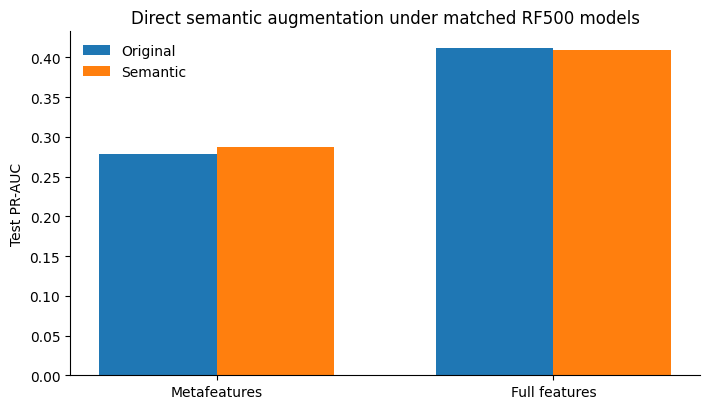

Paper tables saved to: /content/drive/MyDrive/csonet2026_conflict_prediction/results_gpt4omini/final_paper_tables

Direct RF semantic effects:


,pair_name,roc_auc_original,roc_auc_semantic,delta_roc_auc,pr_auc_original,pr_auc_semantic,delta_pr_auc
1,metafeatures,0.656255,0.665194,0.008939,0.278991,0.287430,0.008439
3,full_features,0.753104,0.751664,-0.001441,0.412168,0.409838,-0.002330



Repeated-seed SocialLSTM semantic deltas:


paired_label delta_roc_auc           delta_pr_auc  \
                                                 mean       std         mean   
0  social_lstm_plus_meta_h128_lr001_d02     -0.001278  0.003941    -0.003609   
1   social_lstm_plus_meta_h64_lr001_d02      0.000866  0.001593    -0.004020   

             delta_f1            
        std      mean       std  
0  0.016703  0.013185  0.135004  
1  0.004697 -0.043808  0.025927


System-level deltas (not semantic-only effects):


,comparison_type,baseline_model,semantic_system_model,baseline_roc_auc,system_roc_auc,delta_roc_auc,baseline_pr_auc,system_pr_auc,delta_pr_auc,baseline_f1,system_f1,delta_f1
0,system_level_not_semantic_only,original_rf500_metafeatures,redundancy_semantic_optuna_lightgbm_resid_inte...,0.656255,0.772282,0.116027,0.278991,0.442949,0.163958,0.043687,0.430782,0.387095
1,system_level_not_semantic_only,original_rf500_full_features,redundancy_semantic_optuna_lightgbm_resid_inte...,0.753104,0.772282,0.019178,0.412168,0.442949,0.030781,0.306413,0.430782,0.124368



Paired bootstrap results:


,comparison,n_test,delta_roc_auc,delta_pr_auc,delta_roc_auc_ci_low,delta_roc_auc_ci_high,delta_roc_auc_p_two_sided_approx,delta_pr_auc_ci_low,delta_pr_auc_ci_high,delta_pr_auc_p_two_sided_approx
0,rf500_metafeatures,11264,0.008939,0.008439,0.003081,0.014101,0.004,0.002306,0.014440,0.008
1,rf500_full_features,11264,-0.001441,-0.002330,-0.003452,0.000379,0.150,-0.004866,0.000305,0.080
2,social_lstm_plus_meta_h64_lr001_d02__seed42,11264,0.001790,-0.003973,-0.005387,0.008302,0.646,-0.015433,0.006467,0.462
3,social_lstm_plus_meta_h64_lr001_d02__seed43,11264,-0.000974,-0.008740,-0.008393,0.006877,0.770,-0.022212,0.003107,0.160
4,social_lstm_plus_meta_h64_lr001_d02__seed44,11264,0.001782,0.000653,-0.005473,0.008767,0.600,-0.010384,0.010996,0.944
5,social_lstm_plus_meta_h128_lr001_d02__seed42,11264,0.001435,0.007925,-0.004556,0.007591,0.602,-0.002577,0.018150,0.146
6,social_lstm_plus_meta_h128_lr001_d02__seed43,11264,0.000530,0.004010,-0.007376,0.007995,0.924,-0.008553,0.015889,0.578
7,social_lstm_plus_meta_h128_lr001_d02__seed44,11264,-0.005798,-0.022763,-0.012376,0.001186,0.098,-0.035630,-0.010040,0.000


In [ ]:
# Final paper-facing tables and paired uncertainty

PAPER_RESULTS_DIR = RESULTS_DIR / "final_paper_tables"
PAPER_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# 1. Direct RF semantic effects under matched RF500 models.
paper_rf_direct = fair_rf_delta_df[fair_rf_delta_df["split"] == "test"][
    [
        "pair_name",
        "roc_auc_original", "roc_auc_semantic", "delta_roc_auc",
        "pr_auc_original", "pr_auc_semantic", "delta_pr_auc",
    ]
].copy()
paper_rf_direct.to_csv(PAPER_RESULTS_DIR / "table_rf_direct_semantic_effect.csv", index=False)

# 2. Repeated-seed SocialLSTM summary and semantic deltas.
paper_lstm_delta_summary = (
    paper_lstm_seed_deltas
    .groupby("paired_label")[["delta_roc_auc", "delta_pr_auc", "delta_f1"]]
    .agg(["mean", "std"])
    .reset_index()
)
paper_lstm_delta_summary.to_csv(
    PAPER_RESULTS_DIR / "table_social_lstm_repeated_seed_deltas.csv",
    index=False,
)

# 3. Matched enhanced-architecture semantic effects.
paper_enhanced_direct = enhanced_delta_df[
    [
        "paired_model_key",
        "roc_auc_original", "roc_auc_semantic", "delta_roc_auc",
        "pr_auc_original", "pr_auc_semantic", "delta_pr_auc",
        "f1_original", "f1_semantic", "delta_f1",
    ]
].copy()
paper_enhanced_direct.to_csv(
    PAPER_RESULTS_DIR / "table_enhanced_direct_semantic_effect.csv",
    index=False,
)

# 4. Best semantic system and system-level deltas from original RF baselines.
best_semantic_system = best_semantic_any.copy()
baseline_specs = [
    ("original_rf500_metafeatures", "original_metafeatures_263_fair_split"),
    ("original_rf500_full_features", "original_full_meta_lstm_social_fair_split"),
]
system_delta_rows = []
for baseline_name, feature_set in baseline_specs:
    baseline = fair_rf_results[
        (fair_rf_results["split"] == "test")
        & (fair_rf_results["feature_set"] == feature_set)
    ].iloc[0]
    system_delta_rows.append({
        "comparison_type": "system_level_not_semantic_only",
        "baseline_model": baseline_name,
        "semantic_system_model": best_semantic_system["model_name"],
        "baseline_roc_auc": baseline["roc_auc"],
        "system_roc_auc": best_semantic_system["roc_auc"],
        "delta_roc_auc": best_semantic_system["roc_auc"] - baseline["roc_auc"],
        "baseline_pr_auc": baseline["pr_auc"],
        "system_pr_auc": best_semantic_system["pr_auc"],
        "delta_pr_auc": best_semantic_system["pr_auc"] - baseline["pr_auc"],
        "baseline_f1": baseline["f1"],
        "system_f1": best_semantic_system["f1"],
        "delta_f1": best_semantic_system["f1"] - baseline["f1"],
    })
paper_system_deltas = pd.DataFrame(system_delta_rows)
paper_system_deltas.to_csv(
    PAPER_RESULTS_DIR / "table_baseline_to_semantic_system_deltas.csv",
    index=False,
)

# 5. Paired bootstrap for direct RF comparisons.
rf_prediction_pairs = [
    (
        "rf500_metafeatures",
        RESULTS_DIR / "fair_rf500_original_metafeatures_predictions.parquet",
        RESULTS_DIR / "fair_rf500_semantic_metafeatures_predictions.parquet",
    ),
    (
        "rf500_full_features",
        RESULTS_DIR / "fair_rf500_original_full_features_predictions.parquet",
        RESULTS_DIR / "fair_rf500_semantic_full_features_predictions.parquet",
    ),
]
paper_bootstrap_rows = []
for comparison, original_path, semantic_path in rf_prediction_pairs:
    stats = paired_bootstrap_delta(
        original_path,
        semantic_path,
        n_boot=BOOTSTRAP_N_REDUNDANCY,
        seed=REDUNDANCY_RANDOM_STATE,
    )
    paper_bootstrap_rows.append({"comparison": comparison, **stats})

# Seed-specific SocialLSTM paired bootstraps.
for cfg in [c for c in FAIR_LSTM_CONFIGS if c["include_meta"]]:
    for seed in PAPER_LSTM_SEEDS:
        original_path = paper_lstm_seed_prediction_paths[(cfg["label"], seed, "original")]
        semantic_path = paper_lstm_seed_prediction_paths[(cfg["label"], seed, "semantic")]
        stats = paired_bootstrap_delta(
            original_path,
            semantic_path,
            n_boot=BOOTSTRAP_N_REDUNDANCY,
            seed=REDUNDANCY_RANDOM_STATE + seed,
        )
        paper_bootstrap_rows.append({
            "comparison": f"{cfg['label']}__seed{seed}",
            **stats,
        })

paper_direct_bootstrap = pd.DataFrame(paper_bootstrap_rows)
paper_direct_bootstrap.to_csv(
    PAPER_RESULTS_DIR / "table_direct_paired_bootstrap.csv",
    index=False,
)

# 6. Compact figure for direct PR-AUC effects.
plot_df = paper_rf_direct[
    ["pair_name", "pr_auc_original", "pr_auc_semantic"]
].melt(
    id_vars="pair_name",
    var_name="version",
    value_name="test_pr_auc",
)
plot_df["version"] = plot_df["version"].map({
    "pr_auc_original": "Original",
    "pr_auc_semantic": "Semantic",
})

fig, ax = plt.subplots(figsize=(7.2, 4.2))
x = np.arange(plot_df["pair_name"].nunique())
width = 0.35
for offset, version in [(-width / 2, "Original"), (width / 2, "Semantic")]:
    values = (
        plot_df[plot_df["version"] == version]
        .set_index("pair_name")
        .loc[paper_rf_direct["pair_name"], "test_pr_auc"]
        .values
    )
    ax.bar(x + offset, values, width, label=version)
ax.set_xticks(x, ["Metafeatures", "Full features"])
ax.set_ylabel("Test PR-AUC")
ax.set_title("Direct semantic augmentation under matched RF500 models")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(PAPER_RESULTS_DIR / "figure_direct_rf_pr_auc.pdf", bbox_inches="tight")
fig.savefig(PAPER_RESULTS_DIR / "figure_direct_rf_pr_auc.png", dpi=300, bbox_inches="tight")
plt.show()

print("Paper tables saved to:", PAPER_RESULTS_DIR)
print("\nDirect RF semantic effects:")
display(paper_rf_direct)
print("\nRepeated-seed SocialLSTM semantic deltas:")
display(paper_lstm_delta_summary)
print("\nSystem-level deltas (not semantic-only effects):")
display(paper_system_deltas)
print("\nPaired bootstrap results:")
display(paper_direct_bootstrap)


## 17. Publication tables, figures, and supplementary package

This self-contained section converts the saved experimental outputs into the main-paper and
supplementary materials. It may be executed independently after mounting Google Drive; no model
training is repeated. Model selection is reconstructed from saved validation metrics, while
uncertainty is recomputed from saved paired test predictions.

Tables are exported as CSV, GitHub Markdown, LaTeX, and Excel. Figures are exported as 300-dpi
PNG, vector PDF, and SVG. Statistical association tables use Fisher's exact test, Wilson intervals,
and Benjamini-Hochberg false-discovery-rate correction.

### Recommended main-paper set

| Item | Content | Suggested paper location |
|---|---|---|
| Figure 1 | End-to-end study design | Methods |
| Table 0 | Published WWW 2018 AUC versus reconstruction | Reproducibility |
| Table 1 | Coverage and split composition | Data |
| Table 2 | Semantic prevalence and outcome association | Semantic analysis |
| Table 3 | Compact baseline and proposed-system results | Main results |
| Table 4 | Paired uncertainty and seed stability | Main results |
| Figure 2 | Semantic prevalence and outcome odds ratios | Semantic analysis |
| Figure 3 | PR-AUC levels and deltas | Main results |
| Figure 4 | Semantic redundancy and grouped SHAP evidence | Discussion |


In [ ]:
# Cell 1: Publication artifact setup and imports

from pathlib import Path

try:
    from google.colab import drive
    if not Path("/content/drive/MyDrive").exists():
        drive.mount("/content/drive")
except ImportError:
    pass

import json
import os
import math
import re
import warnings
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.ticker import PercentFormatter
import seaborn as sns

from scipy import stats
from sklearn.metrics import (
    average_precision_score,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.proportion import proportion_confint

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 120)

RANDOM_STATE = 42
EXPECTED_ORIGINAL_ROWS = 116_224
ASSOCIATION_SPLIT = "test"
RUN_SUPPLEMENTARY = True

sns.set_theme(style="whitegrid", context="paper")
plt.rcParams.update({
    "figure.dpi": 130,
    "savefig.dpi": 300,
    "font.family": "DejaVu Sans",
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "legend.fontsize": 8,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

BLUE = "#2563EB"
ORANGE = "#EA580C"
GREEN = "#15803D"
RED = "#B91C1C"
GRAY = "#64748B"
LIGHT_BLUE = "#93C5FD"

print("Publication artifact environment ready.")


Publication artifact environment ready.


In [ ]:
# Cell 2: Paths and output folders

PROJECT_ROOT = Path(os.environ.get(
    "CSONET2026_PROJECT_ROOT",
    "/content/drive/MyDrive/csonet2026_conflict_prediction",
))
SOURCE_RESULTS_DIR = globals().get("SOURCE_RESULTS_DIR", PROJECT_ROOT / "results")
RESULTS_DIR = globals().get("RESULTS_DIR", PROJECT_ROOT / "results_gpt4omini")
PAPER_READY_DIR = RESULTS_DIR / "paper_ready_final"
PROVENANCE_DIR = PAPER_READY_DIR / "provenance"

SEMANTIC_PROVIDER_NAME = globals().get("SEMANTIC_PROVIDER_NAME", "GPT-4o mini")
SEMANTIC_PROVIDER_SLUG = globals().get("SEMANTIC_PROVIDER_SLUG", "openai_gpt4o_mini")

semantic_search_bases = []
for base in [SOURCE_RESULTS_DIR, RESULTS_DIR]:
    if base not in semantic_search_bases:
        semantic_search_bases.append(base)

GPT4OMINI_DIR_CANDIDATES = []
for base_results in semantic_search_bases:
    GPT4OMINI_DIR_CANDIDATES.extend([
        base_results / "llm_semantic_enrichment_full_dataset_gpt4omini_gemini25flashlite_boolean_v5" / "openai_gpt4o_mini",
        base_results / "llm_semantic_enrichment_full_dataset_gpt4omini_only_legacy_exact" / "openai_gpt4o_mini",
        base_results / "llm_semantic_enrichment_full_dataset_gpt4omini_only_LEGACY_EXACT" / "openai_gpt4o_mini",
        base_results / "llm_semantic_enrichment_full_dataset_gpt4omini_boolean_v5" / "openai_gpt4o_mini",
        base_results / "llm_semantic_enrichment_openai_gpt4o_mini_boolean_v5_10k",
    ])
GPT4OMINI_DIR_CANDIDATES = list(dict.fromkeys(GPT4OMINI_DIR_CANDIDATES))

FINAL_TABLES_DIR = RESULTS_DIR / "final_paper_tables"
ENHANCED_DIR = RESULTS_DIR / "official_enhanced_architecture_original_vs_semantic"
REDUNDANCY_DIR = RESULTS_DIR / "official_redundancy_aware_semantic_accuracy"

OUTPUT_ROOT = PAPER_READY_DIR / "artifacts"
MAIN_TABLE_DIR = OUTPUT_ROOT / "main_paper" / "tables"
MAIN_FIGURE_DIR = OUTPUT_ROOT / "main_paper" / "figures"
SUPP_TABLE_DIR = OUTPUT_ROOT / "supplementary" / "tables"
SUPP_FIGURE_DIR = OUTPUT_ROOT / "supplementary" / "figures"
REPORT_DIR = OUTPUT_ROOT / "reports"
for folder in [
    MAIN_TABLE_DIR,
    MAIN_FIGURE_DIR,
    SUPP_TABLE_DIR,
    SUPP_FIGURE_DIR,
    REPORT_DIR,
]:
    folder.mkdir(parents=True, exist_ok=True)

RUN_TIMESTAMP_UTC = datetime.now(timezone.utc).strftime("%Y-%m-%dT%H:%M:%SZ")

print("Project root:", PROJECT_ROOT)
print("Source results:", SOURCE_RESULTS_DIR)
print("Run results:", RESULTS_DIR)
print("Semantic provider:", SEMANTIC_PROVIDER_NAME)
print("Main-paper output:", OUTPUT_ROOT / "main_paper")
print("Supplementary output:", OUTPUT_ROOT / "supplementary")


Project root: /content/drive/MyDrive/csonet2026_conflict_prediction
Source results: /content/drive/MyDrive/csonet2026_conflict_prediction/results
Run results: /content/drive/MyDrive/csonet2026_conflict_prediction/results_gpt4omini
Semantic provider: GPT-4o mini
Main-paper output: /content/drive/MyDrive/csonet2026_conflict_prediction/results_gpt4omini/paper_ready_final/artifacts/main_paper
Supplementary output: /content/drive/MyDrive/csonet2026_conflict_prediction/results_gpt4omini/paper_ready_final/artifacts/supplementary


In [ ]:
# Cell 3: Robust loading and export helpers

def first_existing(paths, required=True, label="file"):
    checked = []
    for candidate in paths:
        path = Path(candidate)
        checked.append(str(path))
        if path.exists():
            return path
    if required:
        raise FileNotFoundError(f"Could not find {label}. Checked:\n" + "\n".join(checked))
    return None


def read_table(path):
    path = Path(path)
    if path.suffix.lower() == ".parquet":
        return pd.read_parquet(path)
    if path.suffix.lower() == ".csv":
        return pd.read_csv(path, low_memory=False)
    if path.suffix.lower() in {".pkl", ".pickle"}:
        return pd.read_pickle(path)
    raise ValueError(f"Unsupported table format: {path}")


def read_optional_csv(path):
    path = Path(path)
    return pd.read_csv(path, low_memory=False) if path.exists() else pd.DataFrame()


def read_optional_json(path):
    path = Path(path)
    if not path.exists():
        return {}
    with open(path, "r", encoding="utf-8") as handle:
        return json.load(handle)


def clean_label(value):
    text = str(value)
    text = re.sub(r"^sem_primary_", "", text)
    text = re.sub(r"^sem_", "", text)
    text = text.replace("_reference", "")
    return text.replace("_", " ").strip().title()


def save_table(df, filename, supplementary=False, index=False):
    folder = SUPP_TABLE_DIR if supplementary else MAIN_TABLE_DIR
    csv_path = folder / filename
    df.to_csv(csv_path, index=index)
    md_path = csv_path.with_suffix(".md")
    with open(md_path, "w", encoding="utf-8") as handle:
        handle.write(df.to_markdown(index=index, floatfmt=".6f"))
        handle.write("\n")
    tex_path = csv_path.with_suffix(".tex")
    with open(tex_path, "w", encoding="utf-8") as handle:
        handle.write(df.to_latex(index=index, float_format=lambda value: f"{value:.6f}"))
    print("Saved:", csv_path)
    return csv_path


def save_figure(fig, stem, supplementary=False):
    folder = SUPP_FIGURE_DIR if supplementary else MAIN_FIGURE_DIR
    paths = []
    for suffix in [".png", ".pdf", ".svg"]:
        path = folder / f"{stem}{suffix}"
        kwargs = {"dpi": 300} if suffix == ".png" else {}
        fig.savefig(path, bbox_inches="tight", **kwargs)
        paths.append(path)
    print("Saved:", paths[0])
    return paths


def odds_ratio_ci(pos_true, neg_true, pos_false, neg_false, correction=0.5):
    a, b, c, d = [float(v) + correction for v in [pos_true, neg_true, pos_false, neg_false]]
    odds_ratio = (a * d) / (b * c)
    se = math.sqrt(1 / a + 1 / b + 1 / c + 1 / d)
    lo = math.exp(math.log(odds_ratio) - 1.96 * se)
    hi = math.exp(math.log(odds_ratio) + 1.96 * se)
    return odds_ratio, lo, hi


def t_interval(values, confidence=0.95):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if len(values) < 2:
        return (np.nan, np.nan)
    mean = values.mean()
    half = stats.t.ppf((1 + confidence) / 2, len(values) - 1) * values.std(ddof=1) / np.sqrt(len(values))
    return float(mean - half), float(mean + half)


def require_columns(df, columns, label):
    missing = [column for column in columns if column not in df.columns]
    if missing:
        raise ValueError(f"{label} is missing columns: {missing}")



def sha256_file(path):
    """Return the SHA-256 digest of a local artifact."""
    import hashlib

    digest = hashlib.sha256()
    with open(path, "rb") as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()


In [ ]:
# Cell 4: Load saved outputs and reconstruct the eligible final selection

GPT4OMINI_DIR = first_existing(GPT4OMINI_DIR_CANDIDATES, label="GPT-4o mini result directory")
SEMANTIC_PATH = first_existing([
    GPT4OMINI_DIR / "semantic_features.parquet",
    GPT4OMINI_DIR / "semantic_features.csv",
    GPT4OMINI_DIR / "semantic_features.pkl",
], label="GPT-4o mini semantic features")

semantic_df = read_table(SEMANTIC_PATH).drop_duplicates("post_id", keep="last")
semantic_df["post_id"] = semantic_df["post_id"].astype(str)
require_columns(semantic_df, ["post_id", "split", "y"], "semantic feature table")

BOOLEAN_LABELS = [
    "sem_negative_grievance",
    "sem_audience_directed_engagement",
    "sem_norm_violation_framing",
    "sem_cross_community_comparison",
    "sem_intergroup_boundary_framing",
    "sem_supportive_or_defensive_framing",
    "sem_neutral_information_reference",
]
PRIMARY_LABELS = [
    "sem_primary_neutral_information_reference",
    "sem_primary_negative_grievance_reference",
    "sem_primary_audience_directed_engagement_reference",
    "sem_primary_norm_violation_reference",
    "sem_primary_cross_community_comparison_reference",
    "sem_primary_supportive_or_defensive_reference",
    "sem_primary_unclear_or_other",
]
BOOLEAN_LABELS = [column for column in BOOLEAN_LABELS if column in semantic_df.columns]
PRIMARY_LABELS = [column for column in PRIMARY_LABELS if column in semantic_df.columns]
SEMANTIC_COLUMNS = BOOLEAN_LABELS + PRIMARY_LABELS
for column in SEMANTIC_COLUMNS:
    semantic_df[column] = (
        pd.to_numeric(semantic_df[column], errors="coerce")
        .fillna(0)
        .astype(int)
    )
semantic_df["y"] = pd.to_numeric(semantic_df["y"], errors="raise").astype(int)

rf_direct = read_table(first_existing([
    FINAL_TABLES_DIR / "table_rf_direct_semantic_effect.csv",
], label="direct RF table"))
lstm_seed_metrics = read_table(first_existing([
    RESULTS_DIR / "paper_social_lstm_repeated_seed_test_metrics.csv",
], label="three-seed SocialLSTM metrics"))
direct_bootstrap = read_table(first_existing([
    FINAL_TABLES_DIR / "table_direct_paired_bootstrap.csv",
], label="direct paired bootstrap table"))
enhanced_deltas = read_table(first_existing([
    ENHANCED_DIR / "enhanced_original_vs_semantic_deltas.csv",
], label="matched enhanced-architecture deltas"))
enhanced_bootstrap = read_optional_csv(
    ENHANCED_DIR / "enhanced_paired_bootstrap_deltas.csv"
)
predictability_df = read_table(first_existing([
    REDUNDANCY_DIR / "semantic_predictability_from_original_features.csv",
], label="semantic predictability diagnostics"))
shap_group_df = read_optional_csv(
    REDUNDANCY_DIR / "augmented_lightgbm_shap_group_summary.csv"
)

# Reconstruct final selection from saved validation metrics. No model is fitted.
all_saved_metrics = read_table(first_existing([
    REDUNDANCY_DIR / "all_redundancy_aware_metrics.csv",
], label="combined saved model metrics"))
require_columns(
    all_saved_metrics,
    [
        "model_name",
        "model_family",
        "source_data",
        "split",
        "roc_auc",
        "pr_auc",
        "f1",
        "prediction_path",
    ],
    "combined saved model metrics",
)

invalid_stacker_mask = (
    all_saved_metrics["model_family"]
    .fillna("")
    .astype(str)
    .eq("validation_stacker")
)
excluded_stacker_metrics = all_saved_metrics[invalid_stacker_mask].copy()
eligible_saved_metrics = all_saved_metrics[~invalid_stacker_mask].copy()
excluded_stacker_metrics.to_csv(
    REDUNDANCY_DIR / "excluded_validation_stacker_metrics.csv",
    index=False,
)

validation_leaderboard = (
    eligible_saved_metrics[eligible_saved_metrics["split"] == "val"]
    .sort_values(["pr_auc", "roc_auc"], ascending=False)
    .reset_index(drop=True)
)
redundancy_leaderboard = (
    eligible_saved_metrics[eligible_saved_metrics["split"] == "test"]
    .sort_values(["pr_auc", "roc_auc"], ascending=False)
    .reset_index(drop=True)
)
validation_leaderboard.to_csv(
    REDUNDANCY_DIR / "redundancy_aware_validation_leaderboard.csv",
    index=False,
)
redundancy_leaderboard.to_csv(
    REDUNDANCY_DIR / "redundancy_aware_test_leaderboard.csv",
    index=False,
)

original_candidates = validation_leaderboard[
    validation_leaderboard["source_data"] == "original_enhanced_architecture"
]
semantic_candidates = validation_leaderboard[
    validation_leaderboard["source_data"] != "original_enhanced_architecture"
]
if original_candidates.empty or semantic_candidates.empty:
    raise RuntimeError("Saved original or semantic validation candidates are missing.")

selected_original_name = str(original_candidates.iloc[0]["model_name"])
selected_semantic_name = str(semantic_candidates.iloc[0]["model_name"])
best_original = redundancy_leaderboard[
    redundancy_leaderboard["model_name"] == selected_original_name
].iloc[0]
best_semantic = redundancy_leaderboard[
    redundancy_leaderboard["model_name"] == selected_semantic_name
].iloc[0]

best_system_summary = {
    "selection_metric": "validation_pr_auc",
    "selection_uses_test_metrics": False,
    "invalid_validation_stackers_excluded": True,
    "best_original_model": selected_original_name,
    "best_original_source_data": best_original["source_data"],
    "best_original_roc_auc": float(best_original["roc_auc"]),
    "best_original_pr_auc": float(best_original["pr_auc"]),
    "best_original_f1": float(best_original["f1"]),
    "best_semantic_or_redundancy_model": selected_semantic_name,
    "best_semantic_or_redundancy_source_data": best_semantic["source_data"],
    "best_semantic_or_redundancy_roc_auc": float(best_semantic["roc_auc"]),
    "best_semantic_or_redundancy_pr_auc": float(best_semantic["pr_auc"]),
    "best_semantic_or_redundancy_f1": float(best_semantic["f1"]),
    "delta_best_roc_auc": float(best_semantic["roc_auc"] - best_original["roc_auc"]),
    "delta_best_pr_auc": float(best_semantic["pr_auc"] - best_original["pr_auc"]),
    "delta_best_f1": float(best_semantic["f1"] - best_original["f1"]),
}
with open(
    REDUNDANCY_DIR
    / "best_original_vs_redundancy_aware_semantic_summary.json",
    "w",
    encoding="utf-8",
) as handle:
    json.dump(best_system_summary, handle, indent=2)

# Recompute paired uncertainty from the saved held-out predictions.
def paired_bootstrap_saved_predictions(original_path, semantic_path, n_boot=2000, seed=42):
    original = pd.read_parquet(original_path)
    semantic = pd.read_parquet(semantic_path)
    original = original[original["split"] == "test"][
        ["post_id", "y", "score"]
    ].rename(columns={"y": "y_original", "score": "score_original"})
    semantic = semantic[semantic["split"] == "test"][
        ["post_id", "y", "score"]
    ].rename(columns={"y": "y_semantic", "score": "score_semantic"})
    paired = original.merge(semantic, on="post_id", validate="one_to_one")
    if not np.array_equal(paired["y_original"], paired["y_semantic"]):
        raise AssertionError("Selected prediction files contain different outcomes.")
    y = paired["y_original"].to_numpy(dtype=int)
    score_original = paired["score_original"].to_numpy(dtype=float)
    score_semantic = paired["score_semantic"].to_numpy(dtype=float)
    observed_roc = roc_auc_score(y, score_semantic) - roc_auc_score(y, score_original)
    observed_pr = (
        average_precision_score(y, score_semantic)
        - average_precision_score(y, score_original)
    )
    rng = np.random.default_rng(seed)
    roc_deltas, pr_deltas = [], []
    for _ in range(n_boot):
        indices = rng.integers(0, len(y), size=len(y))
        sampled_y = y[indices]
        if np.unique(sampled_y).size < 2:
            continue
        roc_deltas.append(
            roc_auc_score(sampled_y, score_semantic[indices])
            - roc_auc_score(sampled_y, score_original[indices])
        )
        pr_deltas.append(
            average_precision_score(sampled_y, score_semantic[indices])
            - average_precision_score(sampled_y, score_original[indices])
        )
    roc_deltas = np.asarray(roc_deltas)
    pr_deltas = np.asarray(pr_deltas)
    return {
        "n_test": int(len(y)),
        "n_bootstrap": int(len(pr_deltas)),
        "delta_roc_auc": float(observed_roc),
        "delta_pr_auc": float(observed_pr),
        "delta_roc_auc_ci_low": float(np.percentile(roc_deltas, 2.5)),
        "delta_roc_auc_ci_high": float(np.percentile(roc_deltas, 97.5)),
        "delta_roc_auc_p_two_sided_approx": float(
            min(1.0, 2 * min(np.mean(roc_deltas <= 0), np.mean(roc_deltas >= 0)))
        ),
        "delta_pr_auc_ci_low": float(np.percentile(pr_deltas, 2.5)),
        "delta_pr_auc_ci_high": float(np.percentile(pr_deltas, 97.5)),
        "delta_pr_auc_p_two_sided_approx": float(
            min(1.0, 2 * min(np.mean(pr_deltas <= 0), np.mean(pr_deltas >= 0)))
        ),
    }

bootstrap_statistics = paired_bootstrap_saved_predictions(
    Path(best_original["prediction_path"]),
    Path(best_semantic["prediction_path"]),
)
best_system_bootstrap = pd.DataFrame([{
    "comparison": (
        "validation_selected_semantic_minus_validation_selected_original"
    ),
    "selection_metric": "validation_pr_auc",
    "model_name_original": selected_original_name,
    "model_name_semantic_or_redundancy": selected_semantic_name,
    **bootstrap_statistics,
}])
best_system_bootstrap.to_csv(
    REDUNDANCY_DIR
    / "bootstrap_best_original_vs_redundancy_aware_semantic.csv",
    index=False,
)

print(f"GPT-4o mini semantic coverage: {len(semantic_df):,}/{EXPECTED_ORIGINAL_ROWS:,}")
print("Excluded validation-trained stacker rows:", len(excluded_stacker_metrics))
print("Selected original system:", selected_original_name)
print("Selected semantic system:", selected_semantic_name)
display(pd.DataFrame([best_system_summary]))
display(best_system_bootstrap)


GPT-4o mini semantic coverage: 116,224/116,224
Excluded validation-trained stacker rows: 0
Selected original system: enhanced_original_xgboost
Selected semantic system: redundancy_semantic_optuna_lightgbm_resid_interactions


,selection_metric,selection_uses_test_metrics,invalid_validation_stackers_excluded,best_original_model,best_original_source_data,best_original_roc_auc,best_original_pr_auc,best_original_f1,best_semantic_or_redundancy_model,best_semantic_or_redundancy_source_data,best_semantic_or_redundancy_roc_auc,best_semantic_or_redundancy_pr_auc,best_semantic_or_redundancy_f1,delta_best_roc_auc,delta_best_pr_auc,delta_best_f1
0,validation_pr_auc,False,True,enhanced_original_xgboost,original_enhanced_architecture,0.77084,0.445023,0.427803,redundancy_semantic_optuna_lightgbm_resid_interactions,semantic_residual_interaction_augmented,0.772282,0.442949,0.430782,0.001442,-0.002074,0.002978


,comparison,selection_metric,model_name_original,model_name_semantic_or_redundancy,n_test,n_bootstrap,delta_roc_auc,delta_pr_auc,delta_roc_auc_ci_low,delta_roc_auc_ci_high,delta_roc_auc_p_two_sided_approx,delta_pr_auc_ci_low,delta_pr_auc_ci_high,delta_pr_auc_p_two_sided_approx
0,validation_selected_semantic_minus_validation_selected_original,validation_pr_auc,enhanced_original_xgboost,redundancy_semantic_optuna_lightgbm_resid_interactions,11264,2000,0.001442,-0.002074,-0.001176,0.004151,0.275,-0.006881,0.002563,0.398


In [ ]:
# Table 0: Published WWW 2018 AUC values versus this reconstruction

# Kumar et al. report AUC to two decimal places: RF500=0.67,
# socially primed LSTM=0.72, and the full RF ensemble=0.76.
reconstructed_lstm_metrics = read_table(first_existing([
    RESULTS_DIR / "official_lstm_original_vs_semantic_full_metrics.csv",
], label="reconstructed SocialLSTM metrics"))

rf_meta_row = rf_direct[rf_direct["pair_name"].astype(str) == "metafeatures"].iloc[0]
rf_full_row = rf_direct[rf_direct["pair_name"].astype(str) == "full_features"].iloc[0]
social_row = reconstructed_lstm_metrics[
    (reconstructed_lstm_metrics["split"].astype(str) == "test")
    & reconstructed_lstm_metrics["run_name"].astype(str).str.contains(
        "official_original__social_lstm_h64_lr001_d02", regex=False
    )
].iloc[0]

table_00 = pd.DataFrame([
    {
        "model": "RF500 handcrafted baseline",
        "published_auc": 0.67,
        "reconstructed_test_auc": float(rf_meta_row["roc_auc_original"]),
        "difference_reconstructed_minus_published": float(rf_meta_row["roc_auc_original"] - 0.67),
        "mapping": "263 released metafeatures; 500-tree random forest",
    },
    {
        "model": "Socially primed LSTM",
        "published_auc": 0.72,
        "reconstructed_test_auc": float(social_row["roc_auc"]),
        "difference_reconstructed_minus_published": float(social_row["roc_auc"] - 0.72),
        "mapping": "text with released user and source/target community embeddings",
    },
    {
        "model": "Full RF ensemble",
        "published_auc": 0.76,
        "reconstructed_test_auc": float(rf_full_row["roc_auc_original"]),
        "difference_reconstructed_minus_published": float(rf_full_row["roc_auc_original"] - 0.76),
        "mapping": "metafeatures, released LSTM hidden state, and social embeddings",
    },
])
table_00["source_reporting_precision"] = "published AUC rounded to two decimals"
save_table(table_00, "table_00_published_vs_reconstructed_auc.csv")
display(table_00)

Saved: /content/drive/MyDrive/csonet2026_conflict_prediction/results_gpt4omini/paper_ready_final/artifacts/main_paper/tables/table_00_published_vs_reconstructed_auc.csv


,model,published_auc,reconstructed_test_auc,difference_reconstructed_minus_published,mapping,source_reporting_precision
0,RF500 handcrafted baseline,0.67,0.656255,-0.013745,263 released metafeatures; 500-tree random forest,published AUC rounded to two decimals
1,Socially primed LSTM,0.72,0.737545,0.017545,text with released user and source/target community embeddings,published AUC rounded to two decimals
2,Full RF ensemble,0.76,0.753104,-0.006896,"metafeatures, released LSTM hidden state, and social embeddings",published AUC rounded to two decimals


## Main-paper materials

The following cells create only the recommended main-paper set. Their filenames
start with `table_01` through `table_04` and `figure_01` through `figure_04`.


In [ ]:
# Cell 5: Table 1 - dataset coverage and split composition

split_order = ["train", "val", "test"]
split_rows = []
for split_name in split_order:
    subset = semantic_df[semantic_df["split"].astype(str) == split_name]
    if subset.empty:
        continue
    split_rows.append({
        "partition": split_name.title(),
        "rows": int(len(subset)),
        "positive_outcomes": int(subset["y"].sum()),
        "positive_rate": float(subset["y"].mean()),
        "semantic_coverage_rate": 1.0,
    })

coverage_n = int(semantic_df["post_id"].nunique())
split_rows.append({
    "partition": "Total semantic-covered",
    "rows": coverage_n,
    "positive_outcomes": int(semantic_df["y"].sum()),
    "positive_rate": float(semantic_df["y"].mean()),
    "semantic_coverage_rate": coverage_n / EXPECTED_ORIGINAL_ROWS,
})
split_rows.append({
    "partition": "Missing semantic labels",
    "rows": int(EXPECTED_ORIGINAL_ROWS - coverage_n),
    "positive_outcomes": np.nan,
    "positive_rate": np.nan,
    "semantic_coverage_rate": (EXPECTED_ORIGINAL_ROWS - coverage_n) / EXPECTED_ORIGINAL_ROWS,
})

table_01 = pd.DataFrame(split_rows)
save_table(table_01, "table_01_dataset_coverage_and_splits.csv")
display(table_01)


Saved: /content/drive/MyDrive/csonet2026_conflict_prediction/results_gpt4omini/paper_ready_final/artifacts/main_paper/tables/table_01_dataset_coverage_and_splits.csv


,partition,rows,positive_outcomes,positive_rate,semantic_coverage_rate
0,Train,93696,15381.0,0.164159,1.0
1,Val,11264,1803.0,0.160067,1.0
2,Test,11264,1812.0,0.160866,1.0
3,Total semantic-covered,116224,18996.0,0.163443,1.0
4,Missing semantic labels,0,NaN,NaN,0.0


In [ ]:
# Cell 6: Table 2 - GPT-4o mini label prevalence and test-outcome association

association_df = semantic_df[semantic_df["split"].astype(str) == ASSOCIATION_SPLIT].copy()
if association_df.empty:
    raise ValueError(f"No rows found for ASSOCIATION_SPLIT={ASSOCIATION_SPLIT!r}")

label_rows = []
for column in BOOLEAN_LABELS:
    full_x = semantic_df[column].astype(int)
    x = association_df[column].astype(int)
    y = association_df["y"].astype(int)

    n_true = int(x.sum())
    n_false = int((1 - x).sum())
    pos_true = int(((x == 1) & (y == 1)).sum())
    pos_false = int(((x == 0) & (y == 1)).sum())
    rate_true = pos_true / n_true if n_true else np.nan
    rate_false = pos_false / n_false if n_false else np.nan
    or_value, or_low, or_high = odds_ratio_ci(
        pos_true, n_true - pos_true, pos_false, n_false - pos_false
    )
    _, p_value = stats.fisher_exact(
        [[pos_true, n_true - pos_true], [pos_false, n_false - pos_false]]
    )
    rate_low, rate_high = proportion_confint(
        pos_true, n_true, alpha=0.05, method="wilson"
    ) if n_true else (np.nan, np.nan)
    label_rows.append({
        "semantic_label": clean_label(column),
        "feature_column": column,
        "full_corpus_count": int(full_x.sum()),
        "full_corpus_prevalence": float(full_x.mean()),
        "association_split": ASSOCIATION_SPLIT,
        "association_n_true": n_true,
        "outcome_rate_when_true": rate_true,
        "outcome_rate_true_ci_low": rate_low,
        "outcome_rate_true_ci_high": rate_high,
        "outcome_rate_when_false": rate_false,
        "rate_difference_true_minus_false": rate_true - rate_false,
        "odds_ratio": or_value,
        "odds_ratio_ci_low": or_low,
        "odds_ratio_ci_high": or_high,
        "fisher_p_value": p_value,
    })

table_02 = pd.DataFrame(label_rows)
table_02["fdr_bh_q_value"] = multipletests(
    table_02["fisher_p_value"].values, method="fdr_bh"
)[1]
table_02 = table_02.sort_values("odds_ratio", ascending=False).reset_index(drop=True)
save_table(table_02, "table_02_gpt4omini_labels_and_test_outcome_association.csv")
display(table_02)


Saved: /content/drive/MyDrive/csonet2026_conflict_prediction/results_gpt4omini/paper_ready_final/artifacts/main_paper/tables/table_02_gpt4omini_labels_and_test_outcome_association.csv


,semantic_label,feature_column,full_corpus_count,full_corpus_prevalence,association_split,association_n_true,outcome_rate_when_true,outcome_rate_true_ci_low,outcome_rate_true_ci_high,outcome_rate_when_false,rate_difference_true_minus_false,odds_ratio,odds_ratio_ci_low,odds_ratio_ci_high,fisher_p_value,fdr_bh_q_value
0,Cross Community Comparison,sem_cross_community_comparison,12848,0.110545,test,1297,0.197379,0.176625,0.219920,0.156115,0.041263,1.330921,1.149049,1.541580,0.000215,0.000501
1,Audience Directed Engagement,sem_audience_directed_engagement,47125,0.405467,test,4800,0.178750,0.168169,0.189845,0.147587,0.031163,1.257140,1.136539,1.390538,0.000009,0.000032
2,Supportive Or Defensive Framing,sem_supportive_or_defensive_framing,5013,0.043132,test,495,0.185859,0.154056,0.222499,0.159718,0.026141,1.205780,0.956356,1.520256,0.132912,0.155064
3,Negative Grievance,sem_negative_grievance,28834,0.248090,test,2880,0.150694,0.138094,0.164225,0.164361,-0.013666,0.902691,0.802822,1.014982,0.088215,0.123501
4,Intergroup Boundary Framing,sem_intergroup_boundary_framing,7139,0.061424,test,710,0.143662,0.119778,0.171381,0.162024,-0.018362,0.870991,0.702086,1.080529,0.205630,0.205630
5,Neutral Information,sem_neutral_information_reference,53119,0.457040,test,5087,0.143896,0.134520,0.153810,0.174842,-0.030946,0.793418,0.716369,0.878754,0.000008,0.000032
6,Norm Violation Framing,sem_norm_violation_framing,7608,0.065460,test,824,0.129854,0.108610,0.154534,0.163314,-0.033460,0.767401,0.622515,0.946009,0.011931,0.020880


Saved: /content/drive/MyDrive/csonet2026_conflict_prediction/results_gpt4omini/paper_ready_final/artifacts/main_paper/figures/figure_01_study_design.png


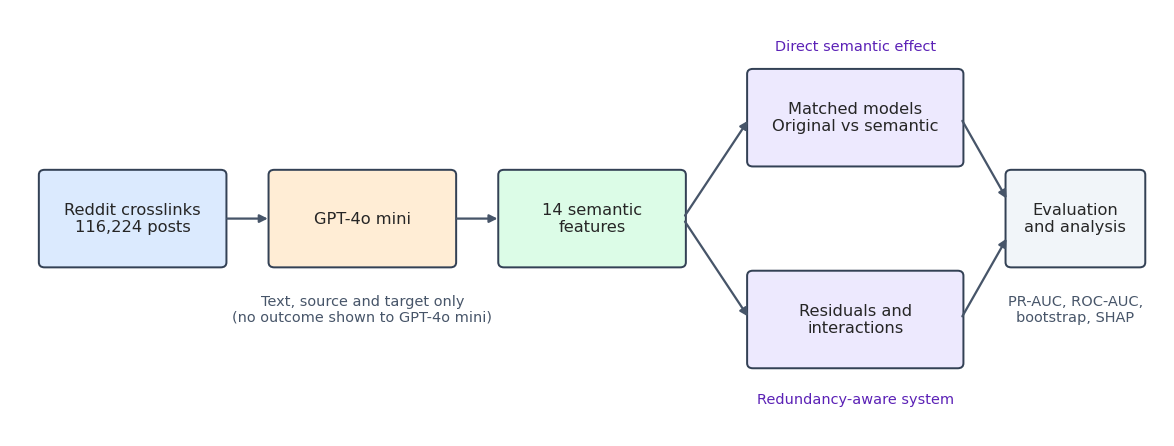

In [ ]:
# Cell 7: Figure 1 - end-to-end study design

fig, ax = plt.subplots(figsize=(11.4, 4.2))
ax.set_xlim(0, 12)
ax.set_ylim(0, 5)
ax.axis("off")

nodes = [
    (0.3, 2.0, 1.9, 1.1, "Reddit crosslinks\n116,224 posts", "#DBEAFE"),
    (2.7, 2.0, 1.9, 1.1, "GPT-4o mini", "#FFEDD5"),
    (5.1, 2.0, 1.9, 1.1, "14 semantic\nfeatures", "#DCFCE7"),
    (7.7, 3.2, 2.2, 1.1, "Matched models\nOriginal vs semantic", "#EDE9FE"),
    (7.7, 0.8, 2.2, 1.1, "Residuals and\ninteractions", "#EDE9FE"),
    (10.4, 2.0, 1.4, 1.1, "Evaluation\nand analysis", "#F1F5F9"),
]
for x, y, w, h, label, color in nodes:
    rect = patches.FancyBboxPatch(
        (x, y), w, h, boxstyle="round,pad=0.03,rounding_size=0.06",
        facecolor=color, edgecolor="#334155", linewidth=1.1
    )
    ax.add_patch(rect)
    ax.text(x + w / 2, y + h / 2, label, ha="center", va="center", fontsize=9)

def arrow(x1, y1, x2, y2):
    ax.annotate(
        "", xy=(x2, y2), xytext=(x1, y1),
        arrowprops=dict(arrowstyle="-|>", color="#475569", linewidth=1.25)
    )

arrow(2.2, 2.55, 2.7, 2.55)
arrow(4.6, 2.55, 5.1, 2.55)
arrow(7.0, 2.55, 7.7, 3.75)
arrow(7.0, 2.55, 7.7, 1.35)
arrow(9.9, 3.75, 10.4, 2.75)
arrow(9.9, 1.35, 10.4, 2.35)

ax.text(3.65, 1.65, "Text, source and target only\n(no outcome shown to GPT-4o mini)",
        ha="center", va="top", fontsize=8, color="#475569")
ax.text(8.8, 4.55, "Direct semantic effect", ha="center", fontsize=8, color="#5B21B6")
ax.text(8.8, 0.35, "Redundancy-aware system", ha="center", fontsize=8, color="#5B21B6")
ax.text(11.1, 1.65, "PR-AUC, ROC-AUC,\nbootstrap, SHAP",
        ha="center", va="top", fontsize=8, color="#475569")

save_figure(fig, "figure_01_study_design")
plt.show()


Saved: /content/drive/MyDrive/csonet2026_conflict_prediction/results_gpt4omini/paper_ready_final/artifacts/main_paper/figures/figure_02_gpt4omini_prevalence_and_outcome_association.png


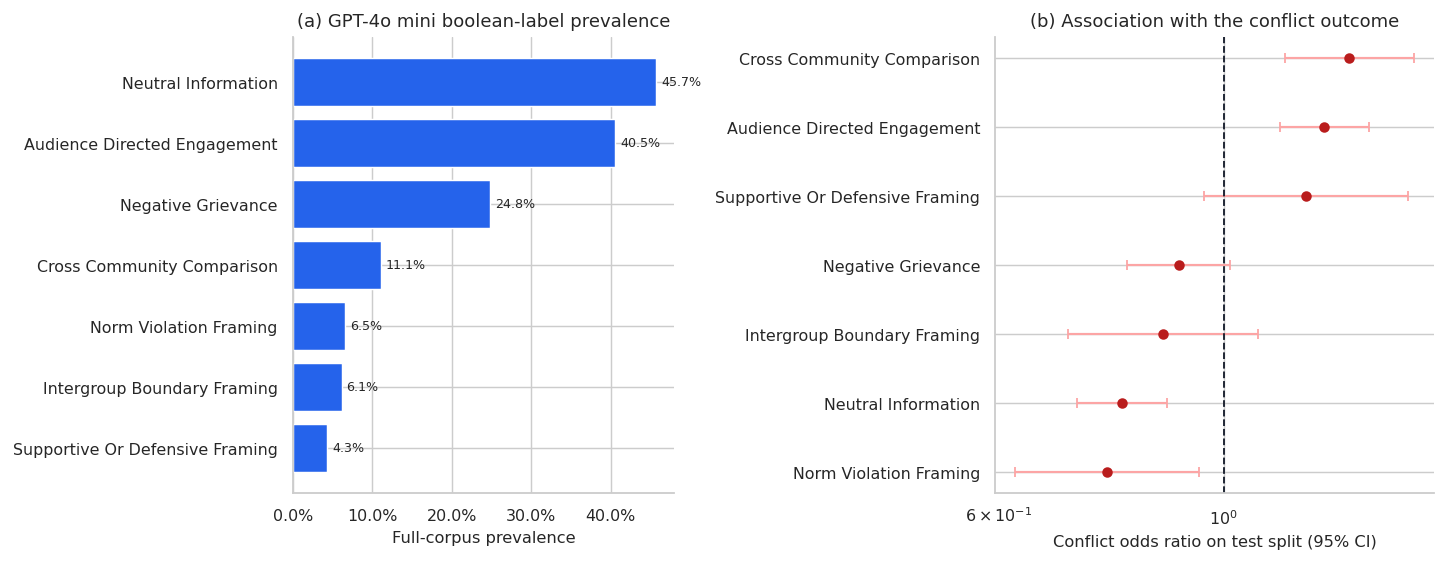

In [ ]:
# Cell 8: Figure 2 - GPT-4o mini prevalence and test-outcome odds ratios

plot_df = table_02.sort_values("full_corpus_prevalence", ascending=True).copy()
fig, axes = plt.subplots(1, 2, figsize=(11.2, 4.4), gridspec_kw={"width_ratios": [1.0, 1.15]})

axes[0].barh(plot_df["semantic_label"], plot_df["full_corpus_prevalence"], color=BLUE)
axes[0].set_xlabel("Full-corpus prevalence")
axes[0].set_ylabel("")
axes[0].set_title("(a) GPT-4o mini boolean-label prevalence")
axes[0].xaxis.set_major_formatter(PercentFormatter(1.0))
for idx, value in enumerate(plot_df["full_corpus_prevalence"]):
    axes[0].text(value + 0.006, idx, f"{value:.1%}", va="center", fontsize=7)

or_df = table_02.sort_values("odds_ratio", ascending=True).copy()
y_pos = np.arange(len(or_df))
axes[1].errorbar(
    or_df["odds_ratio"], y_pos,
    xerr=[
        or_df["odds_ratio"] - or_df["odds_ratio_ci_low"],
        or_df["odds_ratio_ci_high"] - or_df["odds_ratio"],
    ],
    fmt="o", color=RED, ecolor="#FCA5A5", capsize=3
)
axes[1].axvline(1.0, color="#111827", linestyle="--", linewidth=1)
axes[1].set_yticks(y_pos, or_df["semantic_label"])
axes[1].set_xscale("log")
axes[1].set_xlabel(f"Conflict odds ratio on {ASSOCIATION_SPLIT} split (95% CI)")
axes[1].set_ylabel("")
axes[1].set_title("(b) Association with the conflict outcome")

fig.tight_layout()
save_figure(fig, "figure_02_gpt4omini_prevalence_and_outcome_association")
plt.show()


In [ ]:
# Cell 9: Tables 3 and 4 - compact model results and uncertainty

# Three-seed SocialLSTM means.
lstm_summary = (
    lstm_seed_metrics
    .groupby(["paired_label", "variant"])[["roc_auc", "pr_auc"]]
    .agg(["mean", "std"])
    .reset_index()
)
lstm_flat = lstm_summary.copy()
lstm_flat.columns = [
    "_".join([str(part) for part in column if str(part)])
    if isinstance(column, tuple) else column
    for column in lstm_flat.columns
]

main_rows = []
for _, row in rf_direct.iterrows():
    main_rows.append({
        "comparison": f"RF500 {str(row['pair_name']).replace('_', ' ')}",
        "comparison_type": "matched direct semantic effect",
        "original_roc_auc": row["roc_auc_original"],
        "semantic_roc_auc": row["roc_auc_semantic"],
        "delta_roc_auc": row["delta_roc_auc"],
        "original_pr_auc": row["pr_auc_original"],
        "semantic_pr_auc": row["pr_auc_semantic"],
        "delta_pr_auc": row["delta_pr_auc"],
        "replication_note": "single deterministic RF run",
    })

for paired_label in sorted(lstm_seed_metrics["paired_label"].unique()):
    subset = lstm_seed_metrics[lstm_seed_metrics["paired_label"] == paired_label]
    original = subset[subset["variant"] == "original"]
    semantic = subset[subset["variant"] == "semantic"]
    if original.empty or semantic.empty:
        continue
    short = "SocialLSTM h128 + meta" if "h128" in paired_label else "SocialLSTM h64 + meta"
    main_rows.append({
        "comparison": short,
        "comparison_type": "matched direct semantic effect",
        "original_roc_auc": original["roc_auc"].mean(),
        "semantic_roc_auc": semantic["roc_auc"].mean(),
        "delta_roc_auc": semantic["roc_auc"].mean() - original["roc_auc"].mean(),
        "original_pr_auc": original["pr_auc"].mean(),
        "semantic_pr_auc": semantic["pr_auc"].mean(),
        "delta_pr_auc": semantic["pr_auc"].mean() - original["pr_auc"].mean(),
        "replication_note": f"{original['seed'].nunique()} seeds; values are means",
    })

for key, label in [("catboost", "Enhanced CatBoost"), ("lightgbm", "Enhanced LightGBM")]:
    matches = enhanced_deltas[enhanced_deltas["paired_model_key"].astype(str).str.lower() == key]
    if matches.empty:
        matches = enhanced_deltas[
            enhanced_deltas["paired_model_key"].astype(str).str.lower().str.contains(key, regex=False)
        ]
    if matches.empty:
        continue
    row = matches.iloc[0]
    main_rows.append({
        "comparison": label,
        "comparison_type": "matched enhanced architecture",
        "original_roc_auc": row["roc_auc_original"],
        "semantic_roc_auc": row["roc_auc_semantic"],
        "delta_roc_auc": row["delta_roc_auc"],
        "original_pr_auc": row["pr_auc_original"],
        "semantic_pr_auc": row["pr_auc_semantic"],
        "delta_pr_auc": row["delta_pr_auc"],
        "replication_note": "same architecture on both feature sets",
    })

if best_system_summary:
    main_rows.append({
        "comparison": "Best original vs best semantic system",
        "comparison_type": "system-level; not semantic-only",
        "original_roc_auc": best_system_summary["best_original_roc_auc"],
        "semantic_roc_auc": best_system_summary["best_semantic_or_redundancy_roc_auc"],
        "delta_roc_auc": best_system_summary["delta_best_roc_auc"],
        "original_pr_auc": best_system_summary["best_original_pr_auc"],
        "semantic_pr_auc": best_system_summary["best_semantic_or_redundancy_pr_auc"],
        "delta_pr_auc": best_system_summary["delta_best_pr_auc"],
        "replication_note": (
            f"{best_system_summary['best_original_model']} vs "
            f"{best_system_summary['best_semantic_or_redundancy_model']}; "
            "selected by validation PR-AUC"
        ),
    })

table_03 = pd.DataFrame(main_rows)
save_table(table_03, "table_03_compact_original_vs_semantic_results.csv")

# Normalize uncertainty into one compact table.
uncertainty_rows = []
for comparison in ["rf500_metafeatures", "rf500_full_features"]:
    matches = direct_bootstrap[direct_bootstrap["comparison"].astype(str) == comparison]
    if matches.empty:
        continue
    row = matches.iloc[0]
    uncertainty_rows.append({
        "comparison": comparison.replace("rf500_", "RF500 ").replace("_", " "),
        "uncertainty_method": "paired bootstrap",
        "delta_pr_auc": row["delta_pr_auc"],
        "ci_low": row["delta_pr_auc_ci_low"],
        "ci_high": row["delta_pr_auc_ci_high"],
        "p_two_sided_approx": row.get("delta_pr_auc_p_two_sided_approx", np.nan),
        "n_or_seeds": int(row.get("n_test", 0)),
    })

for paired_label in sorted(lstm_seed_metrics["paired_label"].unique()):
    wide = (
        lstm_seed_metrics[lstm_seed_metrics["paired_label"] == paired_label]
        .pivot(index="seed", columns="variant", values="pr_auc")
        .dropna()
    )
    if not {"original", "semantic"}.issubset(wide.columns):
        continue
    deltas = wide["semantic"] - wide["original"]
    lo, hi = t_interval(deltas.values)
    short = "SocialLSTM h128 + meta" if "h128" in paired_label else "SocialLSTM h64 + meta"
    uncertainty_rows.append({
        "comparison": short,
        "uncertainty_method": "95% t interval across seeds",
        "delta_pr_auc": float(deltas.mean()),
        "ci_low": lo,
        "ci_high": hi,
        "p_two_sided_approx": np.nan,
        "n_or_seeds": int(len(deltas)),
    })

for key, label in [("catboost", "Enhanced CatBoost"), ("lightgbm", "Enhanced LightGBM")]:
    if enhanced_bootstrap.empty:
        continue
    matches = enhanced_bootstrap[
        enhanced_bootstrap["paired_model_key"].astype(str).str.lower() == key
    ]
    if matches.empty:
        matches = enhanced_bootstrap[
            enhanced_bootstrap["paired_model_key"].astype(str).str.lower().str.contains(key, regex=False)
        ]
    if matches.empty:
        continue
    row = matches.iloc[0]
    uncertainty_rows.append({
        "comparison": label,
        "uncertainty_method": "paired bootstrap",
        "delta_pr_auc": row["delta_pr_auc"],
        "ci_low": row["delta_pr_auc_ci_low"],
        "ci_high": row["delta_pr_auc_ci_high"],
        "p_two_sided_approx": row.get("delta_pr_auc_p_two_sided_approx", np.nan),
        "n_or_seeds": int(row.get("n_test", 0)),
    })

if not best_system_bootstrap.empty:
    row = best_system_bootstrap.iloc[0]
    uncertainty_rows.append({
        "comparison": "Best original vs best semantic system",
        "uncertainty_method": "paired bootstrap; system-level",
        "delta_pr_auc": row["delta_pr_auc"],
        "ci_low": row["delta_pr_auc_ci_low"],
        "ci_high": row["delta_pr_auc_ci_high"],
        "p_two_sided_approx": row.get("delta_pr_auc_p_two_sided_approx", np.nan),
        "n_or_seeds": int(row.get("n_test", 0)),
    })

table_04 = pd.DataFrame(uncertainty_rows)
save_table(table_04, "table_04_paired_uncertainty_and_seed_stability.csv")

# Preserve eligible matched architectures as supplementary data.
eligible_enhanced_deltas = enhanced_deltas[
    ~enhanced_deltas["paired_model_key"]
    .astype(str)
    .str.contains("stacker", case=False, na=False)
].copy()
save_table(
    eligible_enhanced_deltas,
    "table_s01_all_matched_enhanced_architecture_results.csv",
    supplementary=True,
)

display(table_03)
display(table_04)


Saved: /content/drive/MyDrive/csonet2026_conflict_prediction/results_gpt4omini/paper_ready_final/artifacts/main_paper/tables/table_03_compact_original_vs_semantic_results.csv
Saved: /content/drive/MyDrive/csonet2026_conflict_prediction/results_gpt4omini/paper_ready_final/artifacts/main_paper/tables/table_04_paired_uncertainty_and_seed_stability.csv
Saved: /content/drive/MyDrive/csonet2026_conflict_prediction/results_gpt4omini/paper_ready_final/artifacts/supplementary/tables/table_s01_all_matched_enhanced_architecture_results.csv


,comparison,comparison_type,original_roc_auc,semantic_roc_auc,delta_roc_auc,original_pr_auc,semantic_pr_auc,delta_pr_auc,replication_note
0,RF500 metafeatures,matched direct semantic effect,0.656255,0.665194,0.008939,0.278991,0.287430,0.008439,single deterministic RF run
1,RF500 full features,matched direct semantic effect,0.753104,0.751664,-0.001441,0.412168,0.409838,-0.002330,single deterministic RF run
2,SocialLSTM h128 + meta,matched direct semantic effect,0.740767,0.739489,-0.001278,0.352567,0.348958,-0.003609,3 seeds; values are means
3,SocialLSTM h64 + meta,matched direct semantic effect,0.737680,0.738546,0.000866,0.351395,0.347375,-0.004020,3 seeds; values are means
4,Enhanced CatBoost,matched enhanced architecture,0.769904,0.770426,0.000522,0.441099,0.442777,0.001678,same architecture on both feature sets
5,Enhanced LightGBM,matched enhanced architecture,0.769750,0.770317,0.000567,0.440722,0.441229,0.000507,same architecture on both feature sets
6,Best original vs best semantic system,system-level; not semantic-only,0.770840,0.772282,0.001442,0.445023,0.442949,-0.002074,enhanced_original_xgboost vs redundancy_semantic_optuna_lightgbm_resid_interactions; selected by validation PR-AUC


,comparison,uncertainty_method,delta_pr_auc,ci_low,ci_high,p_two_sided_approx,n_or_seeds
0,RF500 metafeatures,paired bootstrap,0.008439,0.002306,0.014440,0.008,11264
1,RF500 full features,paired bootstrap,-0.002330,-0.004866,0.000305,0.080,11264
2,SocialLSTM h128 + meta,95% t interval across seeds,-0.003609,-0.045101,0.037882,NaN,3
3,SocialLSTM h64 + meta,95% t interval across seeds,-0.004020,-0.015688,0.007648,NaN,3
4,Enhanced CatBoost,paired bootstrap,0.001678,-0.000995,0.004460,0.258,11264
5,Enhanced LightGBM,paired bootstrap,0.000507,-0.002565,0.003766,0.734,11264
6,Best original vs best semantic system,paired bootstrap; system-level,-0.002074,-0.006881,0.002563,0.398,11264


Saved: /content/drive/MyDrive/csonet2026_conflict_prediction/results_gpt4omini/paper_ready_final/artifacts/main_paper/figures/figure_03_model_pr_auc_and_semantic_deltas.png


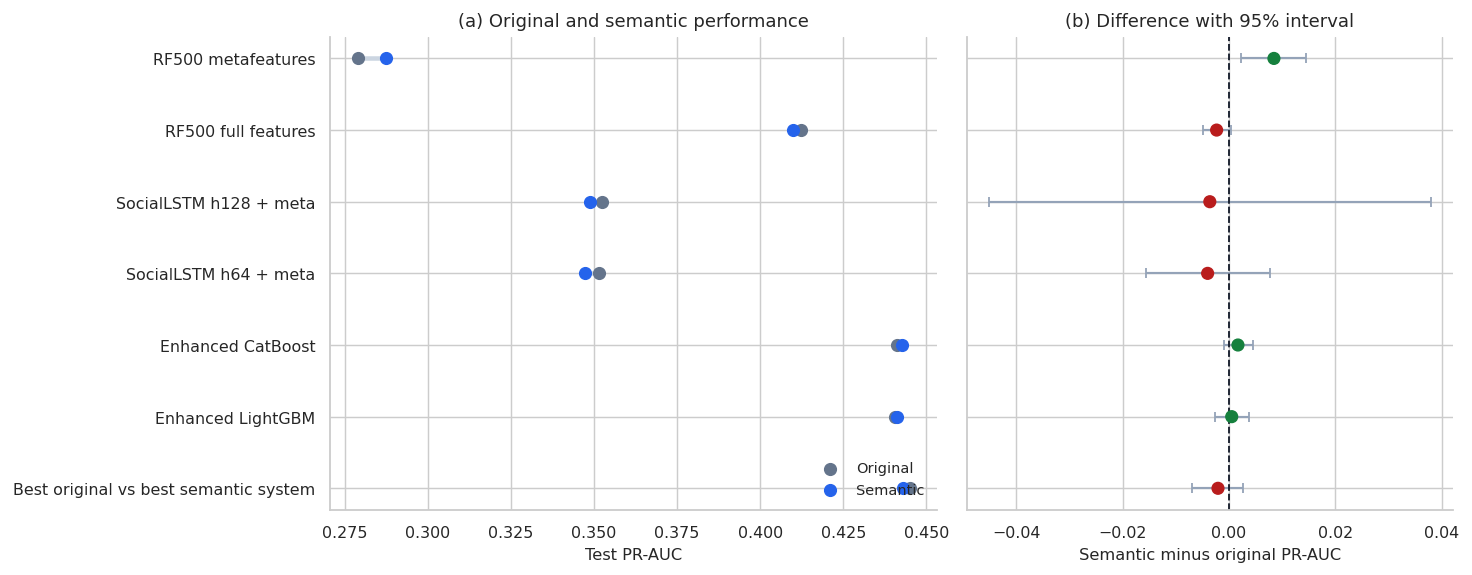

In [ ]:
# Cell 10: Figure 3 - PR-AUC levels and semantic deltas

plot_df = table_03.copy()
order = plot_df["comparison"].tolist()
y_pos = np.arange(len(plot_df))

fig, axes = plt.subplots(1, 2, figsize=(11.4, max(4.5, 0.58 * len(plot_df))),
                         gridspec_kw={"width_ratios": [1.25, 1.0]})

# Absolute PR-AUC dumbbell plot.
axes[0].hlines(
    y_pos, plot_df["original_pr_auc"], plot_df["semantic_pr_auc"],
    color="#CBD5E1", linewidth=2.5
)
axes[0].scatter(plot_df["original_pr_auc"], y_pos, color=GRAY, s=42, label="Original", zorder=3)
axes[0].scatter(plot_df["semantic_pr_auc"], y_pos, color=BLUE, s=42, label="Semantic", zorder=3)
axes[0].set_yticks(y_pos, order)
axes[0].invert_yaxis()
axes[0].set_xlabel("Test PR-AUC")
axes[0].set_title("(a) Original and semantic performance")
axes[0].legend(frameon=False, loc="lower right")

# Delta plot with the corresponding uncertainty where available.
uncertainty_lookup = table_04.set_index("comparison") if not table_04.empty else pd.DataFrame()
delta_lows, delta_highs = [], []
for _, row in plot_df.iterrows():
    if not table_04.empty and row["comparison"] in uncertainty_lookup.index:
        u = uncertainty_lookup.loc[row["comparison"]]
        if isinstance(u, pd.DataFrame):
            u = u.iloc[0]
        delta_lows.append(max(0.0, row["delta_pr_auc"] - u["ci_low"]))
        delta_highs.append(max(0.0, u["ci_high"] - row["delta_pr_auc"]))
    else:
        delta_lows.append(0.0)
        delta_highs.append(0.0)

colors = [GREEN if value > 0 else RED for value in plot_df["delta_pr_auc"]]
axes[1].errorbar(
    plot_df["delta_pr_auc"], y_pos,
    xerr=[delta_lows, delta_highs],
    fmt="none", ecolor="#94A3B8", capsize=3, zorder=1
)
axes[1].scatter(plot_df["delta_pr_auc"], y_pos, c=colors, s=42, zorder=3)
axes[1].axvline(0, color="#111827", linestyle="--", linewidth=1)
axes[1].set_yticks(y_pos, [""] * len(y_pos))
axes[1].invert_yaxis()
axes[1].set_xlabel("Semantic minus original PR-AUC")
axes[1].set_title("(b) Difference with 95% interval")

fig.tight_layout()
save_figure(fig, "figure_03_model_pr_auc_and_semantic_deltas")
plt.show()


Saved: /content/drive/MyDrive/csonet2026_conflict_prediction/results_gpt4omini/paper_ready_final/artifacts/main_paper/figures/figure_04_semantic_predictability_and_grouped_shap.png


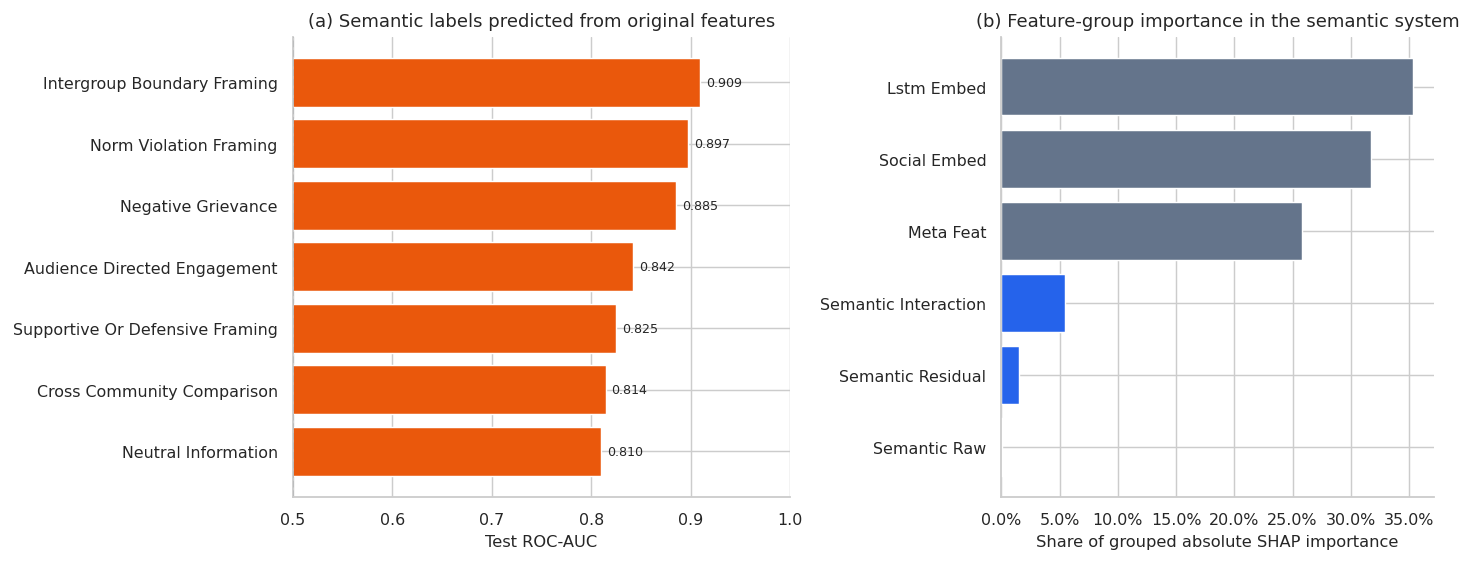

Saved: /content/drive/MyDrive/csonet2026_conflict_prediction/results_gpt4omini/paper_ready_final/artifacts/supplementary/tables/table_s02_semantic_predictability.csv
Saved: /content/drive/MyDrive/csonet2026_conflict_prediction/results_gpt4omini/paper_ready_final/artifacts/supplementary/tables/table_s03_grouped_shap_importance.csv


In [ ]:
# Cell 11: Figure 4 - semantic redundancy evidence

pred_plot = predictability_df[
    predictability_df["semantic_feature"].isin(BOOLEAN_LABELS)
].copy()
if pred_plot.empty:
    pred_plot = predictability_df.nlargest(7, "test_roc_auc").copy()
pred_plot["label"] = pred_plot["semantic_feature"].map(clean_label)
pred_plot = pred_plot.sort_values("test_roc_auc", ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(11.2, 4.4), gridspec_kw={"width_ratios": [1.15, 1.0]})
axes[0].barh(pred_plot["label"], pred_plot["test_roc_auc"], color=ORANGE)
axes[0].axvline(0.5, color="#111827", linestyle="--", linewidth=1)
axes[0].set_xlim(0.5, 1.0)
axes[0].set_xlabel("Test ROC-AUC")
axes[0].set_ylabel("")
axes[0].set_title("(a) Semantic labels predicted from original features")
for idx, value in enumerate(pred_plot["test_roc_auc"]):
    axes[0].text(value + 0.006, idx, f"{value:.3f}", va="center", fontsize=7)

if shap_group_df.empty:
    axes[1].text(0.5, 0.5, "Grouped SHAP file not found.\nRun SHAP diagnostics in the final paper notebook.",
                 ha="center", va="center", transform=axes[1].transAxes)
    axes[1].set_axis_off()
else:
    shap_plot = shap_group_df.copy()
    if "feature_group" not in shap_plot.columns:
        first_col = shap_plot.columns[0]
        shap_plot = shap_plot.rename(columns={first_col: "feature_group"})
    shap_plot["feature_group_label"] = (
        shap_plot["feature_group"].astype(str).str.replace("_", " ").str.title()
    )
    shap_plot["importance_share"] = shap_plot["sum"] / shap_plot["sum"].sum()
    shap_plot = shap_plot.sort_values("importance_share", ascending=True)
    group_colors = [
        BLUE if str(group).startswith("semantic") else GRAY
        for group in shap_plot["feature_group"]
    ]
    axes[1].barh(shap_plot["feature_group_label"], shap_plot["importance_share"], color=group_colors)
    axes[1].set_xlabel("Share of grouped absolute SHAP importance")
    axes[1].set_ylabel("")
    axes[1].set_title("(b) Feature-group importance in the semantic system")
    axes[1].xaxis.set_major_formatter(PercentFormatter(1.0))

fig.tight_layout()
save_figure(fig, "figure_04_semantic_predictability_and_grouped_shap")
plt.show()

table_redundancy = predictability_df[
    ["semantic_feature", "test_roc_auc", "test_pr_auc", "test_positive_rate"]
].copy()
table_redundancy["semantic_label"] = table_redundancy["semantic_feature"].map(clean_label)
table_redundancy = table_redundancy[
    ["semantic_label", "semantic_feature", "test_roc_auc", "test_pr_auc", "test_positive_rate"]
].sort_values("test_roc_auc", ascending=False)
save_table(table_redundancy, "table_s02_semantic_predictability.csv", supplementary=True)
if not shap_group_df.empty:
    save_table(shap_group_df, "table_s03_grouped_shap_importance.csv", supplementary=True)


## Optional supplementary materials

The next cell is off by default. Enable it only when you need an appendix,
repository supplement, or response-to-reviewer package. These diagnostics are
useful, but they should not displace the four main figures and four main tables.


Saved: /content/drive/MyDrive/csonet2026_conflict_prediction/results_gpt4omini/paper_ready_final/artifacts/supplementary/tables/table_s04_primary_label_distribution.csv
Saved: /content/drive/MyDrive/csonet2026_conflict_prediction/results_gpt4omini/paper_ready_final/artifacts/supplementary/figures/figure_s01_primary_label_distribution.png


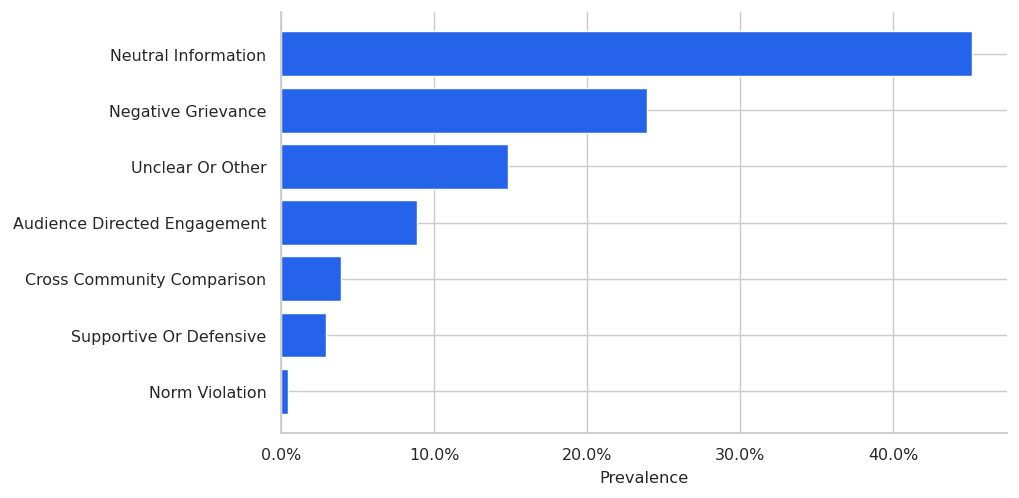

Saved: /content/drive/MyDrive/csonet2026_conflict_prediction/results_gpt4omini/paper_ready_final/artifacts/supplementary/figures/figure_s02_boolean_label_phi_correlation.png


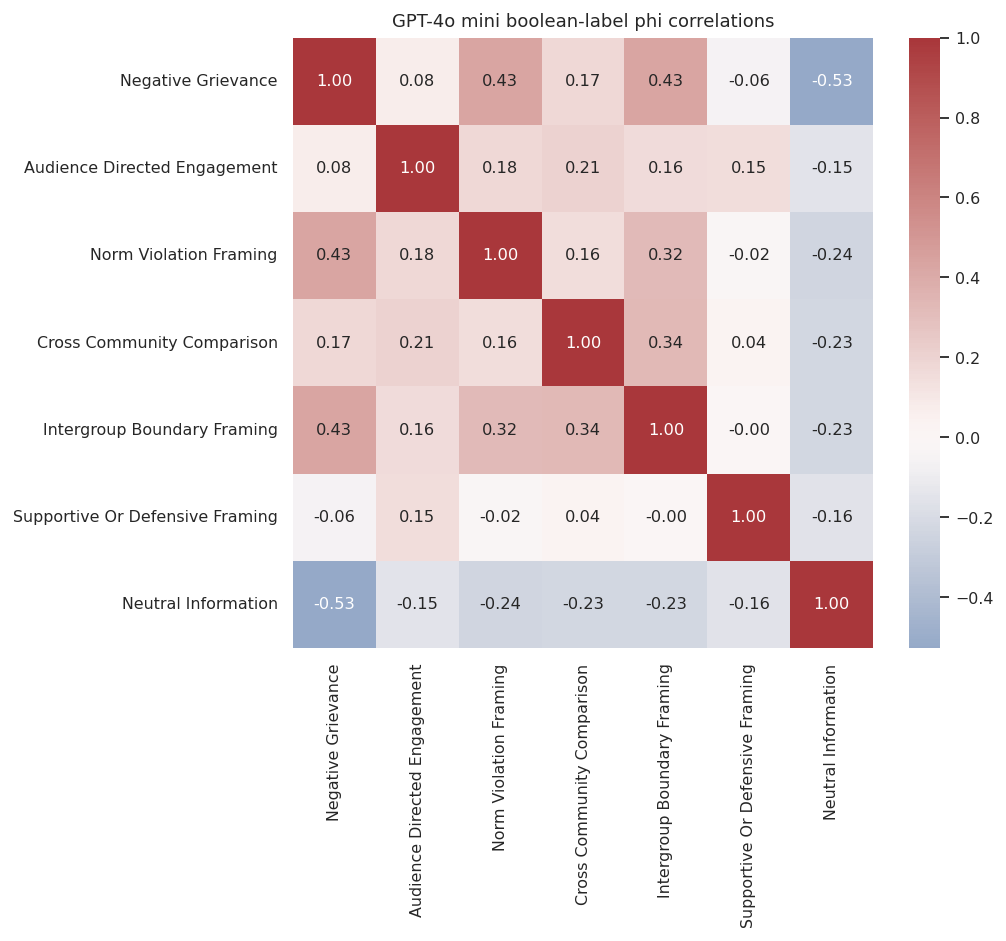

Saved: /content/drive/MyDrive/csonet2026_conflict_prediction/results_gpt4omini/paper_ready_final/artifacts/supplementary/tables/table_s06_gpt4omini_resource_summary.csv
Saved: /content/drive/MyDrive/csonet2026_conflict_prediction/results_gpt4omini/paper_ready_final/artifacts/supplementary/figures/figure_s03_selected_precision_recall_curves.png
Saved: /content/drive/MyDrive/csonet2026_conflict_prediction/results_gpt4omini/paper_ready_final/artifacts/supplementary/figures/figure_s04_selected_roc_curves.png


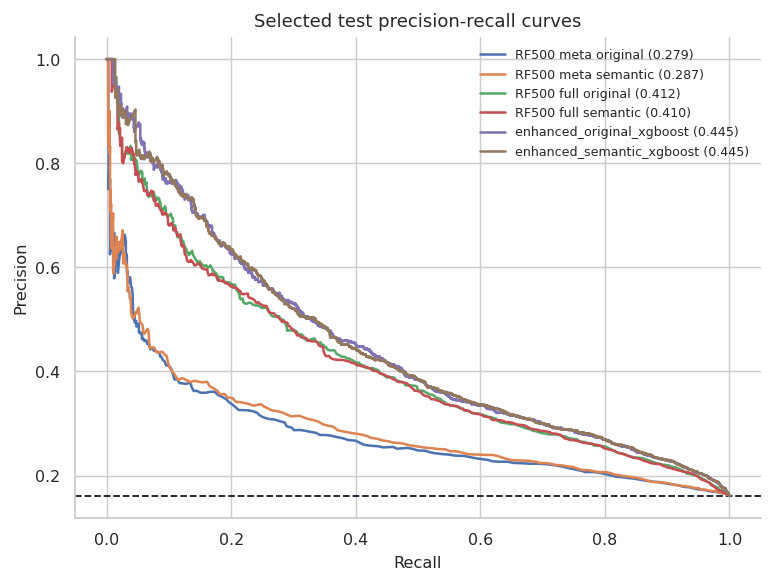

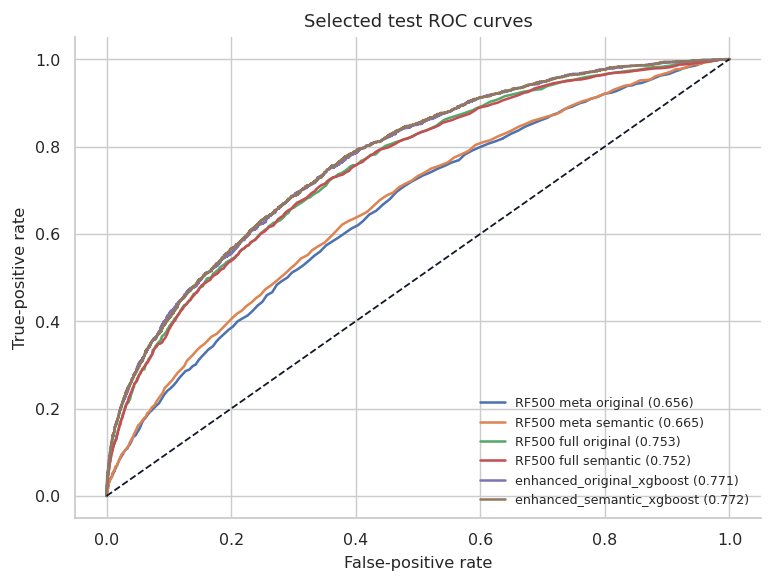

Saved: /content/drive/MyDrive/csonet2026_conflict_prediction/results_gpt4omini/paper_ready_final/artifacts/supplementary/tables/table_s07_selected_curve_metrics.csv


In [ ]:
# Cell 12: Optional supplementary plots

if not RUN_SUPPLEMENTARY:
    print("Supplementary generation is disabled. Set RUN_SUPPLEMENTARY=True in Cell 1 to enable it.")
else:
    # S1: Primary-label distribution.
    primary_rows = [{
        "primary_label": clean_label(column),
        "feature_column": column,
        "count": int(semantic_df[column].sum()),
        "prevalence": float(semantic_df[column].mean()),
    } for column in PRIMARY_LABELS]
    primary_df = pd.DataFrame(primary_rows).sort_values("prevalence", ascending=True)
    save_table(primary_df, "table_s04_primary_label_distribution.csv", supplementary=True)
    fig, ax = plt.subplots(figsize=(7.2, 4.2))
    ax.barh(primary_df["primary_label"], primary_df["prevalence"], color=BLUE)
    ax.set_xlabel("Prevalence")
    ax.set_ylabel("")
    ax.xaxis.set_major_formatter(PercentFormatter(1.0))
    save_figure(fig, "figure_s01_primary_label_distribution", supplementary=True)
    plt.show()

    # S2: Boolean-label phi correlations.
    phi = semantic_df[BOOLEAN_LABELS].corr()
    phi.index = [clean_label(column) for column in phi.index]
    phi.columns = [clean_label(column) for column in phi.columns]
    phi.to_csv(SUPP_TABLE_DIR / "table_s05_boolean_label_phi_correlation.csv")
    fig, ax = plt.subplots(figsize=(7.2, 6.1))
    sns.heatmap(phi, cmap="vlag", center=0, annot=True, fmt=".2f", ax=ax)
    ax.set_title("GPT-4o mini boolean-label phi correlations")
    save_figure(fig, "figure_s02_boolean_label_phi_correlation", supplementary=True)
    plt.show()

    # S3: GPT-4o mini runtime/resource summary if available.
    resource_path = GPT4OMINI_DIR / "resource_metrics.csv"
    if resource_path.exists():
        resource_df = pd.read_csv(resource_path, low_memory=False)
        numeric = [
            column for column in [
                "latency_seconds", "attempts", "input_tokens", "output_tokens",
                "thoughts_tokens", "total_tokens", "rss_gb", "cpu_percent"
            ] if column in resource_df.columns
        ]
        rows = []
        for column in numeric:
            values = pd.to_numeric(resource_df[column], errors="coerce").dropna()
            if values.empty:
                continue
            rows.append({
                "metric": column,
                "count": int(values.count()),
                "mean": float(values.mean()),
                "median": float(values.median()),
                "p95": float(values.quantile(0.95)),
                "sum": float(values.sum()),
            })
        resource_summary = pd.DataFrame(rows)
        save_table(resource_summary, "table_s06_gpt4omini_resource_summary.csv", supplementary=True)

    # S4: Selected PR and ROC curves from prediction files.
    selected_paths = [
        ("RF500 meta original", RESULTS_DIR / "fair_rf500_original_metafeatures_predictions.parquet"),
        ("RF500 meta semantic", RESULTS_DIR / "fair_rf500_semantic_metafeatures_predictions.parquet"),
        ("RF500 full original", RESULTS_DIR / "fair_rf500_original_full_features_predictions.parquet"),
        ("RF500 full semantic", RESULTS_DIR / "fair_rf500_semantic_full_features_predictions.parquet"),
    ]
    if "prediction_path" in redundancy_leaderboard.columns:
        for _, row in redundancy_leaderboard.head(2).iterrows():
            path_text = str(row.get("prediction_path", "")).strip()
            if path_text:
                selected_paths.append((str(row["model_name"]), Path(path_text)))

    fig_pr, ax_pr = plt.subplots(figsize=(6.8, 4.8))
    fig_roc, ax_roc = plt.subplots(figsize=(6.8, 4.8))
    curve_rows = []
    baseline_drawn = False
    for label, path in selected_paths:
        if not Path(path).exists():
            continue
        pred = pd.read_parquet(path)
        if "split" in pred.columns:
            pred = pred[pred["split"] == "test"]
        if pred.empty:
            continue
        y = pred["y"].astype(int).values
        score = pred["score"].astype(float).values
        precision, recall, _ = precision_recall_curve(y, score)
        fpr, tpr, _ = roc_curve(y, score)
        ap = average_precision_score(y, score)
        auc = roc_auc_score(y, score)
        ax_pr.plot(recall, precision, linewidth=1.4, label=f"{label} ({ap:.3f})")
        ax_roc.plot(fpr, tpr, linewidth=1.4, label=f"{label} ({auc:.3f})")
        if not baseline_drawn:
            ax_pr.axhline(y.mean(), color="#111827", linestyle="--", linewidth=1)
            baseline_drawn = True
        curve_rows.append({"model": label, "roc_auc": auc, "pr_auc": ap, "n_test": len(y)})
    ax_pr.set(xlabel="Recall", ylabel="Precision", title="Selected test precision-recall curves")
    ax_roc.plot([0, 1], [0, 1], color="#111827", linestyle="--", linewidth=1)
    ax_roc.set(xlabel="False-positive rate", ylabel="True-positive rate", title="Selected test ROC curves")
    ax_pr.legend(frameon=False, fontsize=7)
    ax_roc.legend(frameon=False, fontsize=7)
    save_figure(fig_pr, "figure_s03_selected_precision_recall_curves", supplementary=True)
    save_figure(fig_roc, "figure_s04_selected_roc_curves", supplementary=True)
    plt.show()
    save_table(pd.DataFrame(curve_rows), "table_s07_selected_curve_metrics.csv", supplementary=True)


In [ ]:
# Cell 13: Excel workbook, report, and reproducibility manifest

excel_path = OUTPUT_ROOT / "csonet2026_final_paper_support_tables.xlsx"
all_csvs = sorted(MAIN_TABLE_DIR.glob("*.csv")) + sorted(SUPP_TABLE_DIR.glob("*.csv"))
with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
    used_names = set()
    for path in all_csvs:
        base = re.sub(r"[^A-Za-z0-9_]+", "_", path.stem)[:31]
        sheet = base
        counter = 2
        while sheet in used_names:
            suffix = f"_{counter}"
            sheet = base[:31 - len(suffix)] + suffix
            counter += 1
        used_names.add(sheet)
        pd.read_csv(path, low_memory=False).to_excel(writer, sheet_name=sheet, index=False)

report_lines = [
    "# CSoNet 2026 Final Paper Support Report",
    "",
    f"Generated: `{RUN_TIMESTAMP_UTC}`",
    "",
    "## Recommended main-paper set",
    "",
    "- Table 0: published WWW 2018 AUC values versus this reconstruction.",
    "- Figure 1: study design.",
    "- Table 1: coverage and split composition.",
    "- Table 2 and Figure 2: GPT-4o mini label prevalence and test-outcome association.",
    "- Table 3, Table 4, and Figure 3: original-versus-semantic performance and uncertainty.",
    "- Figure 4: redundancy evidence from predictability and grouped SHAP.",
    "",
    "## Key facts",
    "",
    f"- GPT-4o mini semantic coverage: `{len(semantic_df):,}/{EXPECTED_ORIGINAL_ROWS:,}`.",
    f"- Missing semantic rows: `{EXPECTED_ORIGINAL_ROWS - len(semantic_df):,}`.",
    f"- Boolean labels: `{len(BOOLEAN_LABELS)}`; primary labels: `{len(PRIMARY_LABELS)}`.",
]
if best_system_summary:
    report_lines.extend([
        f"- Best original PR-AUC: `{best_system_summary['best_original_pr_auc']:.6f}`.",
        f"- Best semantic-system PR-AUC: `{best_system_summary['best_semantic_or_redundancy_pr_auc']:.6f}`.",
        f"- System-level PR-AUC delta: `{best_system_summary['delta_best_pr_auc']:+.6f}`.",
        f"- Selected original system: `{best_system_summary['best_original_model']}`.",
        f"- Selected semantic system: `{best_system_summary['best_semantic_or_redundancy_model']}`.",
        "- Validation-trained stackers were excluded from selection.",
    ])
report_lines.extend([
    "",
    "## Interpretation guardrail",
    "",
    "The baseline-to-best-system change is a system-level comparison and must not be described as a semantic-only effect. Validation-trained stackers were excluded because out-of-fold training predictions were unavailable.",
])

report_path = REPORT_DIR / "paper_support_summary.md"
with open(report_path, "w", encoding="utf-8") as handle:
    handle.write("\n".join(report_lines) + "\n")

manifest = {
    "created_at_utc": RUN_TIMESTAMP_UTC,
    "project_root": str(PROJECT_ROOT),
    "gpt4omini_semantic_path": str(SEMANTIC_PATH),
    "semantic_coverage_rows": int(len(semantic_df)),
    "expected_original_rows": EXPECTED_ORIGINAL_ROWS,
    "association_split": ASSOCIATION_SPLIT,
    "run_supplementary": RUN_SUPPLEMENTARY,
    "main_tables": [str(path) for path in sorted(MAIN_TABLE_DIR.glob("*"))],
    "main_figures": [str(path) for path in sorted(MAIN_FIGURE_DIR.glob("*"))],
    "supplementary_tables": [str(path) for path in sorted(SUPP_TABLE_DIR.glob("*"))],
    "supplementary_figures": [str(path) for path in sorted(SUPP_FIGURE_DIR.glob("*"))],
    "excel_workbook": str(excel_path),
    "report": str(report_path),
    "best_system_summary": best_system_summary,
    "invalid_validation_stackers_excluded": True,
    "selection_metric": "validation_pr_auc",
    "selection_uses_test_metrics": False,
    "provenance_manifest": str(PROVENANCE_DIR / "environment_and_input_manifest.json"),
    "interpretation_guardrail": (
        "Baseline-to-best-system deltas combine architecture and semantic changes; "
        "only matched-pair rows estimate the direct semantic effect."
    ),
}
manifest_path = OUTPUT_ROOT / "paper_support_manifest.json"
with open(manifest_path, "w", encoding="utf-8") as handle:
    json.dump(manifest, handle, indent=2, default=str)

print("\n".join(report_lines))
print("\nExcel workbook:", excel_path)
print("Manifest:", manifest_path)
print("Done.")


# CSoNet 2026 Final Paper Support Report

Generated: `2026-07-02T16:54:41Z`

## Recommended main-paper set

- Table 0: published WWW 2018 AUC values versus this reconstruction.
- Figure 1: study design.
- Table 1: coverage and split composition.
- Table 2 and Figure 2: GPT-4o mini label prevalence and test-outcome association.
- Table 3, Table 4, and Figure 3: original-versus-semantic performance and uncertainty.
- Figure 4: redundancy evidence from predictability and grouped SHAP.

## Key facts

- GPT-4o mini semantic coverage: `116,224/116,224`.
- Missing semantic rows: `0`.
- Boolean labels: `7`; primary labels: `7`.
- Best original PR-AUC: `0.445023`.
- Best semantic-system PR-AUC: `0.442949`.
- System-level PR-AUC delta: `-0.002074`.
- Selected original system: `enhanced_original_xgboost`.
- Selected semantic system: `redundancy_semantic_optuna_lightgbm_resid_interactions`.
- Validation-trained stackers were excluded from selection.

## Interpretation guardrail

The baseline-to-be

## 18. References and reporting notes

1. S. Kumar, W. L. Hamilton, J. Leskovec, and D. Jurafsky. “Community Interaction and Conflict
   on the Web.” *Proceedings of The Web Conference 2018*, pp. 933-943.
   DOI: [10.1145/3178876.3186141](https://doi.org/10.1145/3178876.3186141).
2. Stanford SNAP. [Community Interaction and Conflict on the Web](https://snap.stanford.edu/conflict/).
   Official project page, prediction code, data, and embeddings.
3. Stanford SNAP. [Reddit Hyperlink Network](https://snap.stanford.edu/data/soc-RedditHyperlinks.html).
   Description of the broader directed, signed, temporal, and attributed hyperlink network.
4. J. Davis and M. Goadrich. “The Relationship Between Precision-Recall and ROC Curves.”
   *ICML 2006*. DOI: [10.1145/1143844.1143874](https://doi.org/10.1145/1143844.1143874).
5. G. Ke et al. “LightGBM: A Highly Efficient Gradient Boosting Decision Tree.”
   *NeurIPS 2017*. [Proceedings paper](https://proceedings.neurips.cc/paper/2017/hash/6449f44a102fde848669bdd9eb6b76fa-Abstract.html).
6. T. Akiba et al. “Optuna: A Next-generation Hyperparameter Optimization Framework.”
   *KDD 2019*. DOI: [10.1145/3292500.3330701](https://doi.org/10.1145/3292500.3330701).
7. S. M. Lundberg and S.-I. Lee. “A Unified Approach to Interpreting Model Predictions.”
   *NeurIPS 2017*. [Proceedings paper](https://proceedings.neurips.cc/paper/2017/hash/8a20a8621978632d76c43dfd28b67767-Abstract.html).

### Citation boundary

This notebook provides a faithful modern reconstruction of the released experimental setting; it
does not claim bit-for-bit equivalence to the original 2018 software environment. The manuscript
should report reconstructed results and the original paper's published results in separate columns.
The proposed-system comparison is a system-level result. Matched ablations and their paired
intervals are the appropriate evidence for the incremental effect of semantic features.

In [ ]:
# Create one complete archive and download it in Colab

import shutil

BUNDLE_STEM = "csonet2026_gpt4omini_paper_ready_artifacts"
BUNDLE_PATH = Path(shutil.make_archive(
    str(RESULTS_DIR / BUNDLE_STEM),
    "zip",
    root_dir=PAPER_READY_DIR,
))

bundle_manifest = {
    "bundle": str(BUNDLE_PATH),
    "bytes": int(BUNDLE_PATH.stat().st_size),
    "sha256": sha256_file(BUNDLE_PATH),
    "contains": "main-paper tables/figures, supplementary tables/figures, workbook, reports, and provenance manifests",
}
with open(PAPER_READY_DIR / "bundle_manifest.json", "w", encoding="utf-8") as handle:
    json.dump(bundle_manifest, handle, indent=2)

print(json.dumps(bundle_manifest, indent=2))

AUTO_DOWNLOAD_BUNDLE = True
if AUTO_DOWNLOAD_BUNDLE:
    from google.colab import files
    files.download(str(BUNDLE_PATH))

{
  "bundle": "/content/drive/MyDrive/csonet2026_conflict_prediction/results_gpt4omini/csonet2026_gpt4omini_paper_ready_artifacts.zip",
  "bytes": 1817299,
  "sha256": "b554bc57af945f1addd37ff8bae8b8bbd59adde7b54a6e614cdd06eb911b1a64",
  "contains": "main-paper tables/figures, supplementary tables/figures, workbook, reports, and provenance manifests"
}


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Export and download all non-textual material from the GPT-4o mini run
# Put this cell at the very end of the notebook, after all figures/materials are generated.

from pathlib import Path
import shutil
import zipfile
from datetime import datetime

# Colab download helper
try:
    from google.colab import files
    IN_COLAB = True
except Exception:
    IN_COLAB = False

# === Locate GPT-4o mini result directory ===
CANDIDATE_ROOTS = [
    Path("/content/drive/MyDrive/csonet2026_conflict_prediction/results_gpt4omini"),
    Path("/content/drive/MyDrive/csonet2026_conflict_prediction/results_gpt4omini/paper_ready_final"),
    Path("/content/drive/MyDrive/csonet2026_conflict_prediction/results_gpt4omini/paper_ready_final/artifacts"),
    Path("/content/results_gpt4omini"),
]

existing_roots = [p for p in CANDIDATE_ROOTS if p.exists()]

if not existing_roots:
    raise FileNotFoundError(
        "Could not find results_gpt4omini. "
        "Run the full GPT-4o mini train/eval notebook first, then rerun this cell."
    )

# Use the broadest existing root so we catch all generated material
ROOT = existing_roots[0]

# === Non-textual material extensions only ===
NON_TEXT_EXTS = {
    ".png", ".jpg", ".jpeg", ".svg", ".pdf", ".eps",
    ".webp", ".tif", ".tiff", ".bmp"
}

# Exclude obvious cache/temp/system folders
EXCLUDE_DIR_NAMES = {
    "__pycache__", ".ipynb_checkpoints", ".git", "cache",
    "tmp", "temp"
}

# === Collect files ===
material_files = []

for path in ROOT.rglob("*"):
    if not path.is_file():
        continue

    parts_lower = {part.lower() for part in path.parts}
    if parts_lower.intersection(EXCLUDE_DIR_NAMES):
        continue

    if path.suffix.lower() in NON_TEXT_EXTS:
        material_files.append(path)

material_files = sorted(set(material_files))

if not material_files:
    raise FileNotFoundError(
        f"No non-textual material files found under:\n{ROOT}\n"
        "Expected files like .png, .pdf, .svg, .jpg, etc."
    )

# === Create export folder ===
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
EXPORT_DIR = Path(f"/content/csonet2026_gpt4omini_non_textual_material_{timestamp}")
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

# Preserve relative folder structure
for src in material_files:
    rel = src.relative_to(ROOT)
    dst = EXPORT_DIR / rel
    dst.parent.mkdir(parents=True, exist_ok=True)
    shutil.copy2(src, dst)

# Add a small manifest so you know what was included
manifest_path = EXPORT_DIR / "NON_TEXTUAL_MATERIAL_MANIFEST.txt"
with open(manifest_path, "w", encoding="utf-8") as f:
    f.write("CSoNet 2026 GPT-4o mini non-textual material export\n")
    f.write(f"Source root: {ROOT}\n")
    f.write(f"Export folder: {EXPORT_DIR}\n")
    f.write(f"Number of files: {len(material_files)}\n\n")
    for i, src in enumerate(material_files, start=1):
        rel = src.relative_to(ROOT)
        size_kb = src.stat().st_size / 1024
        f.write(f"{i:03d}. {rel}    ({size_kb:.1f} KB)\n")

# === Zip it ===
ZIP_PATH = Path(f"/content/csonet2026_gpt4omini_non_textual_material_{timestamp}.zip")

with zipfile.ZipFile(ZIP_PATH, "w", compression=zipfile.ZIP_DEFLATED) as zf:
    for file_path in EXPORT_DIR.rglob("*"):
        if file_path.is_file():
            zf.write(file_path, arcname=file_path.relative_to(EXPORT_DIR))

print("=" * 80)
print("GPT-4o mini non-textual material export complete")
print("=" * 80)
print(f"Source root: {ROOT}")
print(f"Files included: {len(material_files)}")
print(f"Export folder: {EXPORT_DIR}")
print(f"Zip file: {ZIP_PATH}")
print(f"Zip size: {ZIP_PATH.stat().st_size / (1024 * 1024):.2f} MB")
print("\nIncluded extensions:")
for ext in sorted({p.suffix.lower() for p in material_files}):
    count = sum(1 for p in material_files if p.suffix.lower() == ext)
    print(f"  {ext}: {count}")

# === Download in Colab ===
if IN_COLAB:
    files.download(str(ZIP_PATH))
else:
    print("\nNot running in Colab, so automatic browser download was skipped.")
    print(f"Manually download this file: {ZIP_PATH}")

GPT-4o mini non-textual material export complete
Source root: /content/drive/MyDrive/csonet2026_conflict_prediction/results_gpt4omini
Files included: 26
Export folder: /content/csonet2026_gpt4omini_non_textual_material_20260703_121713
Zip file: /content/csonet2026_gpt4omini_non_textual_material_20260703_121713.zip
Zip size: 1.76 MB

Included extensions:
  .pdf: 9
  .png: 9
  .svg: 8


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>